In [1]:
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Scanpy:", sc.__version__)
print("AnnData:", anndata.__version__)

Scanpy: 1.12.4
AnnData: 0.13.4


C:\Users\devan\AppData\Local\Temp\ipykernel_4544\1174152918.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)
C:\Users\devan\AppData\Local\Temp\ipykernel_4544\1174152918.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("AnnData:", anndata.__version__)


In [2]:
import os

print(os.getcwd())
print(os.listdir("../data"))

c:\alz\notebooks
[]


In [3]:
import os

print(os.listdir("../data"))

['GSE243292_ADsnRNAseq_GEO.h5ad.gz']


In [5]:
adata = sc.read_h5ad("../data/GSE243292_ADsnRNAseq_GEO.h5ad.gz")

OSError: Unable to synchronously open file (file signature not found)

In [6]:
import gzip
import shutil
from pathlib import Path

gz_file = Path("../data/GSE243292_ADsnRNAseq_GEO.h5ad.gz")
h5ad_file = Path("../data/GSE243292_ADsnRNAseq_GEO.h5ad")

with gzip.open(gz_file, "rb") as f_in:
    with open(h5ad_file, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Decompression complete!")

Decompression complete!


In [7]:
adata = sc.read_h5ad("../data/GSE243292_ADsnRNAseq_GEO.h5ad")


In [8]:
print(adata)

AnnData object with n_obs × n_vars = 122606 × 26423
    obs: 'cellname', 'final_celltype', 'trem2', 'atscore', 'apoe', 'sampleID'
    var: 'Ensembl', 'genename'
    layers: None (.X)


In [9]:
adata.obs.head()

,cellname,final_celltype,trem2,atscore,apoe,sampleID
index,,,,,,
AAACCTGAGAGCTTCT-1-I2,AAACCTGAGAGCTTCT-1,Ex,WT,A+T-,E3/E4,5
AAACCTGAGGCAGGTT-1-I2,AAACCTGAGGCAGGTT-1,Ex,WT,A+T-,E3/E4,5
AAACCTGAGGTCGGAT-1-I2,AAACCTGAGGTCGGAT-1,In,WT,A+T-,E3/E4,5
AAACCTGCAATCACAC-1-I2,AAACCTGCAATCACAC-1,Ex,WT,A+T-,E3/E4,5
AAACCTGCACGGTAGA-1-I2,AAACCTGCACGGTAGA-1,Ex,WT,A+T-,E3/E4,5


In [10]:
adata.obs["final_celltype"].value_counts()

final_celltype
Oli    44182
Ex     39176
Ast    15683
In     12286
Opc     6853
Mic     3982
End      444
Name: count, dtype: int64

In [11]:
adata.obs["sampleID"].value_counts()

sampleID
8     12654
9     10528
15    10250
10    10233
3     10189
6     10181
1     10057
2      9835
5      8227
12     7284
4      6398
7      6167
13     4697
11     3336
14     2570
Name: count, dtype: int64

In [12]:
adata.var.head()

,Ensembl,genename
index,,
AL627309.1,ENSG00000238009,AL627309.1
AC114498.1,ENSG00000235146,AC114498.1
AL669831.5,ENSG00000237491,AL669831.5
FAM87B,ENSG00000177757,FAM87B
LINC00115,ENSG00000225880,LINC00115


In [13]:
print(adata.obs.columns)

Index(['cellname', 'final_celltype', 'trem2', 'atscore', 'apoe', 'sampleID'], dtype='str')


In [14]:
adata.X.shape

(122606, 26423)

In [15]:
print(type(adata.X))
print(adata.X.dtype)

<class 'scipy.sparse._csr.csr_matrix'>
float32


In [16]:
print(adata.X.min())
print(adata.X.max())

0.0
2094.0


In [17]:
import numpy as np

total_values = adata.X.shape[0] * adata.X.shape[1]
nonzero_values = adata.X.count_nonzero()

print("Total entries:", total_values)
print("Non-zero entries:", nonzero_values)
print("Sparsity:", 1 - nonzero_values / total_values)

Total entries: 3239618338
Non-zero entries: 138925244
Sparsity: 0.9571167867614411


In [18]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

print(adata.obs[["n_genes_by_counts", "total_counts"]].describe())

       n_genes_by_counts   total_counts
count      122606.000000  122606.000000
mean         1133.103143    1876.618896
std           721.670878    1597.492432
min           274.000000     480.000000
25%           614.000000     825.000000
50%           861.000000    1238.000000
75%          1432.000000    2317.000000
max          3999.000000   12474.000000


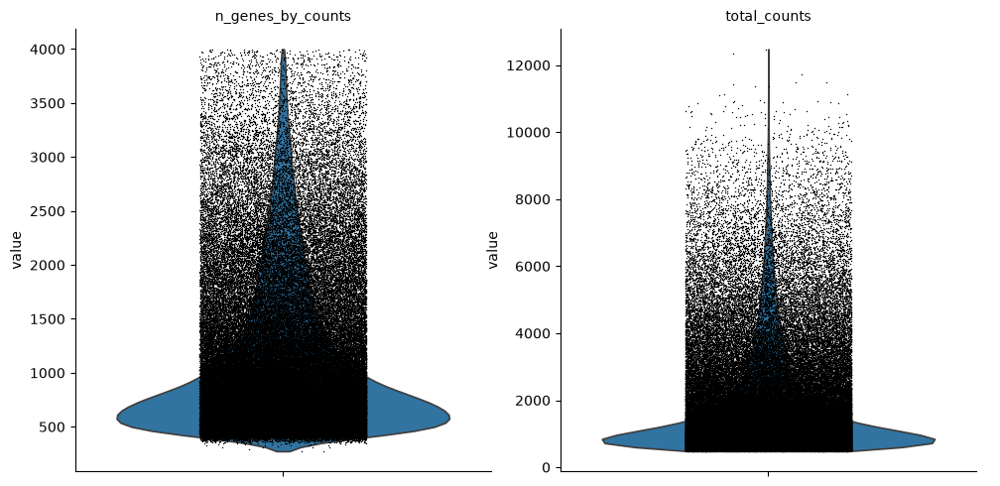

In [19]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.2,
    multi_panel=True
)

In [20]:
# Calculate mitochondrial and ribosomal gene percentages

adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo"],
    inplace=True
)

print(adata.obs[
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]
].describe())

       n_genes_by_counts   total_counts  pct_counts_mt  pct_counts_ribo
count      122606.000000  122606.000000  122606.000000    122606.000000
mean         1133.103143    1876.618896       1.466579         0.940355
std           721.670878    1597.492432       1.118464         0.672908
min           274.000000     480.000000       0.000000         0.000000
25%           614.000000     825.000000       0.617032         0.514580
50%           861.000000    1238.000000       1.146384         0.776349
75%          1432.000000    2317.000000       2.044293         1.180637
max          3999.000000   12474.000000       4.997918        15.044249


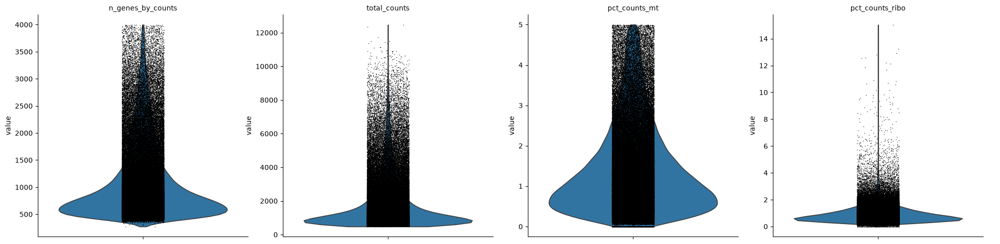

In [21]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.1,
    multi_panel=True
)

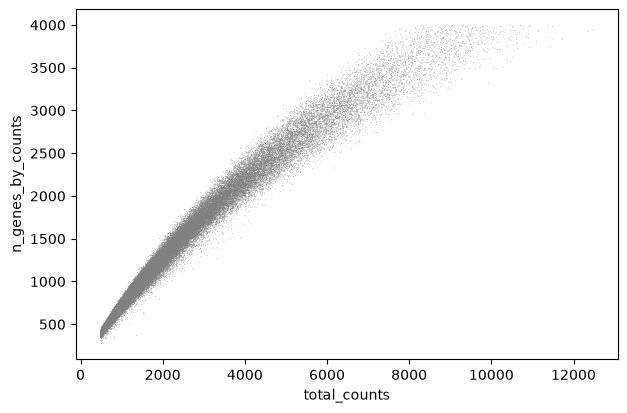

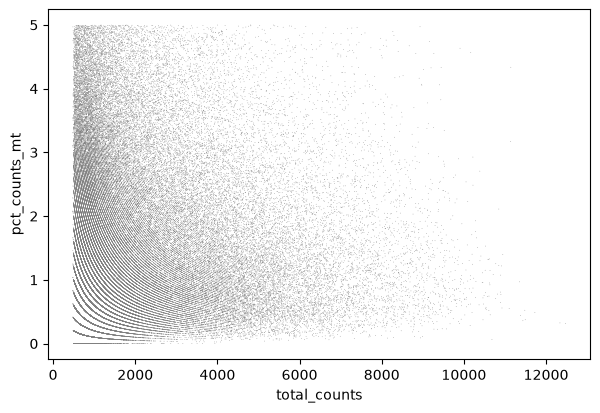

In [22]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts"
)

sc.pl.scatter(
    adata,
    x="total_counts",
    y="pct_counts_mt"
)

In [23]:
# Make a copy before filtering so we can go back if needed
adata_raw = adata.copy()

# Filter cells based on QC metrics
adata = adata[adata.obs["n_genes_by_counts"] >= 300].copy()

adata = adata[
    adata.obs["n_genes_by_counts"] < 4000
].copy()

adata = adata[
    adata.obs["pct_counts_mt"] < 5
].copy()

print("Cells after QC:", adata.n_obs)
print("Genes:", adata.n_vars)

Cells after QC: 122603
Genes: 26423


In [24]:
# Normalize each cell to the same total count
sc.pp.normalize_total(
    adata,
    target_sum=1e4
)

# Log-transform the normalized counts
sc.pp.log1p(adata)

print(adata)

AnnData object with n_obs × n_vars = 122603 × 26423
    obs: 'cellname', 'final_celltype', 'trem2', 'atscore', 'apoe', 'sampleID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'Ensembl', 'genename', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo'
    uns: 'log1p'
    layers: None (.X)


In [25]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat"
)

print("Highly variable genes:", adata.var["highly_variable"].sum())

Highly variable genes: 2000


In [26]:
sc.tl.pca(
    adata,
    n_comps=50,
    use_highly_variable=True
)

print("PCA completed")
print("PCA shape:", adata.obsm["X_pca"].shape)

C:\Users\devan\AppData\Local\Temp\ipykernel_4544\2283585093.py:1: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(


PCA completed
PCA shape: (122603, 50)


In [27]:
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30
)

print("Neighbor graph completed")

Neighbor graph completed


In [28]:
sc.tl.umap(adata)

print("UMAP completed")
print("UMAP shape:", adata.obsm["X_umap"].shape)

UMAP completed
UMAP shape: (122603, 2)


In [29]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    key_added="leiden"
)

print("Leiden clustering completed")
print("Number of clusters:", adata.obs["leiden"].nunique())
print(adata.obs["leiden"].value_counts().sort_index())

C:\Users\devan\AppData\Local\Temp\ipykernel_4544\2346639522.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


ModuleNotFoundError: No module named 'leidenalg'

In [30]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    key_added="leiden"
)

print("Leiden clustering completed")
print("Number of clusters:", adata.obs["leiden"].nunique())
print(adata.obs["leiden"].value_counts().sort_index())

C:\Users\devan\AppData\Local\Temp\ipykernel_4544\2346639522.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


Leiden clustering completed
Number of clusters: 13
leiden
0     43864
1     14829
2     14352
3     13780
4      6834
5      6206
6      5915
7      4417
8      4043
9      3726
10     2175
11     1589
12      873
Name: count, dtype: int64


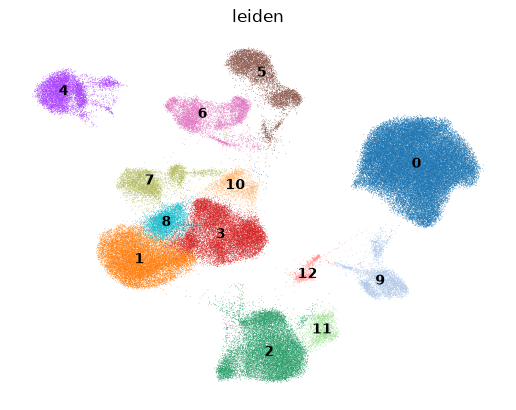

In [31]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    frameon=False
)

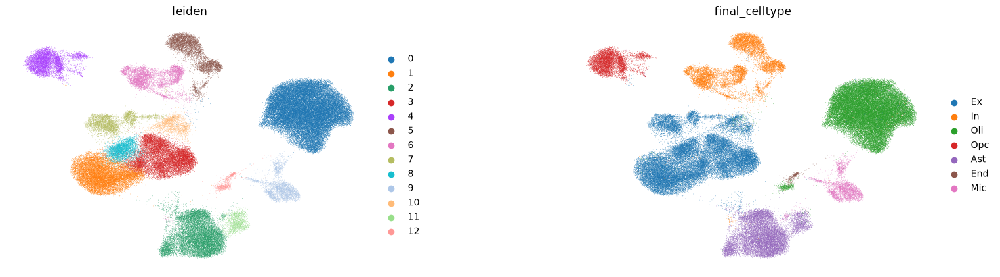

In [32]:
sc.pl.umap(
    adata,
    color=["leiden", "final_celltype"],
    wspace=0.4,
    frameon=False
)

In [33]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

print("Marker gene analysis completed")

Marker gene analysis completed


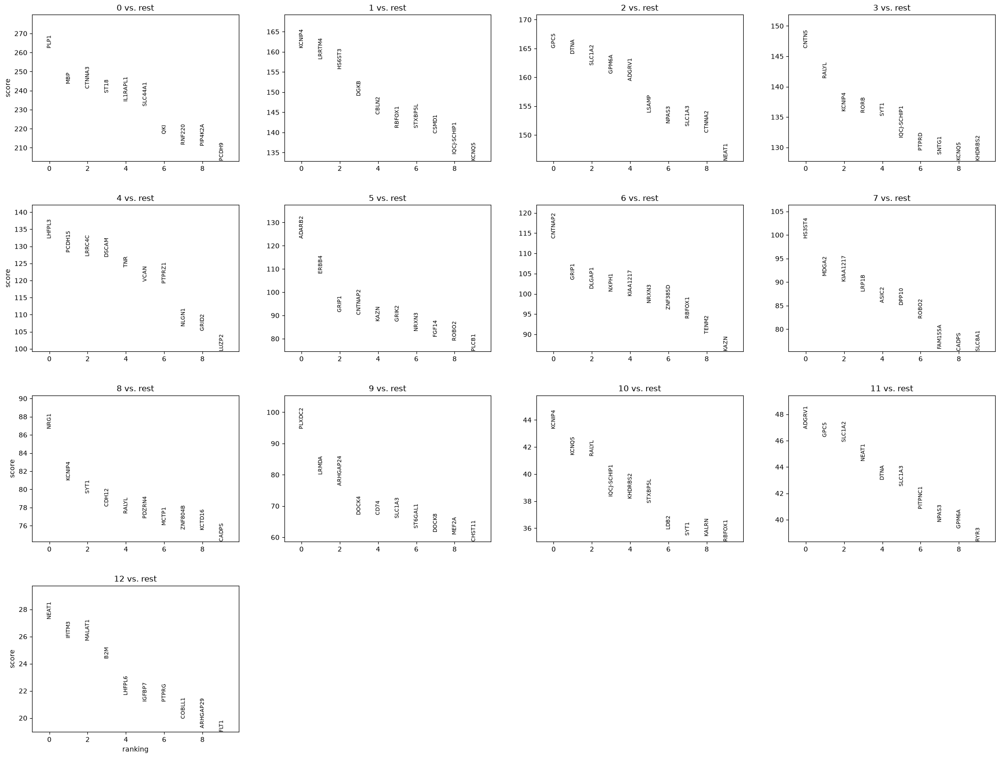

In [34]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

In [35]:
import pandas as pd

cluster_celltype = pd.crosstab(
    adata.obs["leiden"],
    adata.obs["final_celltype"]
)

print(cluster_celltype)

final_celltype     Ex    In    Oli   Opc    Ast  End   Mic
leiden                                                    
0                 112   108  43398    29     83   26   108
1               14691    40     51     7     20    5    15
2                 161    33     13     2  14028   11   104
3               13737    11     10     2      2   11     7
4                  18     1      7  6789     11    2     6
5                  13  6169     16     4      0    1     3
6                  21  5859     15     2      8    4     6
7                4375    31      3     2      0    2     4
8                4029     3      1     4      1    2     3
9                  13     1     16     0      0    8  3688
10               2000    26    125     9      3    0    12
11                  2     2     36     3   1513    7    26
12                  3     2    490     0     13  365     0


In [36]:
cluster_celltype_pct = pd.crosstab(
    adata.obs["leiden"],
    adata.obs["final_celltype"],
    normalize="index"
).round(3)

print(cluster_celltype_pct)

final_celltype     Ex     In    Oli    Opc    Ast    End    Mic
leiden                                                         
0               0.003  0.002  0.989  0.001  0.002  0.001  0.002
1               0.991  0.003  0.003  0.000  0.001  0.000  0.001
2               0.011  0.002  0.001  0.000  0.977  0.001  0.007
3               0.997  0.001  0.001  0.000  0.000  0.001  0.001
4               0.003  0.000  0.001  0.993  0.002  0.000  0.001
5               0.002  0.994  0.003  0.001  0.000  0.000  0.000
6               0.004  0.991  0.003  0.000  0.001  0.001  0.001
7               0.990  0.007  0.001  0.000  0.000  0.000  0.001
8               0.997  0.001  0.000  0.001  0.000  0.000  0.001
9               0.003  0.000  0.004  0.000  0.000  0.002  0.990
10              0.920  0.012  0.057  0.004  0.001  0.000  0.006
11              0.001  0.001  0.023  0.002  0.952  0.004  0.016
12              0.003  0.002  0.561  0.000  0.015  0.418  0.000


In [37]:
for cluster in ["9", "10", "12"]:
    print(f"\n===== LEIDEN CLUSTER {cluster} =====")
    
    markers = sc.get.rank_genes_groups_df(
        adata,
        group=cluster
    )
    
    print(markers[["names", "scores", "pvals_adj"]].head(20).to_string(index=False))


===== LEIDEN CLUSTER 9 =====
   names    scores  pvals_adj
  PLXDC2 94.613319        0.0
   LRMDA 79.976112        0.0
ARHGAP24 76.439873        0.0
   DOCK4 67.106361        0.0
    CD74 67.068268        0.0
  SLC1A3 66.046829        0.0
 ST6GAL1 62.810703        0.0
   DOCK8 61.553139        0.0
   MEF2A 60.770882        0.0
  CHST11 58.583332        0.0
 APBB1IP 58.121380        0.0
  SRGAP2 56.714302        0.0
    FYB1 55.843586        0.0
ARHGAP15 55.766972        0.0
   MEF2C 54.424656        0.0
   ITPR2 53.830284        0.0
   NEAT1 51.886353        0.0
  FRMD4A 51.098022        0.0
    SSH2 50.956940        0.0
   FOXN3 50.497723        0.0

===== LEIDEN CLUSTER 10 =====
      names    scores     pvals_adj
     KCNIP4 43.322590  0.000000e+00
      KCNQ5 41.380997  0.000000e+00
      RALYL 41.302395  0.000000e+00
IQCJ-SCHIP1 38.316010  0.000000e+00
    KHDRBS2 38.162292  0.000000e+00
    STXBP5L 37.837437  0.000000e+00
       LDB2 35.889484 1.682268e-278
       SYT1 35.446693

In [38]:
print(
    adata.obs.loc[adata.obs["leiden"] == "12", "final_celltype"]
    .value_counts()
)

final_celltype
Oli    490
End    365
Ast     13
Ex       3
In       2
Opc      0
Mic      0
Name: count, dtype: int64


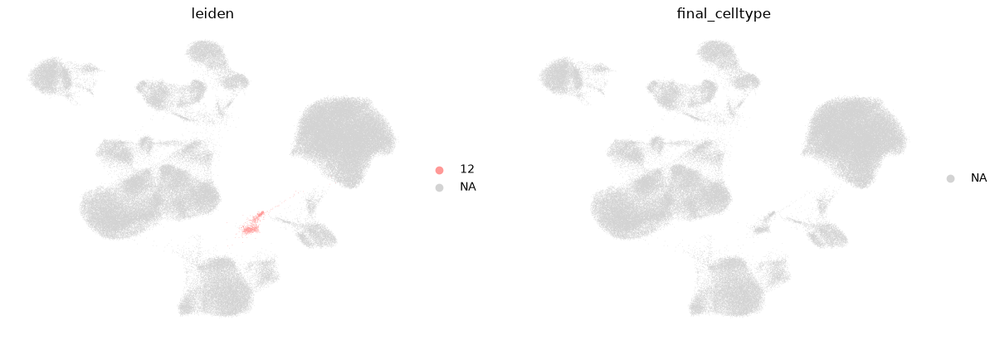

In [39]:
sc.pl.umap(
    adata,
    color=["leiden", "final_celltype"],
    groups=["12"],
    frameon=False
)

In [40]:
cluster_to_celltype = {
    "0": "Oli",
    "1": "Ex",
    "2": "Ast",
    "3": "Ex",
    "4": "Opc",
    "5": "In",
    "6": "In",
    "7": "Ex",
    "8": "Ex",
    "9": "Unknown",
    "10": "Ex",
    "11": "Ast",
    "12": "Mixed_Oli_End"
}

adata.obs["final_celltype"] = (
    adata.obs["leiden"]
    .map(cluster_to_celltype)
    .astype("category")
)

print(adata.obs["final_celltype"].value_counts())

final_celltype
Oli              43864
Ex               39244
Ast              15941
In               12121
Opc               6834
Unknown           3726
Mixed_Oli_End      873
Name: count, dtype: int64


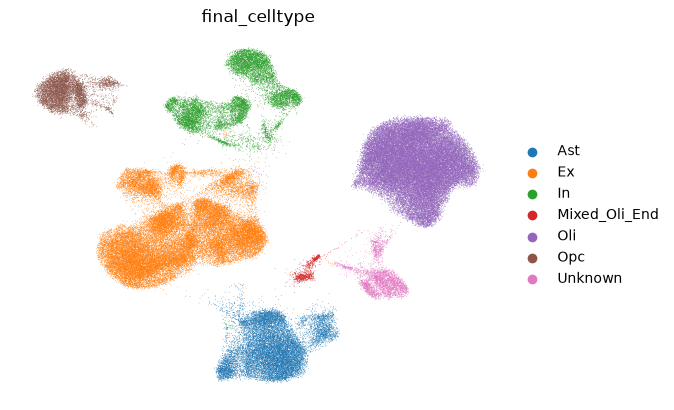

In [41]:
sc.pl.umap(
    adata,
    color="final_celltype",
    frameon=False,
    legend_loc="right margin"
)

In [42]:
cluster_to_celltype = {
    "0": "Oli",
    "1": "Ex",
    "2": "Ast",
    "3": "Ex",
    "4": "Opc",
    "5": "In",
    "6": "In",
    "7": "Ex",
    "8": "Ex",
    "9": "Mic",
    "10": "Ex",
    "11": "Ast",
    "12": "End"
}

adata.obs["final_celltype"] = (
    adata.obs["leiden"]
    .map(cluster_to_celltype)
    .astype("category")
)

print(adata.obs["final_celltype"].value_counts())

final_celltype
Oli    43864
Ex     39244
Ast    15941
In     12121
Opc     6834
Mic     3726
End      873
Name: count, dtype: int64


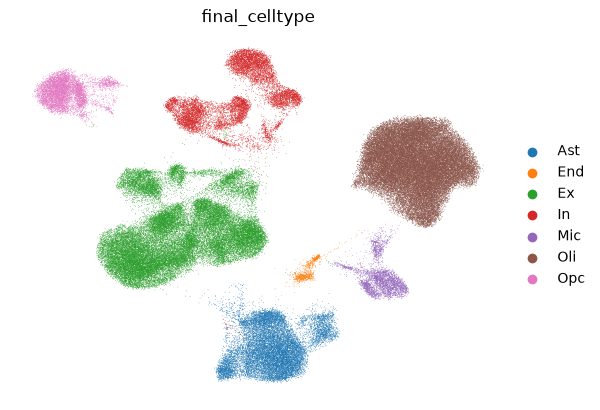

In [43]:
sc.pl.umap(
    adata,
    color="final_celltype",
    frameon=False,
    legend_loc="right margin"
)

In [44]:
marker_genes = {
    "Ex": ["SLC17A7", "CAMK2A"],
    "In": ["GAD1", "GAD2"],
    "Ast": ["AQP4", "GFAP", "ALDH1L1"],
    "Oli": ["MBP", "PLP1", "MOG"],
    "Opc": ["PDGFRA", "CSPG4"],
    "Mic": ["AIF1", "CX3CR1", "C1QA"],
    "End": ["CLDN5", "FLT1", "KDR"]
}

genes_to_plot = [
    gene
    for genes in marker_genes.values()
    for gene in genes
    if gene in adata.var_names
]

print("Markers found:", genes_to_plot)

Markers found: ['SLC17A7', 'CAMK2A', 'GAD1', 'GAD2', 'AQP4', 'GFAP', 'ALDH1L1', 'MBP', 'PLP1', 'MOG', 'PDGFRA', 'CSPG4', 'AIF1', 'CX3CR1', 'C1QA', 'CLDN5', 'FLT1', 'KDR']


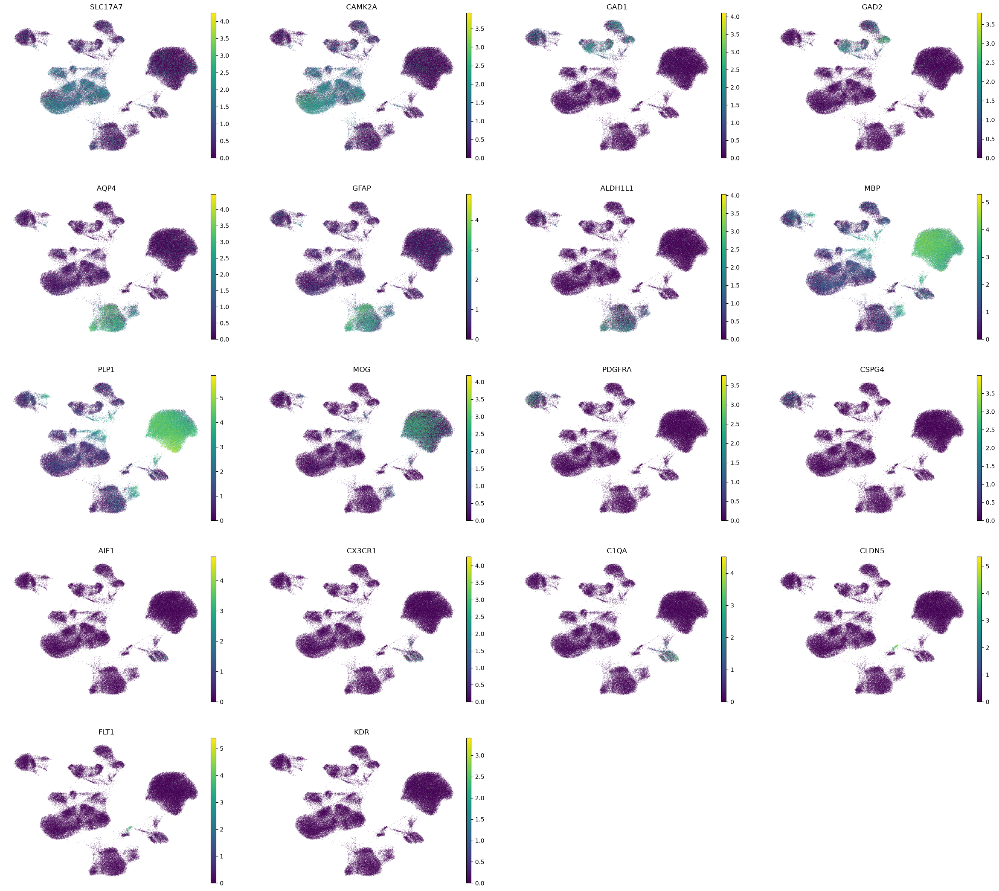

In [45]:
sc.pl.umap(
    adata,
    color=genes_to_plot,
    ncols=4,
    frameon=False,
    size=1
)

In [46]:
marker_df = sc.get.obs_df(
    adata,
    keys=genes_to_plot + ["final_celltype"]
)

marker_summary = (
    marker_df
    .groupby("final_celltype")[genes_to_plot]
    .mean()
    .round(3)
)

print(marker_summary)

                SLC17A7  CAMK2A   GAD1   GAD2   AQP4   GFAP  ALDH1L1    MBP  \
final_celltype                                                                
Ast               0.213   0.170  0.036  0.020  1.652  1.613    0.620  0.543   
End               0.162   0.088  0.024  0.035  0.068  0.187    0.082  0.372   
Ex                0.913   1.078  0.030  0.026  0.098  0.169    0.019  0.631   
In                0.209   0.352  0.811  0.699  0.080  0.163    0.027  0.648   
Mic               0.227   0.175  0.036  0.030  0.107  0.183    0.025  1.030   
Oli               0.138   0.096  0.024  0.021  0.074  0.134    0.014  3.104   
Opc               0.181   0.127  0.370  0.033  0.132  0.248    0.120  0.767   

                 PLP1    MOG  PDGFRA  CSPG4   AIF1  CX3CR1   C1QA  CLDN5  \
final_celltype                                                             
Ast             0.679  0.073   0.004  0.008  0.007   0.008  0.019  0.008   
End             0.438  0.039   0.046  0.099  0.006   0.003  

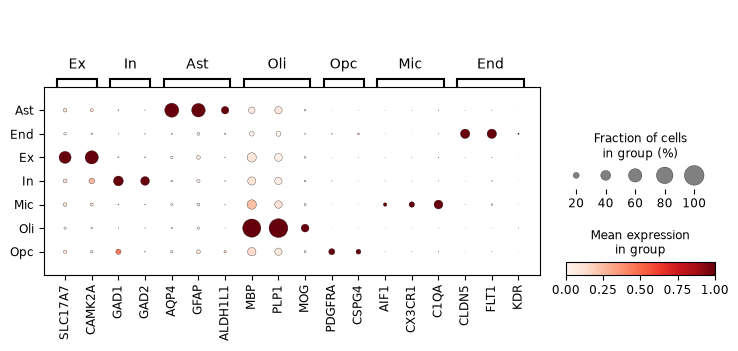

In [47]:
sc.pl.dotplot(
    adata,
    marker_genes,
    groupby="final_celltype",
    standard_scale="var",
    dendrogram=False
)

In [48]:
celltype_counts = adata.obs["final_celltype"].value_counts()

celltype_pct = (
    adata.obs["final_celltype"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

celltype_summary = (
    pd.DataFrame({
        "n_cells": celltype_counts,
        "percentage": celltype_pct
    })
    .sort_values("n_cells", ascending=False)
)

print(celltype_summary)

                n_cells  percentage
final_celltype                     
Oli               43864       35.78
Ex                39244       32.01
Ast               15941       13.00
In                12121        9.89
Opc                6834        5.57
Mic                3726        3.04
End                 873        0.71


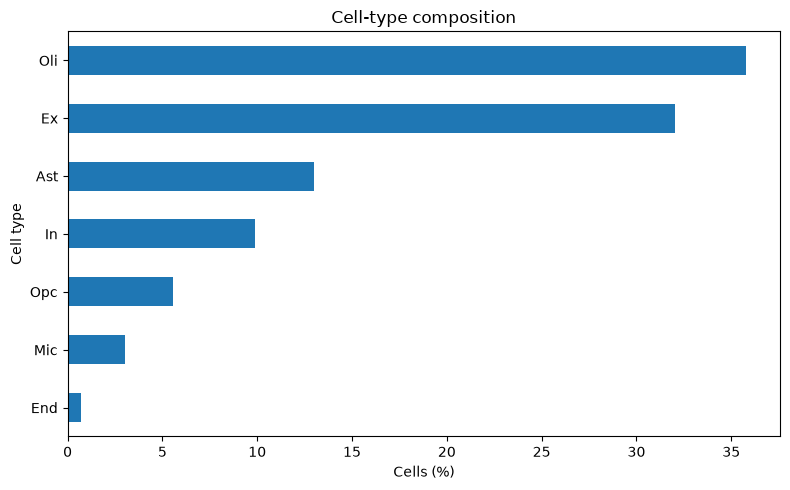

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

celltype_summary["percentage"].sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Cells (%)")
ax.set_ylabel("Cell type")
ax.set_title("Cell-type composition")
plt.tight_layout()

plt.show()

In [50]:
import os

os.makedirs("../results", exist_ok=True)

adata.write("../results/annotated_dataset.h5ad")

print("Annotated dataset saved")
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

Annotated dataset saved
Cells: 122603
Genes: 26423


In [51]:
sc.tl.rank_genes_groups(
    adata,
    groupby="final_celltype",
    method="wilcoxon",
    n_genes=50
)

print("Differential expression completed")

Differential expression completed


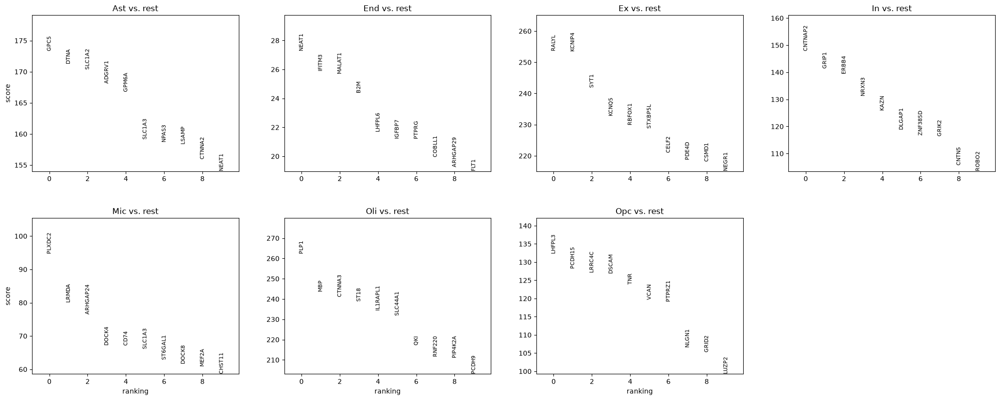

In [52]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

In [53]:
# Save marker genes from the cell-type annotation
markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

markers.to_csv(
    "results/celltype_marker_genes.csv",
    index=False
)

print("Marker table saved")
print("Rows:", len(markers))
print(markers.head())

OSError: Cannot save file into a non-existent directory: 'results'

In [54]:
from pathlib import Path

# Create results folder if it doesn't exist
Path("results").mkdir(exist_ok=True)

# Get marker genes
markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

# Save
markers.to_csv(
    "results/celltype_marker_genes.csv",
    index=False
)

print("Marker table saved successfully")
print("Rows:", len(markers))
print(markers.head())

Marker table saved successfully
Rows: 350
  group   names      scores  logfoldchanges  pvals  pvals_adj
0   Ast    GPC5  173.293625        5.563709    0.0        0.0
1   Ast    DTNA  171.211533        4.162977    0.0        0.0
2   Ast  SLC1A2  170.318863        5.657032    0.0        0.0
3   Ast  ADGRV1  168.073074        6.117827    0.0        0.0
4   Ast   GPM6A  166.731293        3.378170    0.0        0.0


In [55]:
# Top 10 marker genes for each cell type
top_markers = (
    markers
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(10)
)

print(top_markers[["group", "names", "scores", "logfoldchanges", "pvals_adj"]])

# Save the compact table
top_markers.to_csv(
    "results/top10_celltype_markers.csv",
    index=False
)

print("\nTop-marker table saved successfully")

    group   names      scores  logfoldchanges  pvals_adj
0     Ast    GPC5  173.293625        5.563709        0.0
1     Ast    DTNA  171.211533        4.162977        0.0
2     Ast  SLC1A2  170.318863        5.657032        0.0
3     Ast  ADGRV1  168.073074        6.117827        0.0
4     Ast   GPM6A  166.731293        3.378170        0.0
..    ...     ...         ...             ...        ...
305   Opc    VCAN  119.610977        7.008625        0.0
306   Opc  PTPRZ1  119.046288        5.543259        0.0
307   Opc   NLGN1  106.468735        2.764365        0.0
308   Opc   GRID2  105.181587        3.809284        0.0
309   Opc   LUZP2   99.245796        5.188303        0.0

[70 rows x 5 columns]

Top-marker table saved successfully


In [56]:
# Create a marker-gene list for each cell type
marker_lists = {}

for celltype in markers["group"].unique():
    genes = (
        markers[markers["group"] == celltype]
        .sort_values("scores", ascending=False)
        ["names"]
        .dropna()
        .unique()
        .tolist()
    )
    
    marker_lists[celltype] = genes

print("Marker lists created:\n")

for celltype, genes in marker_lists.items():
    print(f"{celltype}: {len(genes)} genes")

Marker lists created:

Ast: 50 genes
End: 50 genes
Ex: 50 genes
In: 50 genes
Mic: 50 genes
Oli: 50 genes
Opc: 50 genes


In [57]:
import gseapy as gp
from pathlib import Path

Path("results/go_enrichment").mkdir(parents=True, exist_ok=True)

go_results = {}

for celltype, genes in marker_lists.items():
    print(f"Running GO enrichment: {celltype}")

    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=["GO_Biological_Process_2023"],
        organism="Human",
        outdir=f"results/go_enrichment/{celltype}",
        cutoff=0.05
    )

    go_results[celltype] = enr.results

print("\nGO enrichment completed!")

Running GO enrichment: Ast


ValueError: Invalid organism 'Human'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish

In [58]:
import gseapy as gp
from pathlib import Path

Path("results/go_enrichment").mkdir(parents=True, exist_ok=True)

go_results = {}

for celltype, genes in marker_lists.items():
    print(f"Running GO enrichment: {celltype}")

    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=["GO_Biological_Process_2023"],
        outdir=f"results/go_enrichment/{celltype}",
        cutoff=0.05
    )

    go_results[celltype] = enr.results

print("\nGO enrichment completed!")

Running GO enrichment: Ast
Running GO enrichment: End
Running GO enrichment: Ex
Running GO enrichment: In
Running GO enrichment: Mic
Running GO enrichment: Oli
Running GO enrichment: Opc

GO enrichment completed!


In [59]:
# Show the top 10 GO terms for each cell type

for celltype, result in go_results.items():
    print(f"\n{'='*60}")
    print(f"{celltype} — TOP GO BIOLOGICAL PROCESSES")
    print(f"{'='*60}")

    if result is None or result.empty:
        print("No enriched terms found.")
        continue

    display(
        result[
            ["Term", "Overlap", "P-value", "Adjusted P-value", "Combined Score"]
        ].head(10)
    )


Ast — TOP GO BIOLOGICAL PROCESSES


,Term,Overlap,P-value,Adjusted P-value,Combined Score
0,Positive Regulation Of Lipid Metabolic Process...,3/24,0.000029,0.007183,633.579375
1,Neuron Projection Morphogenesis (GO:0048812),5/146,0.000031,0.007183,161.817020
2,Cellular Response To Organic Cyclic Compound (...,5/152,0.000038,0.007183,152.278031
3,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,0.000046,0.007183,507.960566
4,L-aspartate Import Across Plasma Membrane (GO:...,2/5,0.000061,0.007183,2688.785055
5,L-aspartate Transmembrane Transport (GO:0070778),2/5,0.000061,0.007183,2688.785055
6,Neuron Projection Development (GO:0031175),5/192,0.000115,0.011144,106.462860
7,Positive Regulation Of Lipid Biosynthetic Proc...,3/39,0.000126,0.011144,317.014983
8,Positive Regulation Of Biosynthetic Process (G...,3/44,0.000181,0.014014,267.058363
9,Aspartate Transmembrane Transport (GO:0015810),2/9,0.000218,0.014014,1000.806420



End — TOP GO BIOLOGICAL PROCESSES


,Term,Overlap,P-value,Adjusted P-value,Combined Score
0,Negative Regulation Of Epithelial Cell Migrati...,4/33,0.000001,0.000553,807.745211
1,Negative Regulation Of Angiogenesis (GO:0016525),5/86,0.000002,0.000553,352.934706
2,Negative Regulation Of Blood Vessel Morphogene...,4/77,0.000041,0.006025,239.252446
3,Protection From Natural Killer Cell Mediated C...,2/5,0.000061,0.006025,2688.785055
4,Regulation Of Endothelial Cell Migration (GO:0...,4/88,0.000069,0.006025,197.031519
5,Negative Regulation Of Endothelial Cell Migrat...,3/37,0.000108,0.006025,341.632666
6,Negative Regulation Of Endothelial Cell Prolif...,3/37,0.000108,0.006025,341.632666
7,Type I Interferon-Mediated Signaling Pathway (...,3/37,0.000108,0.006025,341.632666
8,Cellular Response To Type I Interferon (GO:007...,3/38,0.000117,0.006025,328.932133
9,Regulation Of Angiogenesis (GO:0045765),5/205,0.000157,0.007297,96.113325



Ex — TOP GO BIOLOGICAL PROCESSES


...

,Term,Overlap,P-value,Adjusted P-value,Combined Score
0,Positive Regulation Of B Cell Activation (GO:0...,4/52,0.000009,0.006328,420.682501
1,Positive Regulation Of B Cell Proliferation (G...,3/29,0.000051,0.018960,483.143895
2,Synapse Pruning (GO:0098883),2/8,0.000170,0.033466,1202.251780
3,Regulation Of B Cell Proliferation (GO:0030888),3/44,0.000181,0.033466,267.058363
4,Melanocyte Differentiation (GO:0030318),2/11,0.000332,0.036751,739.495662
5,Regulation Of Blood Vessel Endothelial Cell Mi...,3/54,0.000333,0.036751,199.397015
6,Antigen Receptor-Mediated Signaling Pathway (G...,4/134,0.000349,0.036751,105.519981
7,Regulation Of Vascular Associated Smooth Muscl...,2/12,0.000398,0.036751,650.497584
8,Positive Regulation Of Signal Transduction (GO...,5/266,0.000521,0.040408,63.367366
9,Prostanoid Biosynthetic Process (GO:0046457),2/14,0.000547,0.040408,520.011405



Oli — TOP GO BIOLOGICAL PROCESSES


,Term,Overlap,P-value,Adjusted P-value,Combined Score
0,Neuron Projection Development (GO:0031175),5/192,0.000115,0.023160,106.462860
1,Axon Ensheathment In Central Nervous System (G...,2/7,0.000128,0.023160,1490.324070
2,Regulation Of Cell Motility (GO:2000145),4/123,0.000252,0.028883,120.069748
3,Central Nervous System Myelination (GO:0022010),2/11,0.000332,0.028883,739.495662
4,Negative Regulation Of Locomotion (GO:0040013),2/12,0.000398,0.028883,650.497584
5,Oligodendrocyte Development (GO:0014003),2/16,0.000719,0.043484,429.455376
6,Regulation Of Cardiac Muscle Cell Contraction ...,2/26,0.001916,0.085556,216.475173
7,Axon Development (GO:0061564),3/99,0.001948,0.085556,82.385936
8,Calcium Ion Homeostasis (GO:0055074),3/102,0.002121,0.085556,78.786676
9,Substantia Nigra Development (GO:0021762),2/42,0.004948,0.135180,110.103424



Opc — TOP GO BIOLOGICAL PROCESSES


,Term,Overlap,P-value,Adjusted P-value,Combined Score
0,Nervous System Development (GO:0007399),13/433,3.290595e-11,1.270170e-08,394.352399
1,Synapse Assembly (GO:0007416),6/71,2.265958e-08,3.057980e-06,734.327319
2,Neuron Projection Guidance (GO:0097485),7/124,2.376669e-08,3.057980e-06,484.431637
3,Axon Guidance (GO:0007411),7/149,8.444851e-08,8.149281e-06,369.850548
4,Cell Junction Assembly (GO:0034329),6/95,1.314171e-07,1.014540e-05,482.168561
5,"Regulation Of Synaptic Transmission, Glutamate...",5/55,2.517411e-07,1.619534e-05,671.950687
6,Axonogenesis (GO:0007409),7/188,4.115928e-07,2.269640e-05,261.425833
7,Modulation Of Chemical Synaptic Transmission (...,6/123,6.094647e-07,2.940667e-05,330.796982
8,Synapse Organization (GO:0050808),6/131,8.829100e-07,3.786703e-05,301.485102
9,Central Nervous System Neuron Differentiation ...,4/31,1.034460e-06,3.993014e-05,884.288064


In [60]:
import os
import pandas as pd

os.makedirs("results/go", exist_ok=True)

for celltype, result in go_results.items():
    if result is not None and not result.empty:
        result.to_csv(
            f"results/go/{celltype}_GO_enrichment.csv",
            index=False
        )

print("GO enrichment results saved successfully.")

GO enrichment results saved successfully.


In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import os

plot_data = []

for celltype, result in go_results.items():
    if result is None or result.empty:
        continue

    temp = result.copy()

    # Keep the most significant terms
    temp = temp.sort_values("Adjusted P-value").head(10)

    temp["Cell Type"] = celltype
    plot_data.append(temp)

go_plot = pd.concat(plot_data, ignore_index=True)

print(go_plot[["Cell Type", "Term", "Adjusted P-value"]].head(20))

   Cell Type                                               Term  \
0        Ast  Positive Regulation Of Lipid Metabolic Process...   
1        Ast       Neuron Projection Morphogenesis (GO:0048812)   
2        Ast  Cellular Response To Organic Cyclic Compound (...   
3        Ast  Regulation Of Lipid Biosynthetic Process (GO:0...   
4        Ast  L-aspartate Import Across Plasma Membrane (GO:...   
5        Ast   L-aspartate Transmembrane Transport (GO:0070778)   
6        Ast         Neuron Projection Development (GO:0031175)   
7        Ast  Positive Regulation Of Lipid Biosynthetic Proc...   
8        Ast  Positive Regulation Of Biosynthetic Process (G...   
9        Ast     Aspartate Transmembrane Transport (GO:0015810)   
10       End  Negative Regulation Of Epithelial Cell Migrati...   
11       End   Negative Regulation Of Angiogenesis (GO:0016525)   
12       End  Negative Regulation Of Blood Vessel Morphogene...   
13       End  Protection From Natural Killer Cell Mediated C..

In [62]:
import matplotlib.pyplot as plt
import pandas as pd

plot_data = []

for celltype, result in go_results.items():
    if result is None or result.empty:
        continue

    temp = result.copy()

    # Top 8 most significant GO terms
    temp = temp.sort_values("Adjusted P-value").head(8)

    temp["Cell Type"] = celltype
    plot_data.append(temp)

go_plot = pd.concat(plot_data, ignore_index=True)

print("GO terms selected:", len(go_plot))
print(go_plot[["Cell Type", "Term", "Adjusted P-value"]])

GO terms selected: 56
   Cell Type                                               Term  \
0        Ast  Positive Regulation Of Lipid Metabolic Process...   
1        Ast       Neuron Projection Morphogenesis (GO:0048812)   
2        Ast  Cellular Response To Organic Cyclic Compound (...   
3        Ast  Regulation Of Lipid Biosynthetic Process (GO:0...   
4        Ast  L-aspartate Import Across Plasma Membrane (GO:...   
5        Ast   L-aspartate Transmembrane Transport (GO:0070778)   
6        Ast         Neuron Projection Development (GO:0031175)   
7        Ast  Positive Regulation Of Lipid Biosynthetic Proc...   
8        End  Negative Regulation Of Epithelial Cell Migrati...   
9        End   Negative Regulation Of Angiogenesis (GO:0016525)   
10       End  Negative Regulation Of Blood Vessel Morphogene...   
11       End  Protection From Natural Killer Cell Mediated C...   
12       End  Regulation Of Endothelial Cell Migration (GO:0...   
13       End  Negative Regulation Of End

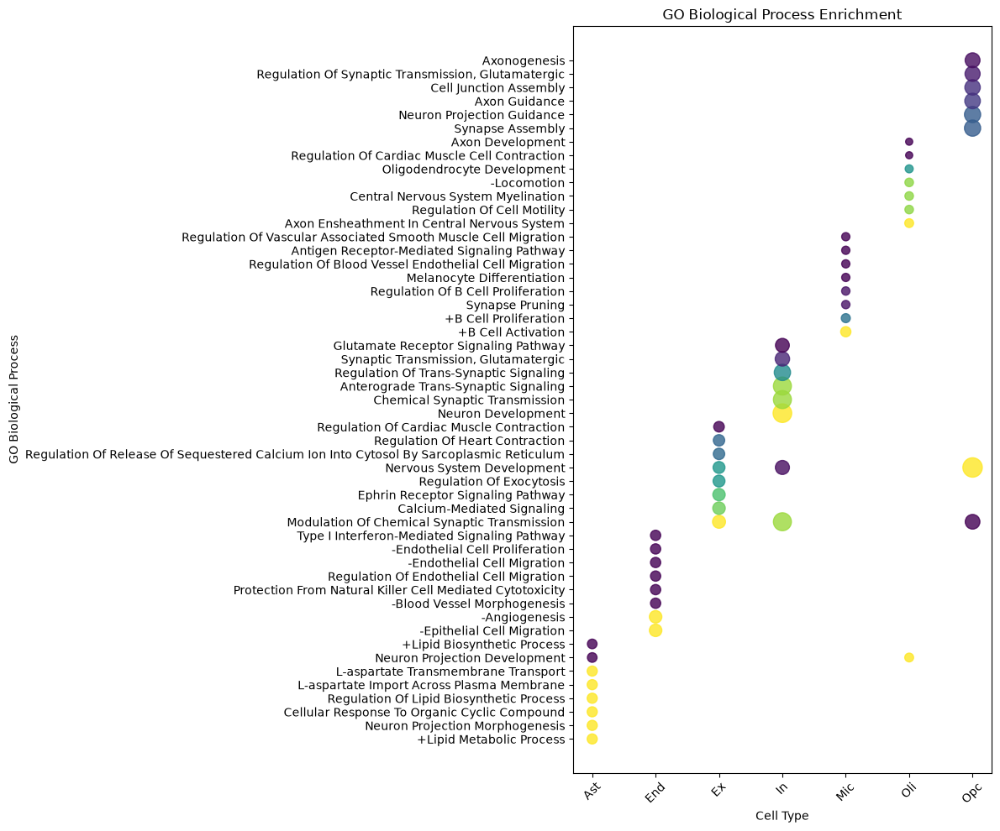

GO enrichment dot plot saved successfully.


In [63]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Prepare plotting values
go_plot["-log10_adjP"] = -np.log10(go_plot["Adjusted P-value"])

# Shorten very long GO terms for readability
go_plot["Short Term"] = (
    go_plot["Term"]
    .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
    .str.replace("Positive Regulation Of ", "+", regex=False)
    .str.replace("Negative Regulation Of ", "-", regex=False)
)

# Plot
plt.figure(figsize=(12, 10))

for celltype in go_plot["Cell Type"].unique():
    subset = go_plot[go_plot["Cell Type"] == celltype]

    plt.scatter(
        subset["Cell Type"],
        subset["Short Term"],
        s=subset["-log10_adjP"] * 35,
        c=subset["-log10_adjP"],
        alpha=0.8
    )

plt.xlabel("Cell Type")
plt.ylabel("GO Biological Process")
plt.title("GO Biological Process Enrichment")
plt.xticks(rotation=45)

plt.tight_layout()

# Save
os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/GO_enrichment_dotplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("GO enrichment dot plot saved successfully.")

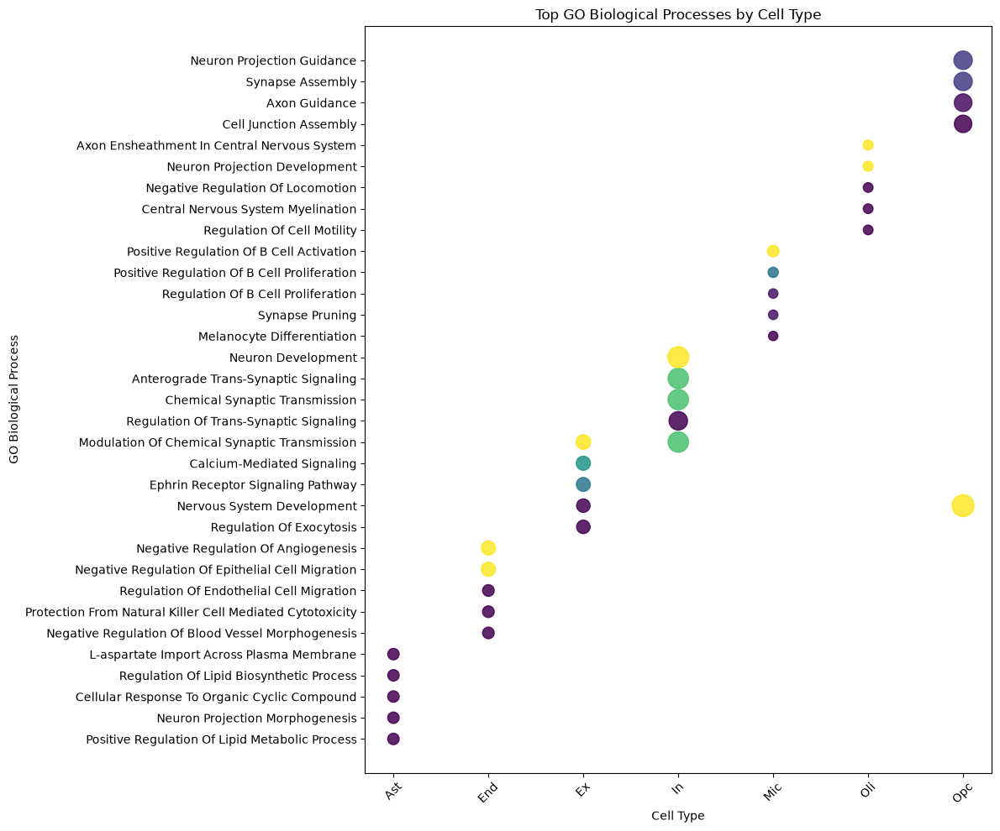

Top-5 GO enrichment figure saved successfully.


In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Top 5 GO terms per cell type
go_top = (
    go_plot
    .sort_values(["Cell Type", "Adjusted P-value"])
    .groupby("Cell Type")
    .head(5)
    .copy()
)

go_top["-log10_adjP"] = -np.log10(go_top["Adjusted P-value"])

# Shorten labels
go_top["Short Term"] = (
    go_top["Term"]
    .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
)

# Reverse order within each cell type for nicer plotting
go_top = go_top.sort_values(
    ["Cell Type", "-log10_adjP"],
    ascending=[True, True]
)

plt.figure(figsize=(12, 10))

for celltype in go_top["Cell Type"].unique():
    subset = go_top[go_top["Cell Type"] == celltype]

    plt.scatter(
        [celltype] * len(subset),
        subset["Short Term"],
        s=subset["-log10_adjP"] * 45,
        c=subset["-log10_adjP"],
        alpha=0.85
    )

plt.xlabel("Cell Type")
plt.ylabel("GO Biological Process")
plt.title("Top GO Biological Processes by Cell Type")

plt.xticks(rotation=45)
plt.tight_layout()

os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/GO_enrichment_top5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top-5 GO enrichment figure saved successfully.")

In [65]:
# Create a clean summary table of the top GO terms
go_summary = (
    go_plot
    .sort_values(["Cell Type", "Adjusted P-value"])
    .groupby("Cell Type")
    .head(5)
    [["Cell Type", "Term", "Adjusted P-value"]]
    .copy()
)

# Rename columns
go_summary.columns = [
    "Cell Type",
    "GO Biological Process",
    "Adjusted P-value"
]

# Save
go_summary.to_csv(
    "results/go/GO_top5_summary.csv",
    index=False
)

print("GO summary saved successfully.")
print(go_summary.to_string(index=False))

GO summary saved successfully.
Cell Type                                                  GO Biological Process  Adjusted P-value
      Ast            Positive Regulation Of Lipid Metabolic Process (GO:0045834)      7.182741e-03
      Ast                           Neuron Projection Morphogenesis (GO:0048812)      7.182741e-03
      Ast              Cellular Response To Organic Cyclic Compound (GO:0071407)      7.182741e-03
      Ast                  Regulation Of Lipid Biosynthetic Process (GO:0046890)      7.182741e-03
      Ast                 L-aspartate Import Across Plasma Membrane (GO:0140009)      7.182741e-03
      End          Negative Regulation Of Epithelial Cell Migration (GO:0010633)      5.528645e-04
      End                       Negative Regulation Of Angiogenesis (GO:0016525)      5.528645e-04
      End         Negative Regulation Of Blood Vessel Morphogenesis (GO:2000181)      6.024620e-03
      End Protection From Natural Killer Cell Mediated Cytotoxicity (GO:004227

In [66]:
# Create an integrated biological interpretation table

marker_summary = {
    "Ast": ["AQP4", "GFAP", "ALDH1L1"],
    "Ex": ["SLC17A7", "CAMK2A"],
    "In": ["GAD1", "GAD2"],
    "Oli": ["MBP", "PLP1", "MOG"],
    "Opc": ["PDGFRA", "CSPG4"],
    "Mic": ["AIF1", "CX3CR1", "C1QA"],
    "End": ["CLDN5", "FLT1", "KDR"]
}

go_functions = {
    "Ast": "Lipid metabolism; lipid biosynthesis; aspartate transport",
    "Ex": "Synaptic transmission; glutamatergic signaling; calcium signaling",
    "In": "Synaptic signaling; calcium-mediated signaling; neuronal development",
    "Oli": "CNS myelination; axon ensheathment; oligodendrocyte development",
    "Opc": "Axon guidance; synapse assembly; neuronal projection",
    "Mic": "Immune-related signaling; cellular response pathways",
    "End": "Angiogenesis; endothelial migration; blood-vessel development"
}

integrated = []

for celltype in marker_summary:
    integrated.append({
        "Cell Type": celltype,
        "Canonical Markers": ", ".join(marker_summary[celltype]),
        "Major GO Functions": go_functions[celltype]
    })

integrated_df = pd.DataFrame(integrated)

print(integrated_df.to_string(index=False))

# Save
integrated_df.to_csv(
    "results/integrated_celltype_interpretation.csv",
    index=False
)

print("\nIntegrated interpretation table saved successfully.")

Cell Type   Canonical Markers                                                   Major GO Functions
      Ast AQP4, GFAP, ALDH1L1            Lipid metabolism; lipid biosynthesis; aspartate transport
       Ex     SLC17A7, CAMK2A    Synaptic transmission; glutamatergic signaling; calcium signaling
       In          GAD1, GAD2 Synaptic signaling; calcium-mediated signaling; neuronal development
      Oli      MBP, PLP1, MOG      CNS myelination; axon ensheathment; oligodendrocyte development
      Opc       PDGFRA, CSPG4                 Axon guidance; synapse assembly; neuronal projection
      Mic  AIF1, CX3CR1, C1QA                 Immune-related signaling; cellular response pathways
      End    CLDN5, FLT1, KDR        Angiogenesis; endothelial migration; blood-vessel development

Integrated interpretation table saved successfully.


In [67]:


import pandas as pd
import os

final_findings = []

celltypes = ["Ast", "Ex", "In", "Oli", "Opc", "Mic", "End"]

for celltype in celltypes:

   
   
    marker_df = markers[
        markers["group"] == celltype
    ].copy()

    marker_df = marker_df.sort_values(
        "scores",
        ascending=False
    )

    top_markers = marker_df["names"].head(5).tolist()

   
    go_df = go_results.get(celltype)

    if go_df is not None and not go_df.empty:

        go_df = go_df.sort_values(
            "Adjusted P-value"
        )

        top_go = go_df["Term"].head(3).tolist()

    else:
        top_go = []

    final_findings.append({
        "Cell Type": celltype,
        "Top Markers": ", ".join(top_markers),
        "Top GO Processes": " | ".join(top_go)
    })

final_findings_df = pd.DataFrame(final_findings)


os.makedirs("results", exist_ok=True)

final_findings_df.to_csv(
    "results/final_biological_findings.csv",
    index=False
)

print("\nFINAL BIOLOGICAL FINDINGS")
print("=" * 80)
print(final_findings_df.to_string(index=False))

print("\nSaved:")
print("results/final_biological_findings.csv")


FINAL BIOLOGICAL FINDINGS
Cell Type                          Top Markers                                                                                                                                                                  Top GO Processes
      Ast    GPC5, DTNA, SLC1A2, ADGRV1, GPM6A            Positive Regulation Of Lipid Metabolic Process (GO:0045834) | Neuron Projection Morphogenesis (GO:0048812) | Cellular Response To Organic Cyclic Compound (GO:0071407)
       Ex   RALYL, KCNIP4, SYT1, KCNQ5, RBFOX1                              Modulation Of Chemical Synaptic Transmission (GO:0050804) | Calcium-Mediated Signaling (GO:0019722) | Ephrin Receptor Signaling Pathway (GO:0048013)
       In   CNTNAP2, GRIP1, ERBB4, NRXN3, KAZN                                         Neuron Development (GO:0048666) | Modulation Of Chemical Synaptic Transmission (GO:0050804) | Chemical Synaptic Transmission (GO:0007268)
      Oli    PLP1, MBP, CTNNA3, ST18, IL1RAPL1                           

In [68]:


print("=" * 70)
print("DATASET METADATA")
print("=" * 70)

print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")

print("\nCell-type column:")
print("final_celltype" in adata.obs.columns)

print("\nAvailable metadata columns:")
for col in adata.obs.columns:
    print(f"  - {col}")

print("\n" + "=" * 70)
print("UNIQUE VALUES IN METADATA")
print("=" * 70)

for col in adata.obs.columns:
    n_unique = adata.obs[col].nunique()
    
    if n_unique <= 20:
        print(f"\n{col} ({n_unique} values):")
        print(adata.obs[col].value_counts(dropna=False).head(20))

DATASET METADATA
Cells: 122,603
Genes: 26,423

Cell-type column:
True

Available metadata columns:
  - cellname
  - final_celltype
  - trem2
  - atscore
  - apoe
  - sampleID
  - n_genes_by_counts
  - log1p_n_genes_by_counts
  - total_counts
  - log1p_total_counts
  - pct_counts_in_top_50_genes
  - pct_counts_in_top_100_genes
  - pct_counts_in_top_200_genes
  - pct_counts_in_top_500_genes
  - total_counts_mt
  - log1p_total_counts_mt
  - pct_counts_mt
  - total_counts_ribo
  - log1p_total_counts_ribo
  - pct_counts_ribo
  - leiden

UNIQUE VALUES IN METADATA

final_celltype (7 values):
final_celltype
Oli    43864
Ex     39244
Ast    15941
In     12121
Opc     6834
Mic     3726
End      873
Name: count, dtype: int64

trem2 (2 values):
trem2
WT      92324
R47H    30279
Name: count, dtype: int64

atscore (3 values):
atscore
A+T+    61550
A+T-    41161
A-T-    19892
Name: count, dtype: int64

apoe (3 values):
apoe
E3/E4    56522
E3/E3    53263
E4/E4    12818
Name: count, dtype: int64

sampl

In [69]:


print("=" * 70)
print("SAMPLE INFORMATION")
print("=" * 70)

print("\nUnique sample IDs:")
print(adata.obs["sampleID"].value_counts(dropna=False))

print("\n" + "=" * 70)
print("TREM2 SUMMARY")
print("=" * 70)

print(adata.obs["trem2"].describe())

print("\nTREM2 values:")
print(adata.obs["trem2"].value_counts(dropna=False).head(20))

print("\n" + "=" * 70)
print("CELL TYPES BY SAMPLE")
print("=" * 70)

print(
    pd.crosstab(
        adata.obs["sampleID"],
        adata.obs["final_celltype"]
    )
)

SAMPLE INFORMATION

Unique sample IDs:
sampleID
8     12654
9     10528
15    10248
10    10233
3     10189
6     10181
1     10057
2      9835
5      8227
12     7284
4      6397
7      6167
13     4697
11     3336
14     2570
Name: count, dtype: int64

TREM2 SUMMARY
count     122603
unique         2
top           WT
freq       92324
Name: trem2, dtype: object

TREM2 values:
trem2
WT      92324
R47H    30279
Name: count, dtype: int64

CELL TYPES BY SAMPLE
final_celltype   Ast  End    Ex    In  Mic   Oli  Opc
sampleID                                             
1                522   57  2637  1200  265  4973  403
2               1080   34  1750   907   22  5528  514
3               2073   65  4615  1338  530   855  713
4                422    5  3669  1372   48   591  290
5                593   63  4586  1410  330   814  431
6               1028   31  3577   976  252  3927  390
7               1269   83  1462   351  207  2365  430
8               1536   76  4838  1036  316  4556  296

In [70]:


sample_genotype = (
    adata.obs.groupby("sampleID")["trem2"]
    .agg(["nunique", lambda x: x.mode()[0]])
    .rename(columns={
        "nunique": "number_of_genotypes",
        "<lambda_0>": "trem2_genotype"
    })
)

print(sample_genotype)

          number_of_genotypes trem2_genotype
sampleID                                    
1                           1             WT
2                           1             WT
3                           1             WT
4                           1             WT
5                           1             WT
6                           1             WT
7                           1           R47H
8                           1             WT
9                           1           R47H
10                          1             WT
11                          1           R47H
12                          1             WT
13                          1             WT
14                          1             WT
15                          1           R47H


In [71]:



adata.obs["genotype"] = adata.obs["trem2"].astype(str)


cell_counts = pd.crosstab(
    adata.obs["sampleID"],
    adata.obs["final_celltype"]
)


cell_pct = cell_counts.div(
    cell_counts.sum(axis=1),
    axis=0
) * 100


sample_genotype = (
    adata.obs.groupby("sampleID")["genotype"]
    .first()
)

cell_pct["genotype"] = sample_genotype

print("CELL-TYPE COMPOSITION (% PER SAMPLE)")
print("=" * 70)
print(cell_pct.round(2))

CELL-TYPE COMPOSITION (% PER SAMPLE)
final_celltype    Ast   End     Ex     In   Mic    Oli    Opc genotype
sampleID                                                              
1                5.19  0.57  26.22  11.93  2.63  49.45   4.01       WT
2               10.98  0.35  17.79   9.22  0.22  56.21   5.23       WT
3               20.35  0.64  45.29  13.13  5.20   8.39   7.00       WT
4                6.60  0.08  57.36  21.45  0.75   9.24   4.53       WT
5                7.21  0.77  55.74  17.14  4.01   9.89   5.24       WT
6               10.10  0.30  35.13   9.59  2.48  38.57   3.83       WT
7               20.58  1.35  23.71   5.69  3.36  38.35   6.97     R47H
8               12.14  0.60  38.23   8.19  2.50  36.00   2.34       WT
9               18.27  0.33  25.23  10.46  1.61  38.06   6.04     R47H
10              14.26  0.74  31.77   5.96  6.66  34.77   5.83       WT
11              18.11  1.50  25.24   4.53  2.82  36.54  11.27     R47H
12              11.75  1.43  25.33   6.2

In [72]:


composition_summary = (
    cell_pct
    .groupby("genotype")
    .mean(numeric_only=True)
    .round(2)
)

print("\nMEAN CELL-TYPE COMPOSITION")
print("=" * 70)
print(composition_summary)


MEAN CELL-TYPE COMPOSITION
final_celltype    Ast   End     Ex     In   Mic    Oli   Opc
genotype                                                    
R47H            17.18  1.00  24.13   7.09  2.72  40.80  7.08
WT              12.47  0.78  33.11  10.26  3.15  34.06  6.17


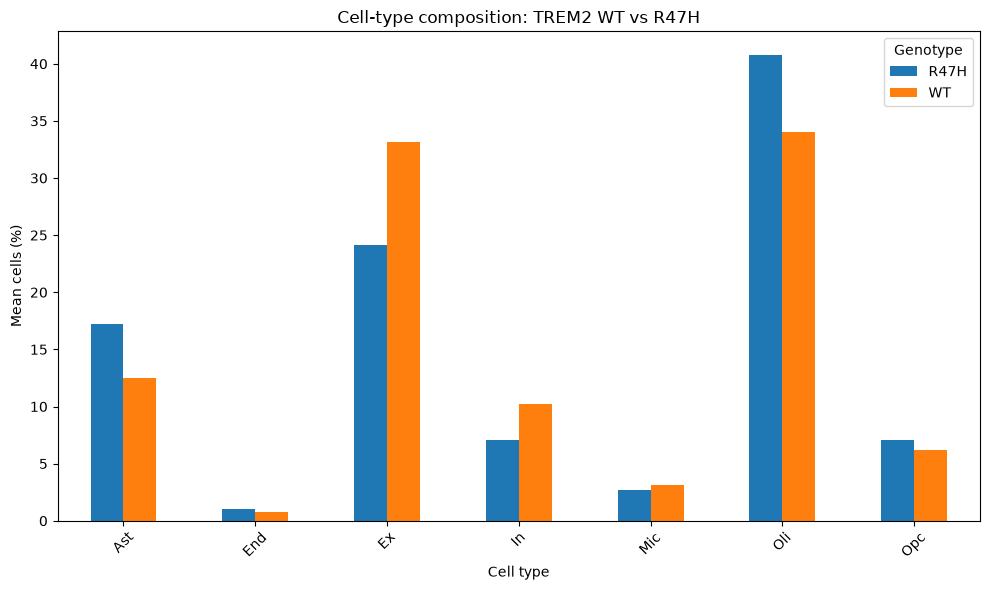

In [73]:


import matplotlib.pyplot as plt

plot_data = composition_summary.T

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Mean cells (%)")
plt.xlabel("Cell type")
plt.title("Cell-type composition: TREM2 WT vs R47H")
plt.xticks(rotation=45)
plt.legend(title="Genotype")
plt.tight_layout()
plt.show()

In [74]:



from scipy.stats import mannwhitneyu

cell_types = [
    "Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"
]

results = []

for celltype in cell_types:
    
    wt = cell_pct.loc[
        cell_pct["genotype"] == "WT", celltype
    ]
    
    r47h = cell_pct.loc[
        cell_pct["genotype"] == "R47H", celltype
    ]
    
    stat, pval = mannwhitneyu(
        r47h,
        wt,
        alternative="two-sided"
    )
    
    results.append({
        "Cell Type": celltype,
        "WT Mean %": wt.mean(),
        "R47H Mean %": r47h.mean(),
        "Difference %": r47h.mean() - wt.mean(),
        "P-value": pval
    })

composition_stats = pd.DataFrame(results)


from statsmodels.stats.multitest import multipletests

composition_stats["Adjusted P-value"] = multipletests(
    composition_stats["P-value"],
    method="fdr_bh"
)[1]

composition_stats = composition_stats.sort_values(
    "Adjusted P-value"
)

print(composition_stats.round(4))

  Cell Type  WT Mean %  R47H Mean %  Difference %  P-value  Adjusted P-value
0       Ast    12.4689      17.1816        4.7127   0.1377            0.5265
2        Ex    33.1079      24.1325       -8.9753   0.2256            0.5265
3        In    10.2634       7.0864       -3.1770   0.2256            0.5265
1       End     0.7819       1.0016        0.2197   0.4117            0.6667
5       Oli    34.0580      40.7986        6.7406   0.5714            0.6667
6       Opc     6.1696       7.0787        0.9090   0.4894            0.6667
4       Mic     3.1503       2.7206       -0.4298   0.9495            0.9495


In [75]:


print("X type:", type(adata.X))
print("X shape:", adata.X.shape)

# Check whether raw counts are available
print("\nRaw counts available:", adata.raw is not None)

# Check layers
print("\nAvailable layers:")
print(list(adata.layers.keys()))

# Show a few values
if hasattr(adata.X, "toarray"):
    print("\nExample X values:")
    print(adata.X[:5, :5].toarray())
else:
    print("\nExample X values:")
    print(adata.X[:5, :5])

X type: <class 'scipy.sparse._csr.csr_matrix'>
X shape: (122603, 26423)

Raw counts available: False

Available layers:
[None]

Example X values:
[[0.        0.        0.        0.        1.2183251]
 [0.        0.        0.        0.        0.       ]
 [0.        0.        0.        0.        0.       ]
 [0.        0.        0.        0.        0.       ]
 [0.        0.        0.        0.        0.       ]]


In [76]:
import h5py
from pathlib import Path

h5ad_path = Path("data/GSE243292_ADsnRNAseq_GEO.h5ad")

print("Checking:", h5ad_path)
print("File size:", round(h5ad_path.stat().st_size / (1024**3), 2), "GB")

with h5py.File(h5ad_path, "r") as f:
    print("\nTop-level groups:")
    for key in f.keys():
        print(" -", key)

    print("\nLayers:")
    if "layers" in f:
        for key in f["layers"].keys():
            print(" -", key)
    else:
        print(" - No layers")

    print("\nRaw:")
    if "raw" in f:
        print(" - RAW COUNTS AVAILABLE")
        print("Raw contents:", list(f["raw"].keys()))
    else:
        print(" - No .raw section")

Checking: data\GSE243292_ADsnRNAseq_GEO.h5ad


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data\\GSE243292_ADsnRNAseq_GEO.h5ad'

In [77]:
from pathlib import Path
import h5py

h5ad_path = Path(r"C:\alz\data\GSE243292_ADsnRNAseq_GEO.h5ad")

print("Checking:", h5ad_path)
print("Exists:", h5ad_path.exists())

if h5ad_path.exists():
    print("File size:", round(h5ad_path.stat().st_size / (1024**3), 2), "GB")

    with h5py.File(h5ad_path, "r") as f:
        print("\nTop-level groups:")
        for key in f.keys():
            print(" -", key)

        print("\nLayers:")
        if "layers" in f:
            for key in f["layers"].keys():
                print(" -", key)
        else:
            print(" - No layers")

        print("\nRaw:")
        if "raw" in f:
            print(" - RAW SECTION AVAILABLE")
            print("Raw contents:", list(f["raw"].keys()))
        else:
            print(" - No .raw section")
else:
    print("FILE NOT FOUND")

Checking: C:\alz\data\GSE243292_ADsnRNAseq_GEO.h5ad
Exists: True
File size: 1.05 GB

Top-level groups:
 - X
 - obs
 - var

Layers:
 - No layers

Raw:
 - No .raw section


In [78]:
import numpy as np
import pandas as pd

print("=" * 70)
print("EXPRESSION MATRIX CHECK")
print("=" * 70)

# Basic statistics from X
X = adata.X

print("Shape:", X.shape)
print("Sparse:", hasattr(X, "tocsr"))

# Non-zero expression statistics
if hasattr(X, "data"):
    values = X.data
else:
    values = np.asarray(X).ravel()

print("Non-zero values:", len(values))
print("Minimum:", values.min())
print("Maximum:", values.max())
print("Mean:", values.mean())
print("Median:", np.median(values))

print("\n" + "=" * 70)
print("SAMPLE / GENOTYPE INFORMATION")
print("=" * 70)

meta = adata.obs.copy()

print("Samples:", meta["sampleID"].nunique())
print("\nGenotype per sample:")

sample_genotype = (
    meta.groupby("sampleID")["trem2"]
    .unique()
    .apply(lambda x: ", ".join(map(str, x)))
)

print(sample_genotype)

print("\n" + "=" * 70)
print("CELLS PER SAMPLE")
print("=" * 70)

print(meta["sampleID"].value_counts().sort_index())

EXPRESSION MATRIX CHECK
Shape: (122603, 26423)
Sparse: True
Non-zero values: 138924404
Minimum: 0.5887126
Maximum: 8.574405
Mean: 1.9477922
Median: 1.9071611

SAMPLE / GENOTYPE INFORMATION
Samples: 15

Genotype per sample:
sampleID
1       WT
2       WT
3       WT
4       WT
5       WT
6       WT
7     R47H
8       WT
9     R47H
10      WT
11    R47H
12      WT
13      WT
14      WT
15    R47H
Name: trem2, dtype: str

CELLS PER SAMPLE
sampleID
1     10057
2      9835
3     10189
4      6397
5      8227
6     10181
7      6167
8     12654
9     10528
10    10233
11     3336
12     7284
13     4697
14     2570
15    10248
Name: count, dtype: int64


In [79]:

coverage = pd.crosstab(
    adata.obs["sampleID"],
    adata.obs["final_celltype"]
)

print("=" * 70)
print("CELL COUNTS PER SAMPLE")
print("=" * 70)
print(coverage)

print("\n" + "=" * 70)
print("NUMBER OF SAMPLES CONTAINING EACH CELL TYPE")
print("=" * 70)

sample_presence = (coverage > 0).sum(axis=0)

print(sample_presence)

print("\n" + "=" * 70)
print("R47H vs WT SAMPLE COVERAGE")
print("=" * 70)

sample_info = (
    adata.obs[["sampleID", "trem2"]]
    .drop_duplicates()
    .set_index("sampleID")
)

for celltype in coverage.columns:

    present = coverage[celltype] > 0

    wt_samples = sum(
        present.index[present] .isin(
            sample_info.index[sample_info["trem2"] == "WT"]
        )
    )

    r47h_samples = sum(
        present.index[present].isin(
            sample_info.index[sample_info["trem2"] == "R47H"]
        )
    )

    print(
        f"{celltype:>5}: "
        f"WT = {wt_samples}/11, "
        f"R47H = {r47h_samples}/4"
    )

CELL COUNTS PER SAMPLE
final_celltype   Ast  End    Ex    In  Mic   Oli  Opc
sampleID                                             
1                522   57  2637  1200  265  4973  403
2               1080   34  1750   907   22  5528  514
3               2073   65  4615  1338  530   855  713
4                422    5  3669  1372   48   591  290
5                593   63  4586  1410  330   814  431
6               1028   31  3577   976  252  3927  390
7               1269   83  1462   351  207  2365  430
8               1536   76  4838  1036  316  4556  296
9               1923   35  2656  1101  170  4007  636
10              1459   76  3251   610  682  3558  597
11               604   50   842   151   94  1219  376
12               856  104  1845   453  175  3344  507
13               833   63   928   378  260  1684  551
14               536   46   297    52   58  1294  287
15              1207   85  2291   786  317  5149  413

NUMBER OF SAMPLES CONTAINING EACH CELL TYPE
final_celltype

In [80]:
# ============================================================
# TREM2 R47H vs WT DIFFERENTIAL EXPRESSION
# SAMPLE-LEVEL ANALYSIS OF NORMALIZED EXPRESSION
# ============================================================

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from pathlib import Path

print("=" * 70)
print("TREM2 R47H vs WT DIFFERENTIAL EXPRESSION")
print("=" * 70)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

RESULTS_DIR = Path("results/trem2_DE")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

celltypes = ["Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"]

# Sample information
sample_info = (
    adata.obs[["sampleID", "trem2"]]
    .drop_duplicates()
    .sort_values("sampleID")
)

wt_samples = sample_info.loc[
    sample_info["trem2"] == "WT", "sampleID"
].tolist()

r47h_samples = sample_info.loc[
    sample_info["trem2"] == "R47H", "sampleID"
].tolist()

print("WT samples:", wt_samples)
print("R47H samples:", r47h_samples)

# Gene names
genes = np.asarray(adata.var_names)

# Expression matrix
X = adata.X

print("\nCells:", X.shape[0])
print("Genes:", X.shape[1])
print("Cell types:", celltypes)

# ------------------------------------------------------------
# Function: calculate sample-level mean expression
# ------------------------------------------------------------

def calculate_sample_means(celltype):

    print(f"\nCalculating sample profiles: {celltype}")

    ct_mask = (
        adata.obs["final_celltype"].values == celltype
    )

    obs_ct = adata.obs.loc[ct_mask].copy()
    X_ct = X[ct_mask]

    sample_ids = obs_ct["sampleID"].values

    unique_samples = sorted(sample_info["sampleID"].unique())

    profiles = []

    for sample in unique_samples:

        sample_mask = sample_ids == sample

        X_sample = X_ct[sample_mask]

        # Mean expression across cells in this sample/cell type
        mean_expr = np.asarray(
            X_sample.mean(axis=0)
        ).ravel()

        profiles.append(mean_expr)

    profiles = np.vstack(profiles)

    profile_df = pd.DataFrame(
        profiles,
        index=unique_samples,
        columns=genes
    )

    return profile_df


# ------------------------------------------------------------
# Differential expression for each cell type
# ------------------------------------------------------------

all_results = []

for celltype in celltypes:

    print("\n" + "-" * 70)
    print(f"ANALYSING: {celltype}")
    print("-" * 70)

    profile_df = calculate_sample_means(celltype)

    wt_expr = profile_df.loc[wt_samples].values
    r47h_expr = profile_df.loc[r47h_samples].values

    # Mean expression
    wt_mean = wt_expr.mean(axis=0)
    r47h_mean = r47h_expr.mean(axis=0)

    # Difference in normalized/log expression
    difference = r47h_mean - wt_mean

    # --------------------------------------------------------
    # Filter genes
    # Require expression in at least 3 samples in BOTH groups
    # --------------------------------------------------------

    wt_detected = (wt_expr > 0).sum(axis=0)
    r47h_detected = (r47h_expr > 0).sum(axis=0)

    keep = (
        (wt_detected >= 3) &
        (r47h_detected >= 3)
    )

    print("Genes before filtering:", len(genes))
    print("Genes after filtering:", keep.sum())

    # --------------------------------------------------------
    # Welch's t-test
    # --------------------------------------------------------

    pvals = np.ones(len(genes))

    if keep.sum() > 0:

        _, p = ttest_ind(
            r47h_expr[:, keep],
            wt_expr[:, keep],
            axis=0,
            equal_var=False,
            nan_policy="omit"
        )

        pvals[keep] = p

    # --------------------------------------------------------
    # Multiple-testing correction
    # --------------------------------------------------------

    padj = np.ones(len(genes))

    if keep.sum() > 0:

        _, corrected, _, _ = multipletests(
            pvals[keep],
            method="fdr_bh"
        )

        padj[keep] = corrected

    # --------------------------------------------------------
    # Create result table
    # --------------------------------------------------------

    result = pd.DataFrame({
        "gene": genes,
        "WT_mean": wt_mean,
        "R47H_mean": r47h_mean,
        "difference_R47H_minus_WT": difference,
        "WT_detected_samples": wt_detected,
        "R47H_detected_samples": r47h_detected,
        "p_value": pvals,
        "adjusted_p_value": padj
    })

    # Rank by statistical significance
    result = result.sort_values(
        ["adjusted_p_value", "p_value"],
        ascending=True
    )

    # Save
    outfile = RESULTS_DIR / f"{celltype}_R47H_vs_WT_DE.csv"
    result.to_csv(outfile, index=False)

    print("Saved:", outfile)

    # Store for combined table
    result["cell_type"] = celltype
    all_results.append(result)

# ------------------------------------------------------------
# Combined results
# ------------------------------------------------------------

combined = pd.concat(
    all_results,
    ignore_index=True
)

combined = combined[
    [
        "cell_type",
        "gene",
        "WT_mean",
        "R47H_mean",
        "difference_R47H_minus_WT",
        "WT_detected_samples",
        "R47H_detected_samples",
        "p_value",
        "adjusted_p_value"
    ]
]

combined.to_csv(
    RESULTS_DIR / "ALL_CELLTYPES_R47H_vs_WT_DE.csv",
    index=False
)

print("\n" + "=" * 70)
print("DE ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Combined results saved:",
    RESULTS_DIR / "ALL_CELLTYPES_R47H_vs_WT_DE.csv"
)

# ------------------------------------------------------------
# Summary of significant genes
# ------------------------------------------------------------

print("\nSIGNIFICANT GENES (FDR < 0.05)")

for celltype in celltypes:

    res = combined[
        (combined["cell_type"] == celltype) &
        (combined["adjusted_p_value"] < 0.05)
    ]

    print(
        f"{celltype:>5}: {len(res)} significant genes"
    )

TREM2 R47H vs WT DIFFERENTIAL EXPRESSION
WT samples: ['1', '2', '3', '4', '5', '6', '8', '10', '12', '13', '14']
R47H samples: ['7', '9', '11', '15']

Cells: 122603
Genes: 26423
Cell types: ['Ast', 'End', 'Ex', 'In', 'Mic', 'Oli', 'Opc']

----------------------------------------------------------------------
ANALYSING: Ast
----------------------------------------------------------------------

Calculating sample profiles: Ast
Genes before filtering: 26423
Genes after filtering: 18963
Saved: results\trem2_DE\Ast_R47H_vs_WT_DE.csv

----------------------------------------------------------------------
ANALYSING: End
----------------------------------------------------------------------

Calculating sample profiles: End
Genes before filtering: 26423
Genes after filtering: 8560
Saved: results\trem2_DE\End_R47H_vs_WT_DE.csv

----------------------------------------------------------------------
ANALYSING: Ex
----------------------------------------------------------------------

Calculating

In [81]:
# ============================================================
# INSPECT TOP TREM2 R47H vs WT DE GENES
# ============================================================

from pathlib import Path
import pandas as pd

DE_DIR = Path("results/trem2_DE")

celltypes = ["Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"]

for celltype in celltypes:

    file = DE_DIR / f"{celltype}_R47H_vs_WT_DE.csv"

    df = pd.read_csv(file)

    # Rank by p-value for exploratory inspection
    top = df.sort_values("p_value").head(15)

    print("\n" + "=" * 90)
    print(f"{celltype} — TOP 15 GENES BY P-VALUE")
    print("=" * 90)

    print(
        top[
            [
                "gene",
                "WT_mean",
                "R47H_mean",
                "difference_R47H_minus_WT",
                "p_value",
                "adjusted_p_value"
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# Specifically inspect TREM2
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("TREM2 EXPRESSION ACROSS CELL TYPES")
print("=" * 90)

for celltype in celltypes:

    file = DE_DIR / f"{celltype}_R47H_vs_WT_DE.csv"
    df = pd.read_csv(file)

    trem2 = df[
        df["gene"].str.upper() == "TREM2"
    ]

    if len(trem2) > 0:
        print(f"\n{celltype}")
        print(
            trem2[
                [
                    "gene",
                    "WT_mean",
                    "R47H_mean",
                    "difference_R47H_minus_WT",
                    "p_value",
                    "adjusted_p_value"
                ]
            ].to_string(index=False)
        )
    else:
        print(f"{celltype}: TREM2 not found")


Ast — TOP 15 GENES BY P-VALUE
      gene  WT_mean  R47H_mean  difference_R47H_minus_WT      p_value  adjusted_p_value
      KLF4 0.003238   0.012732                  0.009493 6.469304e-07          0.012268
    NUDCD1 0.042487   0.021154                 -0.021333 2.415255e-04          0.999693
  SMIM10L1 0.026945   0.014548                 -0.012398 2.561898e-04          0.999693
   COL24A1 0.032995   0.017182                 -0.015813 3.130779e-04          0.999693
AC097658.2 0.021683   0.006775                 -0.014908 3.951986e-04          0.999693
      SSPO 0.038553   0.060843                  0.022290 4.659508e-04          0.999693
    ZNF622 0.018470   0.007557                 -0.010914 5.108734e-04          0.999693
      CDON 0.051116   0.028691                 -0.022424 6.745834e-04          0.999693
    NDUFS6 0.116288   0.068145                 -0.048143 6.780775e-04          0.999693
AC018845.1 0.005672   0.013148                  0.007476 7.187794e-04          0.999693
 

In [82]:

from pathlib import Path
import pandas as pd
import numpy as np

DE_DIR = Path("results/trem2_DE")

mic = pd.read_csv(
    DE_DIR / "Mic_R47H_vs_WT_DE.csv"
)


mic = mic.dropna(
    subset=["p_value", "difference_R47H_minus_WT"]
).copy()


mic["rank_score"] = (
    np.sign(mic["difference_R47H_minus_WT"])
    * -np.log10(
        np.maximum(mic["p_value"], 1e-300)
    )
)


mic_ranked = mic.sort_values(
    "rank_score",
    ascending=False
)

print("=" * 70)
print("MICROGLIA RANKED GENE LIST")
print("=" * 70)

print("\nTop R47H-associated genes:")
print(
    mic_ranked[
        ["gene", "difference_R47H_minus_WT",
         "p_value", "adjusted_p_value", "rank_score"]
    ].head(20).to_string(index=False)
)

print("\nTop WT-associated genes:")
print(
    mic_ranked.sort_values(
        "rank_score",
        ascending=True
    )[
        ["gene", "difference_R47H_minus_WT",
         "p_value", "adjusted_p_value", "rank_score"]
    ].head(20).to_string(index=False)
)


ranked_file = DE_DIR / "Mic_ranked_R47H_vs_WT.csv"

mic_ranked[
    [
        "gene",
        "difference_R47H_minus_WT",
        "p_value",
        "adjusted_p_value",
        "rank_score"
    ]
].to_csv(
    ranked_file,
    index=False
)

print("\nSaved:")
print(ranked_file)

MICROGLIA RANKED GENE LIST

Top R47H-associated genes:
      gene  difference_R47H_minus_WT  p_value  adjusted_p_value  rank_score
    RNF152                  0.020220 0.000019          0.248193    4.721154
SDCBP2-AS1                  0.071215 0.000052          0.342656    4.280055
AL021368.2                  0.028207 0.000151          0.503178    3.821692
AC124947.1                  0.019523 0.000296          0.503178    3.528484
      CPOX                  0.079121 0.000311          0.503178    3.506790
    ZC3H14                  0.090344 0.000312          0.503178    3.505464
    LMNTD1                  0.009170 0.000326          0.503178    3.486502
      GJC2                  0.022568 0.000388          0.503178    3.410844
    FBXO10                  0.006675 0.000455          0.503178    3.341916
   CCDC85C                  0.020029 0.000464          0.503178    3.333859
    RPP25L                  0.024249 0.000510          0.503178    3.292699
     BICD2                  0.058

In [83]:
# ============================================================
# CHECK PATHWAY ANALYSIS PACKAGE
# ============================================================

try:
    import gseapy
    print("gseapy is installed")
    print("Version:", gseapy.__version__)
except ImportError:
    print("gseapy is NOT installed")
    print("We will install it in the next step.")

gseapy is installed
Version: 1.3.1


In [84]:
try:
    import gseapy
    print("gseapy is installed")
    print("Version:", gseapy.__version__)
except ImportError:
    print("gseapy is NOT installed")

gseapy is installed
Version: 1.3.1


In [85]:

import gseapy as gp
import pandas as pd
from pathlib import Path

DE_DIR = Path("results/trem2_DE")
GSEA_DIR = DE_DIR / "GSEA_Microglia"
GSEA_DIR.mkdir(parents=True, exist_ok=True)

# Load ranked Microglia results
mic = pd.read_csv(
    DE_DIR / "Mic_ranked_R47H_vs_WT.csv"
)

# Create ranking dictionary
# Higher score = stronger R47H association
rnk = mic[
    ["gene", "rank_score"]
].dropna().copy()

# Remove duplicate gene names
rnk = rnk.drop_duplicates(
    subset="gene",
    keep="first"
)

# Sort descending
rnk = rnk.sort_values(
    "rank_score",
    ascending=False
)

print("=" * 70)
print("MICROGLIA GO GSEA")
print("=" * 70)

print("Genes in ranked list:", len(rnk))
print("\nTop R47H-ranked genes:")
print(rnk.head(10).to_string(index=False))

print("\nTop WT-ranked genes:")
print(
    rnk.tail(10)
    .sort_values("rank_score")
    .to_string(index=False)
)



pre_res = gp.prerank(
    rnk=rnk,
    gene_sets="GO_Biological_Process_2023",
    threads=4,
    min_size=10,
    max_size=500,
    permutation_num=1000,
    outdir=str(GSEA_DIR),
    seed=42,
    verbose=True
)

# Results
gsea_results = pre_res.res2d.copy()

# Save results
gsea_results.to_csv(
    GSEA_DIR / "Microglia_GO_GSEA_results.csv",
    index=False
)

print("\n" + "=" * 70)
print("GSEA COMPLETE")
print("=" * 70)

print("Results saved to:")
print(GSEA_DIR / "Microglia_GO_GSEA_results.csv")

print("\nTop pathways:")
print(
    gsea_results[
        [
            "Term",
            "NES",
            "NOM p-val",
            "FDR q-val"
        ]
    ]
    .sort_values("FDR q-val")
    .head(20)
    .to_string(index=False)
)

2026-09-27 21:28:20,218 [WARNING] Duplicated values found in preranked stats: 50.58% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-27 21:28:20,219 [INFO] Parsing data files for GSEA.............................


MICROGLIA GO GSEA
Genes in ranked list: 26423

Top R47H-ranked genes:
      gene  rank_score
    RNF152    4.721154
SDCBP2-AS1    4.280055
AL021368.2    3.821692
AC124947.1    3.528484
      CPOX    3.506790
    ZC3H14    3.505464
    LMNTD1    3.486502
      GJC2    3.410844
    FBXO10    3.341916
   CCDC85C    3.333859

Top WT-ranked genes:
       gene  rank_score
      CRLF1   -3.404947
   AURKAIP1   -3.271169
      EIPR1   -3.268094
       NIT1   -3.221562
       MPP1   -3.199935
MIR4435-2HG   -3.168856
       RNF7   -3.148221
     MRFAP1   -2.875456
     MRPL57   -2.870734
     YJEFN3   -2.864512


2026-09-27 21:28:21,936 [INFO] Downloading and generating Enrichr library gene sets......
2026-09-27 21:28:23,856 [INFO] 1964 gene_sets have been filtered out when max_size=500 and min_size=10
2026-09-27 21:28:23,858 [INFO] 3443 gene_sets used for further statistical testing.....
2026-09-27 21:28:23,859 [INFO] Start to run GSEA...Might take a while..................
2026-09-27 21:31:43,488 [INFO] Congratulations. GSEApy runs successfully................




GSEA COMPLETE
Results saved to:
results\trem2_DE\GSEA_Microglia\Microglia_GO_GSEA_results.csv

Top pathways:
                                                                               Term       NES  NOM p-val  FDR q-val
         Detection Of Chemical Stimulus Involved In Sensory Perception (GO:0050907)  2.254844   0.000000   0.000000
Detection Of Chemical Stimulus Involved In Sensory Perception Of Smell (GO:0050911)  2.245109   0.000000   0.000000
                                           Sensory Perception Of Smell (GO:0007608)  2.070068   0.000000   0.000000
                                               Cytoplasmic Translation (GO:0002181) -1.845199   0.000000   0.001013
                                                  Cellular Respiration (GO:0045333) -1.822103   0.000000   0.001519
                                      Aerobic Electron Transport Chain (GO:0019646) -1.735026   0.000000   0.016612
                              Proton Motive Force-Driven ATP Synthesis (GO:001

In [86]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load microglia DE results
de_path = Path("results/trem2_DE/Mic_R47H_vs_WT_DE.csv")
mic_de = pd.read_csv(de_path)

print("Columns:")
print(mic_de.columns.tolist())

print("\nShape:", mic_de.shape)
print(mic_de.head())

Columns:
['gene', 'WT_mean', 'R47H_mean', 'difference_R47H_minus_WT', 'WT_detected_samples', 'R47H_detected_samples', 'p_value', 'adjusted_p_value']

Shape: (26423, 8)
         gene   WT_mean  R47H_mean  difference_R47H_minus_WT  \
0      RNF152  0.005547   0.025767                  0.020220   
1  SDCBP2-AS1  0.022924   0.094139                  0.071215   
2  AL021368.2  0.021201   0.049408                  0.028207   
3  AC124947.1  0.007640   0.027163                  0.019523   
4        CPOX  0.076287   0.155408                  0.079121   

   WT_detected_samples  R47H_detected_samples   p_value  adjusted_p_value  
0                    6                      4  0.000019          0.248193  
1                    8                      4  0.000052          0.342656  
2                    9                      4  0.000151          0.503178  
3                    6                      4  0.000296          0.503178  
4                   10                      4  0.000311          0.

In [87]:
import pandas as pd
import numpy as np
import gseapy as gp
from pathlib import Path



de_path = Path("results/trem2_DE/Mic_R47H_vs_WT_DE.csv")
gsea_dir = Path("results/trem2_DE/GSEA_Microglia_Clean")
gsea_dir.mkdir(parents=True, exist_ok=True)

# Load DE results
df = pd.read_csv(de_path)

# Remove missing / invalid values
df = df.dropna(
    subset=[
        "gene",
        "difference_R47H_minus_WT",
        "p_value"
    ]
).copy()

# Remove duplicate gene names
df = df.drop_duplicates(subset="gene", keep="first")

# Avoid log10(0)
df["p_value_safe"] = df["p_value"].clip(lower=1e-300)


# Positive = R47H-associated
# Negative = WT-associated
df["gsea_score"] = (
    np.sign(df["difference_R47H_minus_WT"])
    * np.abs(df["difference_R47H_minus_WT"])
    * (-np.log10(df["p_value_safe"]))
)

# Remove genes with exactly zero score
df = df[df["gsea_score"] != 0].copy()


# GSEA requires unique ranking values.
# This does NOT materially change the biological ranking.
df = df.sort_values(
    ["gsea_score", "gene"],
    ascending=[False, True]
).reset_index(drop=True)

df["gsea_score"] += (
    np.arange(len(df)) * 1e-12
)

# Sort descending for preranked GSEA
df = df.sort_values(
    "gsea_score",
    ascending=False
)

# Create GSEA ranking file
ranked = df[["gene", "gsea_score"]].copy()

ranked_path = gsea_dir / "Microglia_clean_ranked_genes.rnk"
ranked.to_csv(
    ranked_path,
    sep="\t",
    index=False,
    header=False
)

# Save full ranking for reproducibility
df.to_csv(
    gsea_dir / "Microglia_clean_GSEA_ranking.csv",
    index=False
)

print("=" * 70)
print("CLEAN GSEA RANKING CREATED")
print("=" * 70)

print("Genes:", len(ranked))
print("Duplicate ranking values:",
      ranked["gsea_score"].duplicated().sum())

print("\nTop R47H-associated genes:")
print(
    ranked.head(10).to_string(index=False)
)

print("\nTop WT-associated genes:")
print(
    ranked.tail(10)
    .sort_values("gsea_score")
    .to_string(index=False)
)

print("\nSaved:")
print(ranked_path)

CLEAN GSEA RANKING CREATED
Genes: 13060
Duplicate ranking values: 0

Top R47H-associated genes:
     gene  gsea_score
    GRID2    0.979731
    FKBP5    0.641095
    AUTS2    0.568596
     ATRX    0.544126
LINC02232    0.511177
    ALCAM    0.507019
    FOXP2    0.506156
   TNRC6B    0.501123
   ZBTB16    0.497605
    LRMDA    0.452890

Top WT-associated genes:
   gene  gsea_score
   FTH1   -0.730826
  GAPDH   -0.605359
TMEM163   -0.594195
  H3F3B   -0.467597
 DLGAP2   -0.459891
SPARCL1   -0.441460
    CCK   -0.441104
 RBFOX1   -0.434265
  RPL35   -0.426280
   EML4   -0.405590

Saved:
results\trem2_DE\GSEA_Microglia_Clean\Microglia_clean_ranked_genes.rnk


In [88]:
print("=" * 70)
print("MICROGLIA CLEAN GSEA")
print("=" * 70)

gsea_results = gp.prerank(
    rnk=str(ranked_path),
    gene_sets="GO_Biological_Process_2023",
    outdir=str(gsea_dir / "GO_GSEA"),
    min_size=10,
    max_size=500,
    permutation_num=1000,
    seed=42,
    verbose=True
)

print("\n" + "=" * 70)
print("CLEAN GSEA COMPLETE")
print("=" * 70)

results = gsea_results.res2d.copy()

# Display the most significant pathways
results["FDR q-val"] = pd.to_numeric(
    results["FDR q-val"],
    errors="coerce"
)

top = (
    results
    .sort_values("FDR q-val")
    [["Term", "NES", "NOM p-val", "FDR q-val"]]
    .head(20)
)

print(top.to_string(index=False))

# Save
top.to_csv(
    gsea_dir / "Microglia_Clean_GSEA_Top20.csv",
    index=False
)

print("\nSaved:")
print(gsea_dir / "Microglia_Clean_GSEA_Top20.csv")

2026-09-27 21:33:43,905 [INFO] Parsing data files for GSEA.............................
2026-09-27 21:33:43,927 [INFO] Enrichr library gene sets already downloaded in: C:\Users\devan\.cache/gseapy, use local file
2026-09-27 21:33:44,011 [INFO] 2694 gene_sets have been filtered out when max_size=500 and min_size=10
2026-09-27 21:33:44,013 [INFO] 2713 gene_sets used for further statistical testing.....
2026-09-27 21:33:44,014 [INFO] Start to run GSEA...Might take a while..................


MICROGLIA CLEAN GSEA


2026-09-27 21:35:50,623 [INFO] Congratulations. GSEApy runs successfully................




CLEAN GSEA COMPLETE
                                                               Term       NES  NOM p-val  FDR q-val
                                           Translation (GO:0006412) -1.941885    0.00000   0.000000
                    Macromolecule Biosynthetic Process (GO:0009059) -1.870573    0.00000   0.000000
                               Cytoplasmic Translation (GO:0002181) -1.936939    0.00000   0.000000
                          Peptide Biosynthetic Process (GO:0043043) -1.912604    0.00000   0.000000
                                  Cellular Respiration (GO:0045333) -1.801140    0.00000   0.000553
Mitochondrial ATP Synthesis Coupled Electron Transport (GO:0042775) -1.779930    0.00000   0.001186
                      Aerobic Electron Transport Chain (GO:0019646) -1.782313    0.00000   0.001230
                    Ribosomal Large Subunit Biogenesis (GO:0042273) -1.760677    0.00000   0.002882
              Proton Motive Force-Driven ATP Synthesis (GO:0015986) -1.741310  

In [89]:
#

results = gsea_results.res2d.copy()


for col in ["NES", "NOM p-val", "FDR q-val"]:
    if col in results.columns:
        results[col] = pd.to_numeric(
            results[col],
            errors="coerce"
        )


print("GSEA result columns:")
print(results.columns.tolist())



pathway_keywords = [
    "Translation",
    "Macromolecule Biosynthetic Process",
    "Peptide Biosynthetic Process",
    "Cellular Respiration",
    "Mitochondrial ATP Synthesis",
    "Aerobic Electron Transport Chain",
    "Oxidative Phosphorylation",
    "Aerobic Respiration",
    "Proton Motive Force",
    "Ribosome",
    "Ribosomal",
    "Mitochondrial Respiratory Chain",
    "NADH Dehydrogenase",
    "Type II Interferon"
]

selected = results[
    results["Term"].str.contains(
        "|".join(pathway_keywords),
        case=False,
        regex=True,
        na=False
    )
].copy()

selected = selected[
    selected["FDR q-val"] < 0.05
].sort_values("FDR q-val")

print("\n" + "=" * 70)
print("SIGNIFICANT BIOLOGICALLY RELEVANT PATHWAYS")
print("=" * 70)

print(
    selected[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ].to_string(index=False)
)



if "Lead_genes" in selected.columns:

    print("\n" + "=" * 70)
    print("LEADING-EDGE GENES")
    print("=" * 70)

    for _, row in selected.iterrows():

        genes = str(row["Lead_genes"]).split(";")

        print("\nPATHWAY:")
        print(row["Term"])

        print(
            f"NES = {row['NES']:.3f} | "
            f"FDR = {row['FDR q-val']:.4g}"
        )

        print("Leading-edge genes:")
        print(", ".join(genes[:30]))

else:
    print(
        "\nLead_genes column not found. "
        "We'll inspect the GSEA result structure next."
    )

GSEA result columns:
['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes']

SIGNIFICANT BIOLOGICALLY RELEVANT PATHWAYS
                                                               Term       NES  NOM p-val  FDR q-val
                                           Translation (GO:0006412) -1.941885    0.00000   0.000000
                               Cytoplasmic Translation (GO:0002181) -1.936939    0.00000   0.000000
                          Peptide Biosynthetic Process (GO:0043043) -1.912604    0.00000   0.000000
                    Macromolecule Biosynthetic Process (GO:0009059) -1.870573    0.00000   0.000000
                                  Cellular Respiration (GO:0045333) -1.801140    0.00000   0.000553
Mitochondrial ATP Synthesis Coupled Electron Transport (GO:0042775) -1.779930    0.00000   0.001186
                      Aerobic Electron Transport Chain (GO:0019646) -1.782313    0.00000   0.001230
                    Ribosomal La

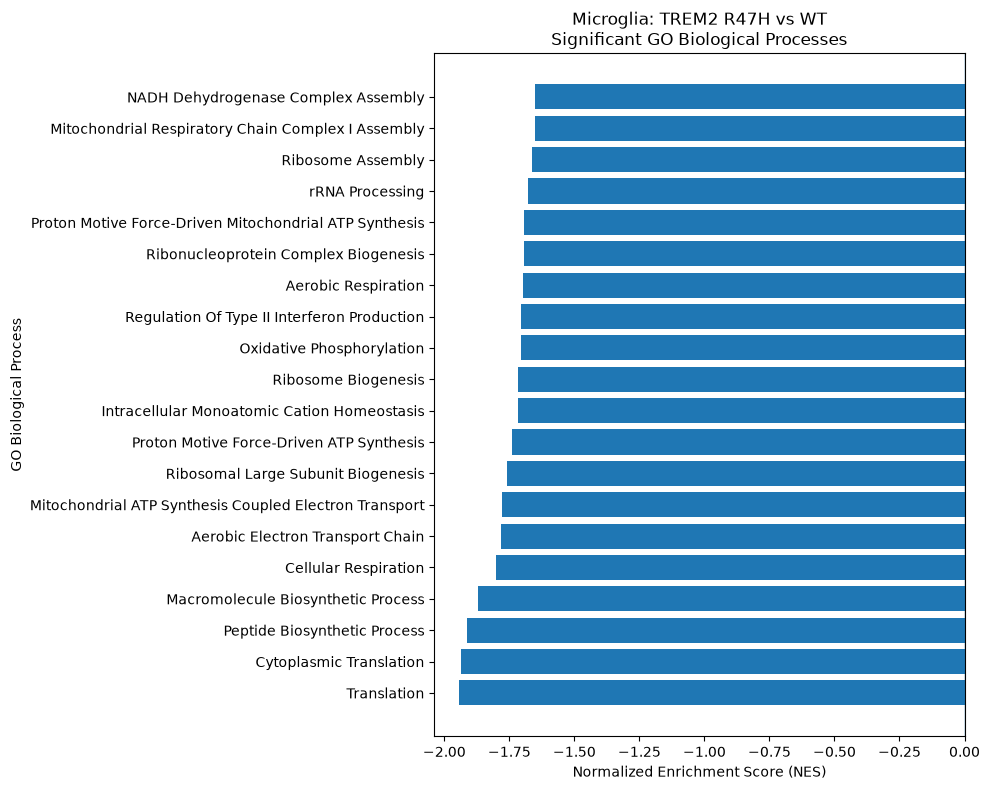

Figure saved:
results\trem2_DE\GSEA_Microglia_Clean\Microglia_GSEA_summary.png

Significant pathways plotted: 20


In [90]:


import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load cleaned GSEA results
gsea_path = Path(
    "results/trem2_DE/GSEA_Microglia_Clean/"
    "Microglia_Clean_GSEA_Top20.csv"
)

gsea = pd.read_csv(gsea_path)


plot_df = gsea[gsea["FDR q-val"] < 0.05].copy()


plot_df = plot_df.sort_values("NES")


plot_df["Pathway"] = (
    plot_df["Term"]
    .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
)

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["Pathway"],
    plot_df["NES"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Normalized Enrichment Score (NES)")
plt.ylabel("GO Biological Process")
plt.title(
    "Microglia: TREM2 R47H vs WT\n"
    "Significant GO Biological Processes"
)

plt.tight_layout()

# Save
out = Path(
    "results/trem2_DE/GSEA_Microglia_Clean/"
    "Microglia_GSEA_summary.png"
)

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(out)

print("\nSignificant pathways plotted:", len(plot_df))

In [91]:

# MICROGLIA TREM2 R47H vs WT
# LEADING-EDGE GENE HEATMAP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse



gsea_path = Path(
    "results/trem2_DE/GSEA_Microglia_Clean/"
    "Microglia_Clean_GSEA_Top20.csv"
)

gsea = pd.read_csv(gsea_path)

# Pathways we want to validate
target_pathways = [
    "Translation (GO:0006412)",
    "Cellular Respiration (GO:0045333)",
    "Oxidative Phosphorylation (GO:0006119)",
    "Regulation Of Type II Interferon Production (GO:0032649)"
]

selected = gsea[gsea["Term"].isin(target_pathways)].copy()



leading_genes = []

for _, row in selected.iterrows():

    genes = str(row["Lead_genes"]).split(";")

    # Take first 10 leading-edge genes per pathway
    genes = [g.strip() for g in genes[:10]]

    leading_genes.extend(genes)

# Remove duplicates while preserving order
leading_genes = list(dict.fromkeys(leading_genes))

print("Leading-edge genes selected:", len(leading_genes))
print(leading_genes)



try:
    adata
    print("\nUsing existing AnnData object.")

except NameError:

    import scanpy as sc

    h5ad_path = Path(
        r"C:\alz\data\GSE243292_ADsnRNAseq_GEO.h5ad"
    )

    print("\nLoading:", h5ad_path)

    adata = sc.read_h5ad(h5ad_path)



print("\nDataset:")
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

print("\nCell types:")
print(adata.obs["final_celltype"].value_counts())



mic = adata[adata.obs["final_celltype"] == "Mic"].copy()

print("\nMicroglia cells:", mic.n_obs)


available_genes = [
    g for g in leading_genes
    if g in mic.var_names
]

missing_genes = [
    g for g in leading_genes
    if g not in mic.var_names
]

print("\nGenes found:", len(available_genes))
print("Genes missing:", len(missing_genes))

if missing_genes:
    print("\nMissing genes:")
    print(missing_genes)



sample_ids = mic.obs["sampleID"].astype(str)

samples = sorted(sample_ids.unique(), key=lambda x: int(x))

print("\nSamples:")
print(samples)

expression_matrix = []

for sample in samples:

    cells = mic[sample_ids == sample]

    X = cells[:, available_genes].X

    if sparse.issparse(X):
        X = X.toarray()

    mean_expression = np.asarray(X).mean(axis=0)

    expression_matrix.append(mean_expression)

expression_matrix = np.array(expression_matrix)

# genes × samples
expression_matrix = expression_matrix.T



gene_mean = expression_matrix.mean(axis=1, keepdims=True)
gene_std = expression_matrix.std(axis=1, keepdims=True)

gene_std[gene_std == 0] = 1

z_matrix = (
    expression_matrix - gene_mean
) / gene_std



sample_genotype = (
    mic.obs[["sampleID", "trem2"]]
    .drop_duplicates()
)

sample_genotype["sampleID"] = (
    sample_genotype["sampleID"].astype(str)
)

sample_genotype = (
    sample_genotype
    .set_index("sampleID")
    .loc[samples]
)

genotypes = sample_genotype["trem2"].tolist()

print("\nSample genotypes:")
for s, g in zip(samples, genotypes):
    print(s, g)


fig, ax = plt.subplots(
    figsize=(14, max(8, len(available_genes) * 0.30))
)

im = ax.imshow(
    z_matrix,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xticks(range(len(samples)))
ax.set_xticklabels(
    [
        f"{s}\n{g}"
        for s, g in zip(samples, genotypes)
    ],
    rotation=0
)

ax.set_yticks(range(len(available_genes)))
ax.set_yticklabels(available_genes)

ax.set_xlabel("Biological Sample")
ax.set_ylabel("Leading-edge Gene")

ax.set_title(
    "Microglia TREM2 R47H vs WT\n"
    "GSEA Leading-edge Genes"
)

plt.colorbar(
    im,
    ax=ax,
    label="Expression Z-score"
)

plt.tight_layout()



out = Path(
    "results/trem2_DE/GSEA_Microglia_Clean/"
    "Microglia_GSEA_leading_edge_heatmap.png"
)

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n============================================================")
print("HEATMAP COMPLETE")
print("============================================================")
print("Saved:")
print(out)

KeyError: 'Lead_genes'

In [92]:
from pathlib import Path

gsea_dir = Path("results/trem2_DE/GSEA_Microglia_Clean")

print("Files in GSEA folder:\n")

for f in gsea_dir.rglob("*"):
    if f.is_file():
        print(f)
        

Files in GSEA folder:

results\trem2_DE\GSEA_Microglia_Clean\Microglia_clean_GSEA_ranking.csv
results\trem2_DE\GSEA_Microglia_Clean\Microglia_Clean_GSEA_Top20.csv
results\trem2_DE\GSEA_Microglia_Clean\Microglia_clean_ranked_genes.rnk
results\trem2_DE\GSEA_Microglia_Clean\Microglia_GSEA_summary.png
results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\gene_sets.gmt
results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\gseapy.gene_set.prerank.report.csv
results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\prerank_data.rnk
results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\prerank\Aerobic Electron Transport Chain (GO_0019646).pdf
results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\prerank\Aerobic Respiration (GO_0009060).pdf
results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\prerank\Cellular Respiration (GO_0045333).pdf
results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\prerank\Cytoplasmic Translation (GO_0002181).pdf
results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\prerank\Intracellular Monoatomic Cation Homeostasis (GO_0030003).pdf


GSEA columns:
['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes']

Selected pathways:
                                                    Term       NES  FDR q-val
                                Translation (GO:0006412) -1.941885   0.000000
                       Cellular Respiration (GO:0045333) -1.801140   0.000553
                  Oxidative Phosphorylation (GO:0006119) -1.707010   0.015600
Regulation Of Type II Interferon Production (GO:0032649) -1.706169   0.014826

Leading-edge genes selected: 34
['RPL35', 'RPL38', 'RPL10', 'RPS20', 'MRPL57', 'RPS27A', 'MRPL33', 'AURKAIP1', 'RPS16', 'RPL27', 'UQCR10', 'COX7C', 'NDUFB9', 'NDUFA4', 'NDUFS6', 'NDUFS7', 'NDUFB11', 'NDUFA2', 'NDUFB5', 'COX5B', 'ATP5MG', 'NDUFB10', 'NDUFS3', 'ATP5F1B', 'CD14', 'LAPTM5', 'SLC11A1', 'SIRPA', 'PDE4D', 'SLC7A5', 'TLR7', 'HLA-DRB1', 'EBI3', 'DDIT3']

Using existing AnnData object.

Microglia cells: 3726
Genes found: 34
Genes missing: 0

Sample / genotype:


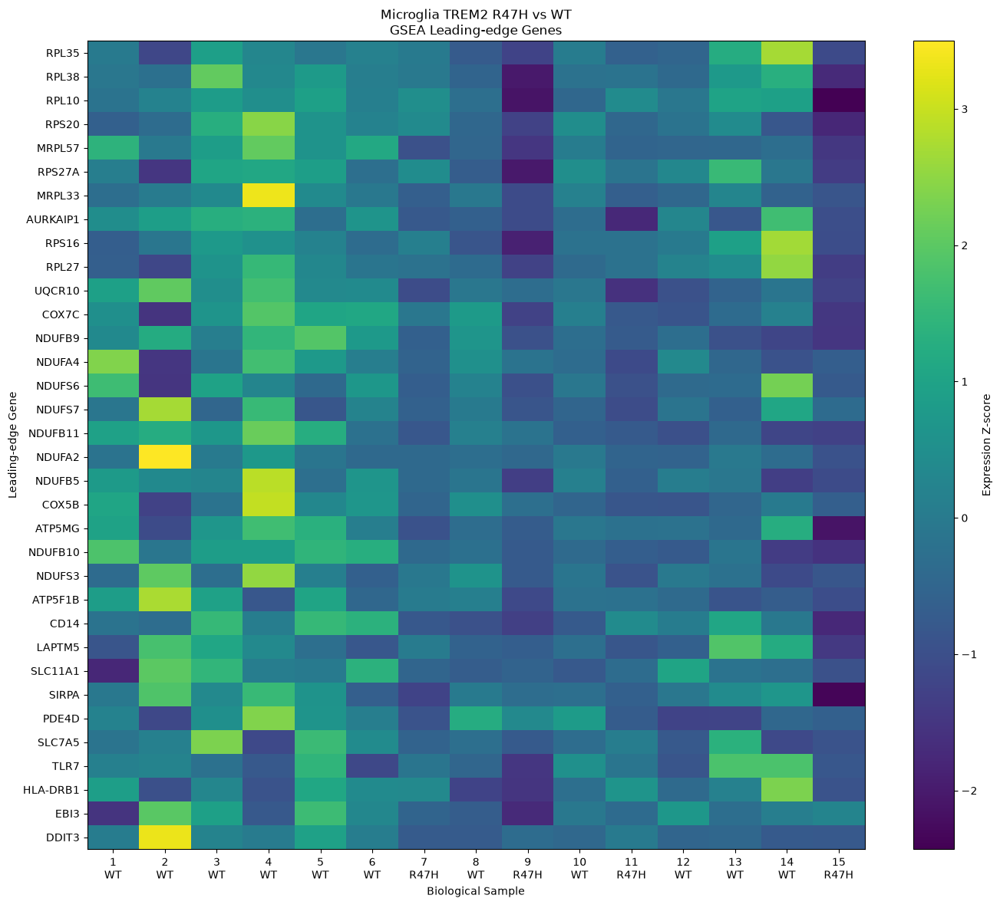


LEADING-EDGE HEATMAP COMPLETE
Saved:
results\trem2_DE\GSEA_Microglia_Clean\Microglia_GSEA_leading_edge_heatmap.png


In [93]:
# ============================================================
# MICROGLIA GSEA — LEADING EDGE HEATMAP
# Corrected to use the full GSEApy report
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse

# ------------------------------------------------------------
# 1. Load FULL GSEApy report
# ------------------------------------------------------------

gsea_path = Path(
    "results/trem2_DE/GSEA_Microglia_Clean/"
    "GO_GSEA/gseapy.gene_set.prerank.report.csv"
)

gsea = pd.read_csv(gsea_path)

print("GSEA columns:")
print(gsea.columns.tolist())

# ------------------------------------------------------------
# 2. Select biologically important pathways
# ------------------------------------------------------------

target_pathways = [
    "Translation (GO:0006412)",
    "Cellular Respiration (GO:0045333)",
    "Oxidative Phosphorylation (GO:0006119)",
    "Regulation Of Type II Interferon Production (GO:0032649)"
]

selected = gsea[gsea["Term"].isin(target_pathways)].copy()

print("\nSelected pathways:")
print(selected[["Term", "NES", "FDR q-val"]].to_string(index=False))

# ------------------------------------------------------------
# 3. Extract leading-edge genes
# ------------------------------------------------------------

leading_genes = []

for _, row in selected.iterrows():

    genes = str(row["Lead_genes"])

    # GSEApy generally separates genes with ";"
    genes = genes.split(";")

    # First 10 genes from each pathway
    genes = [g.strip() for g in genes[:10]]

    leading_genes.extend(genes)

# Remove duplicates while preserving order
leading_genes = list(dict.fromkeys(leading_genes))

print("\nLeading-edge genes selected:", len(leading_genes))
print(leading_genes)

# ------------------------------------------------------------
# 4. Load AnnData
# ------------------------------------------------------------

try:
    adata
    print("\nUsing existing AnnData object.")

except NameError:

    import scanpy as sc

    h5ad_path = Path(
        r"C:\alz\data\GSE243292_ADsnRNAseq_GEO.h5ad"
    )

    print("\nLoading AnnData...")
    adata = sc.read_h5ad(h5ad_path)

# ------------------------------------------------------------
# 5. Select microglia
# ------------------------------------------------------------

mic = adata[
    adata.obs["final_celltype"] == "Mic"
].copy()

print("\nMicroglia cells:", mic.n_obs)

# ------------------------------------------------------------
# 6. Keep genes present in dataset
# ------------------------------------------------------------

available_genes = [
    g for g in leading_genes
    if g in mic.var_names
]

missing_genes = [
    g for g in leading_genes
    if g not in mic.var_names
]

print("Genes found:", len(available_genes))
print("Genes missing:", len(missing_genes))

if missing_genes:
    print("\nMissing genes:")
    print(missing_genes)

# ------------------------------------------------------------
# 7. Calculate sample-level mean expression
# ------------------------------------------------------------

sample_ids = mic.obs["sampleID"].astype(str)

samples = sorted(
    sample_ids.unique(),
    key=lambda x: int(x)
)

expression_matrix = []

for sample in samples:

    cells = mic[sample_ids == sample]

    X = cells[:, available_genes].X

    if sparse.issparse(X):
        X = X.toarray()

    mean_expression = np.asarray(X).mean(axis=0)

    expression_matrix.append(mean_expression)

expression_matrix = np.array(expression_matrix)

# Convert samples × genes → genes × samples
expression_matrix = expression_matrix.T

# ------------------------------------------------------------
# 8. Z-score each gene across biological samples
# ------------------------------------------------------------

gene_mean = expression_matrix.mean(
    axis=1,
    keepdims=True
)

gene_std = expression_matrix.std(
    axis=1,
    keepdims=True
)

gene_std[gene_std == 0] = 1

z_matrix = (
    expression_matrix - gene_mean
) / gene_std

# ------------------------------------------------------------
# 9. Get genotype for each biological sample
# ------------------------------------------------------------

sample_genotype = (
    mic.obs[["sampleID", "trem2"]]
    .drop_duplicates()
)

sample_genotype["sampleID"] = (
    sample_genotype["sampleID"].astype(str)
)

sample_genotype = (
    sample_genotype
    .set_index("sampleID")
    .loc[samples]
)

genotypes = sample_genotype["trem2"].tolist()

print("\nSample / genotype:")
for sample, genotype in zip(samples, genotypes):
    print(f"{sample}: {genotype}")

# ------------------------------------------------------------
# 10. Plot heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(
        14,
        max(8, len(available_genes) * 0.35)
    )
)

im = ax.imshow(
    z_matrix,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xticks(range(len(samples)))

ax.set_xticklabels(
    [
        f"{s}\n{g}"
        for s, g in zip(samples, genotypes)
    ]
)

ax.set_yticks(
    range(len(available_genes))
)

ax.set_yticklabels(
    available_genes
)

ax.set_xlabel(
    "Biological Sample"
)

ax.set_ylabel(
    "Leading-edge Gene"
)

ax.set_title(
    "Microglia TREM2 R47H vs WT\n"
    "GSEA Leading-edge Genes"
)

plt.colorbar(
    im,
    ax=ax,
    label="Expression Z-score"
)

plt.tight_layout()

# ------------------------------------------------------------
# 11. Save
# ------------------------------------------------------------

out = Path(
    "results/trem2_DE/GSEA_Microglia_Clean/"
    "Microglia_GSEA_leading_edge_heatmap.png"
)

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n============================================================")
print("LEADING-EDGE HEATMAP COMPLETE")
print("============================================================")
print("Saved:")
print(out)

In [94]:
import pandas as pd
from pathlib import Path


gsea_file = Path(
    r"results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\gseapy.gene_set.prerank.report.csv"
)

# Load GSEA results
gsea = pd.read_csv(gsea_file)

print("Columns:")
print(gsea.columns.tolist())
print("\nShape:", gsea.shape)

Columns:
['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes']

Shape: (2713, 10)


In [99]:
import pandas as pd
from pathlib import Path


gsea = pd.read_csv(gsea_file)

# Keep significant pathways
sig = gsea[gsea["FDR q-val"] < 0.05].copy()

print("Significant pathways:", len(sig))



edges = []

for _, row in sig.iterrows():

    pathway = row["Term"]
    genes = str(row["Lead_genes"])

    # GSEApy usually separates genes with ";"
    gene_list = [
        g.strip()
        for g in genes.replace(",", ";").split(";")
        if g.strip()
    ]

    for gene in gene_list:
        edges.append({
            "Source": pathway,
            "Target": gene,
            "NES": row["NES"],
            "FDR": row["FDR q-val"],
            "Pathway": pathway
        })

network = pd.DataFrame(edges)
# Create node attribute table for Cytoscape
all_nodes = pd.unique(network[["Source", "Target"]].values.ravel())

node_attributes = pd.DataFrame({
    "name": all_nodes
})

# Pathway nodes are the Source nodes; gene nodes are the Target nodes
pathway_nodes = set(network["Source"].unique())

node_attributes["NodeType"] = node_attributes["name"].apply(
    lambda x: "Pathway" if x in pathway_nodes else "Gene"
)

# Save node attributes
node_attr_file = r"results\trem2_DE\GSEA_Microglia_Clean\node_attributes.csv"
node_attributes.to_csv(node_attr_file, index=False)

print("\nNODE ATTRIBUTE TABLE CREATED")
print("Nodes:", len(node_attributes))
print("Pathway nodes:", (node_attributes["NodeType"] == "Pathway").sum())
print("Gene nodes:", (node_attributes["NodeType"] == "Gene").sum())
print("Saved:", node_attr_file)

# Remove duplicate pathway-gene connections
network = network.drop_duplicates(
    subset=["Source", "Target"]
)

# Save
out_file = Path(
    r"results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv"
)

network.to_csv(out_file, index=False)

print("\n========================================")
print("PATHWAY-GENE NETWORK CREATED")
print("========================================")
print("Edges:", len(network))
print("Pathways:", network["Source"].nunique())
print("Genes:", network["Target"].nunique())
print("\nSaved:")
print(out_file)

print("\nFirst 20 edges:")
print(network.head(20).to_string(index=False))

Significant pathways: 23

NODE ATTRIBUTE TABLE CREATED
Nodes: 267
Pathway nodes: 23
Gene nodes: 244
Saved: results\trem2_DE\GSEA_Microglia_Clean\node_attributes.csv

PATHWAY-GENE NETWORK CREATED
Edges: 728
Pathways: 23
Genes: 244

Saved:
results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv

First 20 edges:
                  Source   Target       NES  FDR                  Pathway
Translation (GO:0006412)    RPL35 -1.941885  0.0 Translation (GO:0006412)
Translation (GO:0006412)    RPL38 -1.941885  0.0 Translation (GO:0006412)
Translation (GO:0006412)    RPL10 -1.941885  0.0 Translation (GO:0006412)
Translation (GO:0006412)    RPS20 -1.941885  0.0 Translation (GO:0006412)
Translation (GO:0006412)   MRPL57 -1.941885  0.0 Translation (GO:0006412)
Translation (GO:0006412)   RPS27A -1.941885  0.0 Translation (GO:0006412)
Translation (GO:0006412)   MRPL33 -1.941885  0.0 Translation (GO:0006412)
Translation (GO:0006412) AURKAIP1 -1.941885  0.0 Translation (GO:0006412)
Translation (GO:

In [96]:
from pathlib import Path

p = Path("results/trem2_DE/GSEA_Microglia_Clean/pathway_gene_network.csv")

print("Current working directory:")
print(Path.cwd())

print("\nExpected file:")
print(p.resolve())

print("\nExists:", p.exists())

Current working directory:
c:\alz\notebooks

Expected file:
C:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv

Exists: True


In [100]:
from pathlib import Path

results_dir = Path("results/term2_DE/GSEA_Microglia_Clean")

print("Files in GSEA results:")
for f in results_dir.iterdir():
    print(f.name)

Files in GSEA results:


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'results\\term2_DE\\GSEA_Microglia_Clean'

In [101]:
from pathlib import Path

results_dir = Path("../results/term2_DE/GSEA_Microglia_Clean")

print("Looking in:", results_dir.resolve())
print("Exists:", results_dir.exists())

if results_dir.exists():
    print("\nFiles in GSEA results:")
    for f in results_dir.iterdir():
        print(f.name)

Looking in: C:\alz\results\term2_DE\GSEA_Microglia_Clean
Exists: False


In [102]:
from pathlib import Path

results_dir = Path("../results")

print("RESULTS FOLDER:")
for item in results_dir.iterdir():
    print(item)

RESULTS FOLDER:
..\results\annotated_dataset.h5ad


In [103]:
from pathlib import Path

project = Path("..")

print("Searching for GSEA-related files...\n")

found = []

for p in project.rglob("*"):
    if p.is_file():
        name = p.name.lower()
        if (
            "gsea" in name
            or "enrich" in name
            or name.endswith(".rnk")
            or name.endswith(".gct")
            or name.endswith(".gmt")
        ):
            found.append(p)

if found:
    for p in found:
        print(p)
else:
    print("NO GSEA-RELATED FILES FOUND")

Searching for GSEA-related files...

..\notebooks\figures\GO_enrichment_dotplot.png
..\notebooks\figures\GO_enrichment_top5.png
..\notebooks\results\go\Ast_GO_enrichment.csv
..\notebooks\results\go\End_GO_enrichment.csv
..\notebooks\results\go\Ex_GO_enrichment.csv
..\notebooks\results\go\In_GO_enrichment.csv
..\notebooks\results\go\Mic_GO_enrichment.csv
..\notebooks\results\go\Oli_GO_enrichment.csv
..\notebooks\results\go\Opc_GO_enrichment.csv
..\notebooks\results\trem2_DE\GSEA_Microglia\gene_sets.gmt
..\notebooks\results\trem2_DE\GSEA_Microglia\gseapy.gene_set.prerank.report.csv
..\notebooks\results\trem2_DE\GSEA_Microglia\Microglia_GO_GSEA_results.csv
..\notebooks\results\trem2_DE\GSEA_Microglia\prerank_data.rnk
..\notebooks\results\trem2_DE\GSEA_Microglia_Clean\Microglia_clean_GSEA_ranking.csv
..\notebooks\results\trem2_DE\GSEA_Microglia_Clean\Microglia_Clean_GSEA_Top20.csv
..\notebooks\results\trem2_DE\GSEA_Microglia_Clean\Microglia_clean_ranked_genes.rnk
..\notebooks\results\trem2

In [104]:
from pathlib import Path

results_dir = Path("results/trem2_DE/GSEA_Microglia_Clean")

print("GSEA CLEAN FILES:\n")

for f in results_dir.iterdir():
    print(f.name)

GSEA CLEAN FILES:

GO_GSEA
Microglia_clean_GSEA_ranking.csv
Microglia_Clean_GSEA_Top20.csv
Microglia_clean_ranked_genes.rnk
Microglia_GSEA_leading_edge_heatmap.png
Microglia_GSEA_summary.png
node_attributes.csv
pathway_gene_network.csv


In [105]:
import pandas as pd
from pathlib import Path

results_dir = Path("results/trem2_DE/GSEA_Microglia_Clean")

top20 = pd.read_csv(results_dir / "Microglia_Clean_GSEA_Top20.csv")
network = pd.read_csv(results_dir / "pathway_gene_network.csv")
nodes = pd.read_csv(results_dir / "node_attributes.csv")

print("===== TOP 20 GSEA =====")
print("Columns:", top20.columns.tolist())
display(top20)

print("\n===== PATHWAY-GENE NETWORK =====")
print("Shape:", network.shape)
print("Columns:", network.columns.tolist())
display(network.head(10))

print("\n===== NODE ATTRIBUTES =====")
print("Shape:", nodes.shape)
print("Columns:", nodes.columns.tolist())
display(nodes.head(10))

===== TOP 20 GSEA =====
Columns: ['Term', 'NES', 'NOM p-val', 'FDR q-val']


,Term,NES,NOM p-val,FDR q-val
0,Translation (GO:0006412),-1.941885,0.00000,0.000000
1,Macromolecule Biosynthetic Process (GO:0009059),-1.870573,0.00000,0.000000
2,Cytoplasmic Translation (GO:0002181),-1.936939,0.00000,0.000000
3,Peptide Biosynthetic Process (GO:0043043),-1.912604,0.00000,0.000000
4,Cellular Respiration (GO:0045333),-1.801140,0.00000,0.000553
5,Mitochondrial ATP Synthesis Coupled Electron T...,-1.779930,0.00000,0.001186
6,Aerobic Electron Transport Chain (GO:0019646),-1.782313,0.00000,0.001230
7,Ribosomal Large Subunit Biogenesis (GO:0042273),-1.760677,0.00000,0.002882
8,Proton Motive Force-Driven ATP Synthesis (GO:0...,-1.741310,0.00000,0.006250
9,Ribosome Biogenesis (GO:0042254),-1.716030,0.00000,0.013162



===== PATHWAY-GENE NETWORK =====
Shape: (728, 5)
Columns: ['Source', 'Target', 'NES', 'FDR', 'Pathway']


,Source,Target,NES,FDR,Pathway
0,Translation (GO:0006412),RPL35,-1.941885,0.0,Translation (GO:0006412)
1,Translation (GO:0006412),RPL38,-1.941885,0.0,Translation (GO:0006412)
2,Translation (GO:0006412),RPL10,-1.941885,0.0,Translation (GO:0006412)
3,Translation (GO:0006412),RPS20,-1.941885,0.0,Translation (GO:0006412)
4,Translation (GO:0006412),MRPL57,-1.941885,0.0,Translation (GO:0006412)
5,Translation (GO:0006412),RPS27A,-1.941885,0.0,Translation (GO:0006412)
6,Translation (GO:0006412),MRPL33,-1.941885,0.0,Translation (GO:0006412)
7,Translation (GO:0006412),AURKAIP1,-1.941885,0.0,Translation (GO:0006412)
8,Translation (GO:0006412),RPS16,-1.941885,0.0,Translation (GO:0006412)
9,Translation (GO:0006412),RPL27,-1.941885,0.0,Translation (GO:0006412)



===== NODE ATTRIBUTES =====
Shape: (267, 2)
Columns: ['name', 'NodeType']


,name,NodeType
0,Translation (GO:0006412),Pathway
1,RPL35,Gene
2,RPL38,Gene
3,RPL10,Gene
4,RPS20,Gene
5,MRPL57,Gene
6,RPS27A,Gene
7,MRPL33,Gene
8,AURKAIP1,Gene
9,RPS16,Gene


In [106]:
import pandas as pd
from pathlib import Path

network_file = Path("../results/term2_DE/GSEA_Microglia_Clean/pathway_gene_network.csv")

network = pd.read_csv(network_file)

print("Shape:", network.shape)
print("Columns:", network.columns.tolist())
display(network.head(20))

FileNotFoundError: [Errno 2] No such file or directory: '..\\results\\term2_DE\\GSEA_Microglia_Clean\\pathway_gene_network.csv'

In [107]:
from pathlib import Path
import pandas as pd

network_file = Path("results/term2_DE/GSEA_Microglia_Clean/pathway_gene_network.csv")

print("Looking for:")
print(network_file.resolve())
print("Exists:", network_file.exists())

if network_file.exists():
    network = pd.read_csv(network_file)

    print("\nShape:", network.shape)
    print("\nColumns:", network.columns.tolist())
    display(network.head(20))

Looking for:
C:\alz\notebooks\results\term2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv
Exists: False


In [108]:
from pathlib import Path

project = Path.cwd().parent

matches = list(project.rglob("pathway_gene_network.csv"))

print("Current working directory:", Path.cwd())
print("\nFiles found:")

for f in matches:
    print(f.resolve())

Current working directory: c:\alz\notebooks

Files found:
C:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv


In [109]:
import pandas as pd
from pathlib import Path

network_file = Path("results/term2_DE/GSEA_Microglia_Clean/pathway_gene_network.csv")

network = pd.read_csv(network_file)

print("Shape:", network.shape)
print("\nColumns:")
print(network.columns.tolist())

print("\nFirst 20 rows:")
display(network.head(20))

FileNotFoundError: [Errno 2] No such file or directory: 'results\\term2_DE\\GSEA_Microglia_Clean\\pathway_gene_network.csv'

In [110]:
import pandas as pd

network_file = r"C:\alz\notebooks\results\term2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv"

network = pd.read_csv(network_file)

print("Shape:", network.shape)
print("\nColumns:")
print(network.columns.tolist())

print("\nFirst 20 rows:")
display(network.head(20))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\alz\\notebooks\\results\\term2_DE\\GSEA_Microglia_Clean\\pathway_gene_network.csv'

In [111]:
from pathlib import Path
import pandas as pd

# Find the file automatically from the notebook's actual location
matches = list(Path.cwd().rglob("pathway_gene_network.csv"))

print("Files found:")
for f in matches:
    print(f)

# Load the first matching file
network_file = matches[0]
network = pd.read_csv(network_file)

print("\nLoaded:", network_file)
print("Shape:", network.shape)
print("Columns:", network.columns.tolist())

print("\nFirst 20 rows:")
display(network.head(20))

Files found:
c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv

Loaded: c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv
Shape: (728, 5)
Columns: ['Source', 'Target', 'NES', 'FDR', 'Pathway']

First 20 rows:


,Source,Target,NES,FDR,Pathway
0,Translation (GO:0006412),RPL35,-1.941885,0.0,Translation (GO:0006412)
1,Translation (GO:0006412),RPL38,-1.941885,0.0,Translation (GO:0006412)
2,Translation (GO:0006412),RPL10,-1.941885,0.0,Translation (GO:0006412)
3,Translation (GO:0006412),RPS20,-1.941885,0.0,Translation (GO:0006412)
4,Translation (GO:0006412),MRPL57,-1.941885,0.0,Translation (GO:0006412)
5,Translation (GO:0006412),RPS27A,-1.941885,0.0,Translation (GO:0006412)
6,Translation (GO:0006412),MRPL33,-1.941885,0.0,Translation (GO:0006412)
7,Translation (GO:0006412),AURKAIP1,-1.941885,0.0,Translation (GO:0006412)
8,Translation (GO:0006412),RPS16,-1.941885,0.0,Translation (GO:0006412)
9,Translation (GO:0006412),RPL27,-1.941885,0.0,Translation (GO:0006412)


In [112]:
# Show all unique pathways with their gene counts and NES/FDR

summary = (
    network.groupby(["Pathway", "NES", "FDR"])
    .agg(
        Gene_count=("Target", "nunique"),
        Genes=("Target", lambda x: ", ".join(x.astype(str)))
    )
    .reset_index()
    .sort_values("FDR")
)

print("Number of pathways:", len(summary))

display(summary)

Number of pathways: 23


,Pathway,NES,FDR,Gene_count,Genes
3,Cytoplasmic Translation (GO:0002181),-1.936939,0.000000,57,"RPL35, RPL38, RPL10, RPS20, RPS27A, RPS16, RPL..."
6,Macromolecule Biosynthetic Process (GO:0009059),-1.870573,0.000000,65,"RPL35, SLC11A1, RPL38, RPL10, RPS20, RPS27A, R..."
13,Peptide Biosynthetic Process (GO:0043043),-1.912604,0.000000,60,"RPL35, RPL38, RPL10, RPS20, RPS27A, RPS16, RPL..."
21,Translation (GO:0006412),-1.941885,0.000000,70,"RPL35, RPL38, RPL10, RPS20, MRPL57, RPS27A, MR..."
2,Cellular Respiration (GO:0045333),-1.801140,0.000553,32,"UQCR10, COX7C, NDUFB9, NDUFA4, NDUFS6, NDUFS7,..."
7,Mitochondrial ATP Synthesis Coupled Electron T...,-1.779930,0.001186,29,"UQCR10, COX7C, NDUFB9, NDUFA4, NDUFS6, NDUFS7,..."
0,Aerobic Electron Transport Chain (GO:0019646),-1.782313,0.001230,28,"UQCR10, COX7C, NDUFB9, NDUFA4, NDUFS6, NDUFS7,..."
18,Ribosomal Large Subunit Biogenesis (GO:0042273),-1.760677,0.002882,15,"RPL10, RPL14, MRPL20, RPL35A, RPL23A, HEATR3, ..."
14,Proton Motive Force-Driven ATP Synthesis (GO:0...,-1.741310,0.006250,24,"ATP5MC1, NDUFB9, NDUFS6, ATP5MG, NDUFS7, NDUFB..."
20,Ribosome Biogenesis (GO:0042254),-1.716030,0.013162,48,"RPS16, RPL27, RPS27, RPL14, RPS9, PIN4, RPL35A..."


In [113]:
# Identify genes driving the major biological modules

key_pathways = [
    "Translation (GO:0006412)",
    "Cytoplasmic Translation (GO:0002181)",
    "Cellular Respiration (GO:0045333)",
    "Oxidative Phosphorylation (GO:0006119)",
    "Regulation Of Type II Interferon Production (GO:0032650)",
    "Intracellular Iron Ion Homeostasis (GO:0006879)",
    "Intracellular Monoatomic Cation Homeostasis (GO:0046916)",
    "Neurotransmitter Secretion (GO:0007269)"
]

available = network["Pathway"].unique()

for pathway in key_pathways:
    matches = [p for p in available if pathway.lower() in str(p).lower()]

    for p in matches:
        subset = network[network["Pathway"] == p]

        print("\n" + "="*80)
        print(p)
        print("NES:", subset["NES"].iloc[0])
        print("FDR:", subset["FDR"].iloc[0])
        print("Gene count:", subset["Target"].nunique())
        print("Genes:")
        print(", ".join(subset["Target"].astype(str).unique()))


Translation (GO:0006412)
NES: -1.941885
FDR: 0.0
Gene count: 70
Genes:
RPL35, RPL38, RPL10, RPS20, MRPL57, RPS27A, MRPL33, AURKAIP1, RPS16, RPL27, RPS27, RPL14, RPL36, FAU, MRPL20, RPS9, FARS2, RPL10A, MRPS21, RPL29, RPL35A, RPL15, RPL31, RPS6, RPL4, FASTKD2, RPS8, MRPS15, RPL23A, RPL37, RPL22, RPL32, RPL30, MRPL35, RPL19, RPL6, RPS26, RPL41, RPS28, RPL36AL, RARS2, RPL8, RPS4X, RPL13, MRPS26, RPS23, MRPS5, MRPS33, MRPL52, RPS11, RPS29, MRPL27, RPLP0, RWDD1, RPS13, RPS14, RPS2, RPL5, RPL28, MRPL9, RPL34, RPL27A, RPS7, MRPL45, RPS18, RPL7A, MRPL42, RPL13A, UBA52, RPS3A

Cytoplasmic Translation (GO:0002181)
NES: -1.936939
FDR: 0.0
Gene count: 57
Genes:
RPL35, RPL38, RPL10, RPS20, RPS27A, RPS16, RPL27, RPS27, RPL14, RPL36, FAU, EIF4A2, RPS9, RPL10A, RPL29, RPL35A, RPL15, RPL31, RPS6, RPL4, RPS8, RPL23A, RPL37, RPL22, RPL32, RPL30, RPL19, RPL6, RPS26, RPL41, RPS28, RPL36AL, RPL8, RPS4X, RPL13, RPS23, RPS11, RPS29, RPLP0, RWDD1, RPS13, RPS14, RPS2, RPL5, RPL28, RPL34, RPL27A, RPS7, RPS18, R

In [114]:
# Build a clean pathway-module summary

modules = {
    "Translation/Ribosome": [
        "Translation (GO:0006412)",
        "Cytoplasmic Translation (GO:0002181)",
        "Peptide Biosynthetic Process (GO:0043043)",
        "Ribosome Biogenesis (GO:0042254)",
        "Ribosome Assembly (GO:0042255)",
        "rRNA Processing (GO:0006364)"
    ],
    
    "Mitochondrial/OXPHOS": [
        "Cellular Respiration (GO:0045333)",
        "Oxidative Phosphorylation (GO:0006119)",
        "Aerobic Respiration (GO:0009060)",
        "Aerobic Electron Transport Chain (GO:0019646)"
    ],
    
    "Iron/Homeostasis": [
        "Intracellular Iron Ion Homeostasis (GO:0006879)",
        "Intracellular Monoatomic Cation Homeostasis (GO:0046916)"
    ],
    
    "Immune Regulation": [
        "Regulation Of Type II Interferon Production (GO:0032650)"
    ]
}

for module, pathways in modules.items():
    print("\n" + "="*90)
    print(module)
    print("="*90)
    
    module_genes = set()
    
    for pathway in pathways:
        matches = network[network["Pathway"] == pathway]
        
        if len(matches) > 0:
            genes = set(matches["Target"].astype(str))
            module_genes.update(genes)
            
            print(f"\n{pathway}")
            print("Genes:", len(genes))
    
    print("\nTOTAL UNIQUE GENES IN MODULE:", len(module_genes))
    print(", ".join(sorted(module_genes)))


Translation/Ribosome

Translation (GO:0006412)
Genes: 70

Cytoplasmic Translation (GO:0002181)
Genes: 57

Peptide Biosynthetic Process (GO:0043043)
Genes: 60

Ribosome Biogenesis (GO:0042254)
Genes: 48

Ribosome Assembly (GO:0042255)
Genes: 15

rRNA Processing (GO:0006364)
Genes: 24

TOTAL UNIQUE GENES IN MODULE: 111
AURKAIP1, DCAF13, DDX3X, DHX29, DIS3, DKC1, DMD, DNTTIP2, EIF2S1, EIF4A2, FARS2, FASTKD2, FAU, FCF1, HEATR3, MALSU1, MDN1, MRPL20, MRPL27, MRPL33, MRPL35, MRPL42, MRPL45, MRPL52, MRPL57, MRPL9, MRPS15, MRPS21, MRPS26, MRPS33, MRPS5, MRTO4, MTERF3, NAT10, NGDN, NHP2, NOC2L, NOL6, NOM1, PCSK5, PIN4, PNO1, RARS2, RIOK3, RPF2, RPL10, RPL10A, RPL11, RPL13, RPL13A, RPL14, RPL15, RPL19, RPL22, RPL23A, RPL27, RPL27A, RPL28, RPL29, RPL30, RPL31, RPL32, RPL34, RPL35, RPL35A, RPL36, RPL36AL, RPL37, RPL38, RPL4, RPL41, RPL5, RPL6, RPL7, RPL7A, RPL8, RPLP0, RPS11, RPS13, RPS14, RPS15A, RPS16, RPS18, RPS19, RPS2, RPS20, RPS23, RPS24, RPS26, RPS27, RPS27A, RPS28, RPS29, RPS3, RPS3A, RPS

In [115]:
import pandas as pd
from pathlib import Path

# Find the DE file automatically
matches = list(Path.cwd().rglob("Mic_R47H_vs_WT_DE.csv"))

print("Files found:")
for f in matches:
    print(f)

# Load DE table
de_file = matches[0]
de = pd.read_csv(de_file)

# Translation/Ribosome module genes
translation_genes = """
AURKAIP1 DCAF13 DDX3X DHX29 DIS3 DKC1 DMD DNTTIP2 EIF2S1 EIF4A2
FARS2 FASTKD2 FAU FCF1 HEATR3 MALSU1 MDN1 MRPL20 MRPL27 MRPL33
MRPL35 MRPL42 MRPL45 MRPL52 MRPL57 MRPL9 MRPS15 MRPS21 MRPS26
MRPS33 MRPS5 MRTO4 MTERF3 NAT10 NGDN NHP2 NOC2L NOL6 NOM1 PCSK5
PIN4 PNO1 RARS2 RIOK3 RPF2 RPL10 RPL10A RPL11 RPL13 RPL13A
RPL14 RPL15 RPL19 RPL22 RPL23A RPL27 RPL27A RPL28 RPL29 RPL30
RPL31 RPL32 RPL34 RPL35 RPL35A RPL36 RPL36AL RPL37 RPL38 RPL4
RPL41 RPL5 RPL6 RPL7 RPL7A RPL8 RPLP0 RPS11 RPS13 RPS14 RPS15A
RPS16 RPS18 RPS19 RPS2 RPS20 RPS23 RPS24 RPS26 RPS27 RPS27A RPS28
RPS29 RPS3 RPS3A RPS4X RPS6 RPS7 RPS8 RPS9 RRP12 RRP36 RSL24D1
RWDD1 SDAD1 SNU13 TFB1M UBA52 WDR46 WDR55 WDR75
""".split()

# Keep only module genes found in DE table
module = de[de["gene"].isin(translation_genes)].copy()

# Add direction
module["direction"] = module["difference_R47H_minus_WT"].apply(
    lambda x: "DOWN" if x < 0 else "UP" if x > 0 else "NO CHANGE"
)

# Sort by actual expression difference
module = module.sort_values(
    "difference_R47H_minus_WT"
)

print("Translation/Ribosome genes found:", len(module))
print("\nDOWN:", (module["direction"] == "DOWN").sum())
print("UP:", (module["direction"] == "UP").sum())

display(module[
    [
        "gene",
        "WT_mean",
        "R47H_mean",
        "difference_R47H_minus_WT",
        "p_value",
        "adjusted_p_value",
        "direction"
    ]
])

Files found:
c:\alz\notebooks\results\trem2_DE\Mic_R47H_vs_WT_DE.csv
Translation/Ribosome genes found: 111

DOWN: 111
UP: 0


,gene,WT_mean,R47H_mean,difference_R47H_minus_WT,p_value,adjusted_p_value,direction
2924,RPL10,0.914007,0.584678,-0.329328,0.219839,0.966188,DOWN
476,RPL35,0.658553,0.362776,-0.295777,0.036206,0.966188,DOWN
2074,RPS27A,0.669656,0.429600,-0.240056,0.159618,0.966188,DOWN
1434,RPS20,0.602708,0.386132,-0.216575,0.112955,0.966188,DOWN
4570,RPS8,0.756663,0.545684,-0.210979,0.339029,0.966188,DOWN
...,...,...,...,...,...,...,...
1760,DCAF13,0.042714,0.021542,-0.021172,0.136157,0.966188,DOWN
1527,DNTTIP2,0.040311,0.020270,-0.020040,0.119384,0.966188,DOWN
437,MRPL45,0.040224,0.020644,-0.019580,0.032840,0.966188,DOWN
598,NOL6,0.030875,0.011400,-0.019475,0.046543,0.966188,DOWN


In [116]:
print("TOTAL GENES:", len(module))
print("DOWN:", (module["direction"] == "DOWN").sum())
print("UP:", (module["direction"] == "UP").sum())
print("NO CHANGE:", (module["direction"] == "NO CHANGE").sum())

print("\nMean expression difference:")
print(module["difference_R47H_minus_WT"].mean())

print("\nMedian expression difference:")
print(module["difference_R47H_minus_WT"].median())

TOTAL GENES: 111
DOWN: 111
UP: 0
NO CHANGE: 0

Mean expression difference:
-0.09099468045945948

Median expression difference:
-0.077834085


In [117]:
# Mitochondrial/OXPHOS module

oxphos_genes = """
ATP5F1B ATP5MG COX4I1 COX5A COX5B COX7A2 COX7B COX7C CYCS ETFDH
MTFR1L NDUFA12 NDUFA2 NDUFA4 NDUFA5 NDUFA6 NDUFAB1 NDUFB1
NDUFB10 NDUFB11 NDUFB3 NDUFB4 NDUFB5 NDUFB6 NDUFB7 NDUFB9
NDUFC1 NDUFS3 NDUFS5 NDUFS6 NDUFS7 NIPSNAP2 UQCR10 UQCRB UQCRH
""".split()

ox = de[de["gene"].isin(oxphos_genes)].copy()

ox["direction"] = ox["difference_R47H_minus_WT"].apply(
    lambda x: "DOWN" if x < 0 else "UP" if x > 0 else "NO CHANGE"
)

print("TOTAL GENES:", len(ox))
print("DOWN:", (ox["direction"] == "DOWN").sum())
print("UP:", (ox["direction"] == "UP").sum())
print("NO CHANGE:", (ox["direction"] == "NO CHANGE").sum())

print("\nMean expression difference:")
print(ox["difference_R47H_minus_WT"].mean())

print("\nMedian expression difference:")
print(ox["difference_R47H_minus_WT"].median())

print("\nGenes sorted by expression difference:")
display(
    ox[
        [
            "gene",
            "WT_mean",
            "R47H_mean",
            "difference_R47H_minus_WT",
            "p_value",
            "adjusted_p_value",
            "direction"
        ]
    ].sort_values("difference_R47H_minus_WT")
)

TOTAL GENES: 35
DOWN: 35
UP: 0
NO CHANGE: 0

Mean expression difference:
-0.06837317274285716

Median expression difference:
-0.069073856

Genes sorted by expression difference:


,gene,WT_mean,R47H_mean,difference_R47H_minus_WT,p_value,adjusted_p_value,direction
72,UQCR10,0.287834,0.138591,-0.149243,0.004430,0.789147,DOWN
593,NDUFA4,0.291289,0.147865,-0.143424,0.046000,0.966188,DOWN
277,COX7C,0.342277,0.202472,-0.139805,0.019246,0.894544,DOWN
410,ATP5MG,0.296416,0.190320,-0.106096,0.030709,0.966188,DOWN
702,NDUFA2,0.164891,0.062342,-0.102550,0.054459,0.966188,DOWN
746,COX5B,0.270140,0.177680,-0.092461,0.058716,0.966188,DOWN
265,NDUFS7,0.166649,0.081539,-0.085110,0.018409,0.894544,DOWN
309,NDUFB11,0.163775,0.081416,-0.082359,0.021623,0.897858,DOWN
3624,NDUFS5,0.276768,0.194948,-0.081820,0.271571,0.966188,DOWN
50,NDUFB9,0.192298,0.111524,-0.080774,0.003324,0.784999,DOWN


In [118]:
# Iron/Homeostasis module

iron_genes = """
ABCB7 ATP6V1A FTH1 FTL HAMP ISCU NDFIP1 SLC11A1 SLC22A17 SOD1
""".split()

iron = de[de["gene"].isin(iron_genes)].copy()

iron["direction"] = iron["difference_R47H_minus_WT"].apply(
    lambda x: "DOWN" if x < 0 else "UP" if x > 0 else "NO CHANGE"
)

print("TOTAL GENES:", len(iron))
print("DOWN:", (iron["direction"] == "DOWN").sum())
print("UP:", (iron["direction"] == "UP").sum())
print("NO CHANGE:", (iron["direction"] == "NO CHANGE").sum())

print("\nMean expression difference:")
print(iron["difference_R47H_minus_WT"].mean())

print("\nMedian expression difference:")
print(iron["difference_R47H_minus_WT"].median())

display(
    iron[
        [
            "gene",
            "WT_mean",
            "R47H_mean",
            "difference_R47H_minus_WT",
            "p_value",
            "adjusted_p_value",
            "direction"
        ]
    ].sort_values("difference_R47H_minus_WT")
)

TOTAL GENES: 10
DOWN: 10
UP: 0
NO CHANGE: 0

Mean expression difference:
-0.1922286922

Median expression difference:
-0.137276815


,gene,WT_mean,R47H_mean,difference_R47H_minus_WT,p_value,adjusted_p_value,direction
549,FTH1,1.851540,1.317182,-0.534358,0.042887,0.966188,DOWN
3796,FTL,2.173220,1.750191,-0.423029,0.284488,0.966188,DOWN
693,SLC11A1,0.658773,0.420922,-0.237851,0.053694,0.966188,DOWN
296,SOD1,0.313465,0.142886,-0.170580,0.020409,0.894544,DOWN
69,NDFIP1,0.453316,0.315101,-0.138214,0.004266,0.784999,DOWN
6124,HAMP,0.491872,0.355533,-0.136339,0.454996,0.967413,DOWN
1775,SLC22A17,0.208120,0.121647,-0.086473,0.137014,0.966188,DOWN
1086,ABCB7,0.204154,0.125321,-0.078833,0.086122,0.966188,DOWN
1731,ISCU,0.149070,0.088545,-0.060525,0.133893,0.966188,DOWN
1939,ATP6V1A,0.192399,0.136314,-0.056085,0.149319,0.966188,DOWN


In [119]:
# Type II interferon / immune regulation module

immune_genes = """
CD14 LAPTM5 SLC11A1 SIRPA PDE4D SLC7A5
TLR7 HLA-DRB1 EBI3 DDIT3
""".split()

immune = de[de["gene"].isin(immune_genes)].copy()

immune["direction"] = immune["difference_R47H_minus_WT"].apply(
    lambda x: "DOWN" if x < 0 else "UP" if x > 0 else "NO CHANGE"
)

print("TOTAL GENES:", len(immune))
print("DOWN:", (immune["direction"] == "DOWN").sum())
print("UP:", (immune["direction"] == "UP").sum())
print("NO CHANGE:", (immune["direction"] == "NO CHANGE").sum())

print("\nMean expression difference:")
print(immune["difference_R47H_minus_WT"].mean())

print("\nMedian expression difference:")
print(immune["difference_R47H_minus_WT"].median())

display(
    immune[
        [
            "gene",
            "WT_mean",
            "R47H_mean",
            "difference_R47H_minus_WT",
            "p_value",
            "adjusted_p_value",
            "direction"
        ]
    ].sort_values("difference_R47H_minus_WT")
)

TOTAL GENES: 10
DOWN: 10
UP: 0
NO CHANGE: 0

Mean expression difference:
-0.1556235281

Median expression difference:
-0.13427297


,gene,WT_mean,R47H_mean,difference_R47H_minus_WT,p_value,adjusted_p_value,direction
1058,CD14,0.799406,0.424838,-0.374569,0.083508,0.966188,DOWN
610,LAPTM5,0.749484,0.506834,-0.242649,0.047203,0.966188,DOWN
693,SLC11A1,0.658773,0.420922,-0.237851,0.053694,0.966188,DOWN
2392,PDE4D,0.709598,0.518470,-0.191127,0.180003,0.966188,DOWN
6169,HLA-DRB1,0.609613,0.449590,-0.160023,0.457858,0.967413,DOWN
422,SIRPA,0.283902,0.175379,-0.108523,0.031894,0.966188,DOWN
1207,SLC7A5,0.121700,0.053939,-0.067761,0.095732,0.966188,DOWN
2184,EBI3,0.195475,0.128071,-0.067404,0.165563,0.966188,DOWN
1124,TLR7,0.130326,0.071224,-0.059102,0.088976,0.966188,DOWN
1821,DDIT3,0.117985,0.070759,-0.047226,0.140098,0.966188,DOWN


In [120]:
from pathlib import Path
import pandas as pd

# Search all CSV files in the project for the Type II interferon pathway
root = Path.cwd().parent

matches = []

for f in root.rglob("*.csv"):
    try:
        df_temp = pd.read_csv(f)

        for col in df_temp.columns:
            if df_temp[col].astype(str).str.contains(
                "Type II Interferon Production",
                case=False,
                na=False
            ).any():
                matches.append((f, col))

    except Exception:
        pass

print("Files containing the pathway:")
for f, col in matches:
    print(f)
    print("Column:", col)

Files containing the pathway:
c:\alz\notebooks\results\go\Ex_GO_enrichment.csv
Column: Term
c:\alz\notebooks\results\go\Oli_GO_enrichment.csv
Column: Term
c:\alz\notebooks\results\trem2_DE\GSEA_Microglia\gseapy.gene_set.prerank.report.csv
Column: Term
c:\alz\notebooks\results\trem2_DE\GSEA_Microglia\Microglia_GO_GSEA_results.csv
Column: Term
c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\Microglia_Clean_GSEA_Top20.csv
Column: Term
c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\node_attributes.csv
Column: name
c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv
Column: Source
c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv
Column: Pathway
c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\gseapy.gene_set.prerank.report.csv
Column: Term


In [121]:
# Inspect the matching files
for f, col in matches:
    print("\n" + "="*80)
    print(f)
    
    df_temp = pd.read_csv(f)
    
    pathway_rows = df_temp[
        df_temp.astype(str).apply(
            lambda row: row.str.contains(
                "Type II Interferon Production",
                case=False,
                na=False
            ).any(),
            axis=1
        )
    ]
    
    display(pathway_rows)


c:\alz\notebooks\results\go\Ex_GO_enrichment.csv


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
342,GO_Biological_Process_2023,Positive Regulation Of Type II Interferon Prod...,1/58,0.135314,0.192744,0,0,7.122449,14.246026,PDE4D
390,GO_Biological_Process_2023,Regulation Of Type II Interferon Production (G...,1/87,0.196069,0.245713,0,0,4.713811,7.680157,PDE4D



c:\alz\notebooks\results\go\Oli_GO_enrichment.csv


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
224,GO_Biological_Process_2023,Positive Regulation Of Type II Interferon Prod...,1/58,0.135314,0.218306,0,0,7.122449,14.246026,PDE4B
266,GO_Biological_Process_2023,Regulation Of Type II Interferon Production (G...,1/87,0.196069,0.266566,0,0,4.713811,7.680157,PDE4B



c:\alz\notebooks\results\trem2_DE\GSEA_Microglia\gseapy.gene_set.prerank.report.csv


...

,Source,Target,NES,FDR,Pathway
474,Regulation Of Type II Interferon Production (G...,CD14,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
475,Regulation Of Type II Interferon Production (G...,LAPTM5,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
476,Regulation Of Type II Interferon Production (G...,SLC11A1,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
477,Regulation Of Type II Interferon Production (G...,SIRPA,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
478,Regulation Of Type II Interferon Production (G...,PDE4D,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
479,Regulation Of Type II Interferon Production (G...,SLC7A5,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
480,Regulation Of Type II Interferon Production (G...,TLR7,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
481,Regulation Of Type II Interferon Production (G...,HLA-DRB1,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
482,Regulation Of Type II Interferon Production (G...,EBI3,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
483,Regulation Of Type II Interferon Production (G...,DDIT3,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...



c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv


,Source,Target,NES,FDR,Pathway
474,Regulation Of Type II Interferon Production (G...,CD14,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
475,Regulation Of Type II Interferon Production (G...,LAPTM5,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
476,Regulation Of Type II Interferon Production (G...,SLC11A1,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
477,Regulation Of Type II Interferon Production (G...,SIRPA,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
478,Regulation Of Type II Interferon Production (G...,PDE4D,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
479,Regulation Of Type II Interferon Production (G...,SLC7A5,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
480,Regulation Of Type II Interferon Production (G...,TLR7,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
481,Regulation Of Type II Interferon Production (G...,HLA-DRB1,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
482,Regulation Of Type II Interferon Production (G...,EBI3,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
483,Regulation Of Type II Interferon Production (G...,DDIT3,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...



c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\gseapy.gene_set.prerank.report.csv


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
15,prerank,Regulation Of Type II Interferon Production (G...,-0.787476,-1.706169,0.000000,0.014826,0.166,12/48,9.63%,CD14;LAPTM5;SLC11A1;SIRPA;PDE4D;SLC7A5;TLR7;HL...
61,prerank,Positive Regulation Of Type II Interferon Prod...,-0.782773,-1.592978,0.004566,0.100651,0.961,8/32,9.63%,CD14;SLC11A1;PDE4D;SLC7A5;TLR7;EBI3;TRIM27;MYDGF
291,prerank,Negative Regulation Of Type II Interferon Prod...,-0.776312,-1.398359,0.068690,0.460901,1.000,3/15,7.79%,LAPTM5;HLA-DRB1;DDIT3


In [122]:
from pathlib import Path
import pandas as pd

root = Path.cwd().parent

# Search CSV/TSV files for the Type II interferon pathway
for f in root.rglob("*"):
    if f.suffix.lower() not in [".csv", ".tsv"]:
        continue

    try:
        df_temp = pd.read_csv(
            f,
            sep="\t" if f.suffix.lower() == ".tsv" else ","
        )

        text = df_temp.astype(str).apply(
            lambda x: x.str.contains(
                "Regulation Of Type II Interferon Production",
                case=False,
                na=False
            )
        )

        if text.any().any():
            print("\nFOUND:", f)
            display(df_temp[text.any(axis=1)])

    except Exception:
        continue


FOUND: c:\alz\notebooks\results\go\Ex_GO_enrichment.csv


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
342,GO_Biological_Process_2023,Positive Regulation Of Type II Interferon Prod...,1/58,0.135314,0.192744,0,0,7.122449,14.246026,PDE4D
390,GO_Biological_Process_2023,Regulation Of Type II Interferon Production (G...,1/87,0.196069,0.245713,0,0,4.713811,7.680157,PDE4D



FOUND: c:\alz\notebooks\results\go\Oli_GO_enrichment.csv


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
224,GO_Biological_Process_2023,Positive Regulation Of Type II Interferon Prod...,1/58,0.135314,0.218306,0,0,7.122449,14.246026,PDE4B
266,GO_Biological_Process_2023,Regulation Of Type II Interferon Production (G...,1/87,0.196069,0.266566,0,0,4.713811,7.680157,PDE4B



FOUND: c:\alz\notebooks\results\trem2_DE\GSEA_Microglia\gseapy.gene_set.prerank.report.csv


...

,name,NodeType
179,Regulation Of Type II Interferon Production (G...,Pathway



FOUND: c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\pathway_gene_network.csv


,Source,Target,NES,FDR,Pathway
474,Regulation Of Type II Interferon Production (G...,CD14,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
475,Regulation Of Type II Interferon Production (G...,LAPTM5,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
476,Regulation Of Type II Interferon Production (G...,SLC11A1,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
477,Regulation Of Type II Interferon Production (G...,SIRPA,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
478,Regulation Of Type II Interferon Production (G...,PDE4D,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
479,Regulation Of Type II Interferon Production (G...,SLC7A5,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
480,Regulation Of Type II Interferon Production (G...,TLR7,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
481,Regulation Of Type II Interferon Production (G...,HLA-DRB1,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
482,Regulation Of Type II Interferon Production (G...,EBI3,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...
483,Regulation Of Type II Interferon Production (G...,DDIT3,-1.706169,0.014826,Regulation Of Type II Interferon Production (G...



FOUND: c:\alz\notebooks\results\trem2_DE\GSEA_Microglia_Clean\GO_GSEA\gseapy.gene_set.prerank.report.csv


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
15,prerank,Regulation Of Type II Interferon Production (G...,-0.787476,-1.706169,0.000000,0.014826,0.166,12/48,9.63%,CD14;LAPTM5;SLC11A1;SIRPA;PDE4D;SLC7A5;TLR7;HL...
61,prerank,Positive Regulation Of Type II Interferon Prod...,-0.782773,-1.592978,0.004566,0.100651,0.961,8/32,9.63%,CD14;SLC11A1;PDE4D;SLC7A5;TLR7;EBI3;TRIM27;MYDGF
291,prerank,Negative Regulation Of Type II Interferon Prod...,-0.776312,-1.398359,0.068690,0.460901,1.000,3/15,7.79%,LAPTM5;HLA-DRB1;DDIT3


In [123]:
# ============================================================
# CORE MECHANISTIC CANDIDATE GENES
# ============================================================

translation_genes = """
AURKAIP1 DCAF13 DDX3X DHX29 DIS3 DKC1 DMD DNTTIP2 EIF2S1
EIF4A2 FARS2 FASTKD2 FAU FCF1 HEATR3 MALSU1 MDN1 MRPL20
MRPL27 MRPL33 MRPL35 MRPL42 MRPL45 MRPL52 MRPL57 MRPL9
MRPS15 MRPS21 MRPS26 MRPS33 MRPS5 MRTO4 MTERF3 NAT10 NGDN
NHP2 NOC2L NOL6 NOM1 PCSK5 PIN4 PNO1 RARS2 RIOK3 RPF2
RPL10 RPL10A RPL11 RPL13 RPL13A RPL14 RPL15 RPL19 RPL22
RPL23A RPL27 RPL27A RPL28 RPL29 RPL30 RPL31 RPL32 RPL34
RPL35 RPL35A RPL36 RPL36AL RPL37 RPL38 RPL4 RPL41 RPL5
RPL6 RPL7 RPL7A RPL8 RPLP0 RPS11 RPS13 RPS14 RPS15A
RPS16 RPS18 RPS19 RPS2 RPS20 RPS23 RPS24 RPS26 RPS27
RPS27A RPS28 RPS29 RPS3 RPS3A RPS4X RPS6 RPS7 RPS8 RPS9
RRP12 RRP36 RSL24D1 RWDD1 SDAD1 SNU13 TFB1M UBA52 WDR46
WDR55 WDR75
""".split()

oxphos_genes = """
ATP5F1B ATP5MG COX4I1 COX5A COX5B COX7A2 COX7B COX7C CYCS
ETFDH MTFR1L NDUFA12 NDUFA2 NDUFA4 NDUFA5 NDUFA6 NDUFAB1
NDUFB1 NDUFB10 NDUFB11 NDUFB3 NDUFB4 NDUFB5 NDUFB6 NDUFB7
NDUFB9 NDUFC1 NDUFS3 NDUFS5 NDUFS6 NDUFS7 NIPSNAP2 UQCR10
UQCRB UQCRH
""".split()

iron_genes = """
ABCB7 ATP6V1A FTH1 FTL HAMP ISCU NDFIP1 SLC11A1 SLC22A17 SOD1
""".split()

immune_genes = """
CD14 LAPTM5 SLC11A1 SIRPA PDE4D SLC7A5 TLR7 HLA-DRB1 EBI3 DDIT3
""".split()

modules = {
    "Translation/Ribosome": translation_genes,
    "Mitochondrial/OXPHOS": oxphos_genes,
    "Iron/Homeostasis": iron_genes,
    "Immune/Type-II-IFN": immune_genes
}

rows = []

for module, genes in modules.items():
    for gene in genes:
        if gene in set(de["gene"]):
            r = de[de["gene"] == gene].iloc[0]

            rows.append({
                "gene": gene,
                "module": module,
                "WT_mean": r["WT_mean"],
                "R47H_mean": r["R47H_mean"],
                "difference": r["difference_R47H_minus_WT"],
                "p_value": r["p_value"],
                "adjusted_p_value": r["adjusted_p_value"]
            })

candidate_df = pd.DataFrame(rows)

print("TOTAL CANDIDATE GENE-MODULE PAIRS:", len(candidate_df))

display(
    candidate_df.sort_values(
        ["module", "difference"]
    )
)

TOTAL CANDIDATE GENE-MODULE PAIRS: 166


,gene,module,WT_mean,R47H_mean,difference,p_value,adjusted_p_value
156,CD14,Immune/Type-II-IFN,0.799406,0.424838,-0.374569,0.083508,0.966188
157,LAPTM5,Immune/Type-II-IFN,0.749484,0.506834,-0.242649,0.047203,0.966188
158,SLC11A1,Immune/Type-II-IFN,0.658773,0.420922,-0.237851,0.053694,0.966188
160,PDE4D,Immune/Type-II-IFN,0.709598,0.518470,-0.191127,0.180003,0.966188
163,HLA-DRB1,Immune/Type-II-IFN,0.609613,0.449590,-0.160023,0.457858,0.967413
...,...,...,...,...,...,...,...
1,DCAF13,Translation/Ribosome,0.042714,0.021542,-0.021172,0.136157,0.966188
7,DNTTIP2,Translation/Ribosome,0.040311,0.020270,-0.020040,0.119384,0.966188
22,MRPL45,Translation/Ribosome,0.040224,0.020644,-0.019580,0.032840,0.966188
37,NOL6,Translation/Ribosome,0.030875,0.011400,-0.019475,0.046543,0.966188


In [124]:
# Top 10 most down-shifted genes from each module

top_candidates = (
    candidate_df
    .sort_values("difference")
    .groupby("module")
    .head(10)
)

display(top_candidates)

,gene,module,WT_mean,R47H_mean,difference,p_value,adjusted_p_value
148,FTH1,Iron/Homeostasis,1.851540,1.317182,-0.534358,0.042887,0.966188
149,FTL,Iron/Homeostasis,2.173220,1.750191,-0.423029,0.284488,0.966188
156,CD14,Immune/Type-II-IFN,0.799406,0.424838,-0.374569,0.083508,0.966188
45,RPL10,Translation/Ribosome,0.914007,0.584678,-0.329328,0.219839,0.966188
63,RPL35,Translation/Ribosome,0.658553,0.362776,-0.295777,0.036206,0.966188
157,LAPTM5,Immune/Type-II-IFN,0.749484,0.506834,-0.242649,0.047203,0.966188
90,RPS27A,Translation/Ribosome,0.669656,0.429600,-0.240056,0.159618,0.966188
153,SLC11A1,Iron/Homeostasis,0.658773,0.420922,-0.237851,0.053694,0.966188
158,SLC11A1,Immune/Type-II-IFN,0.658773,0.420922,-0.237851,0.053694,0.966188
85,RPS20,Translation/Ribosome,0.602708,0.386132,-0.216575,0.112955,0.966188


In [125]:
# ============================================================
# MODULE-LEVEL SUMMARY
# ============================================================

module_summary = (
    integrated
    .groupby("module")
    .agg(
        genes=("gene", "nunique"),
        mean_difference=("difference", "mean"),
        median_difference=("difference", "median"),
        strongest_down=("difference", "min"),
        strongest_p=("p_value", "min")
    )
    .sort_values("mean_difference")
)

print(module_summary)

AttributeError: 'list' object has no attribute 'groupby'

In [126]:
# ============================================================
# MODULE-LEVEL SUMMARY
# ============================================================

import pandas as pd

# Convert integrated to DataFrame
integrated_df = pd.DataFrame(integrated)

print("Integrated object type:", type(integrated))
print("Number of rows:", len(integrated_df))

module_summary = (
    integrated_df
    .groupby("module")
    .agg(
        genes=("gene", "nunique"),
        mean_difference=("difference", "mean"),
        median_difference=("difference", "median"),
        strongest_down=("difference", "min"),
        strongest_p=("p_value", "min")
    )
    .sort_values("mean_difference")
)

display(module_summary)

Integrated object type: <class 'list'>
Number of rows: 7


KeyError: 'module'

In [127]:
print("TYPE:", type(integrated))
print("LENGTH:", len(integrated))

print("\nFIRST ITEM TYPE:")
print(type(integrated[0]))

if hasattr(integrated[0], "columns"):
    print("\nFIRST ITEM COLUMNS:")
    print(integrated[0].columns.tolist())

elif isinstance(integrated[0], dict):
    print("\nFIRST ITEM KEYS:")
    print(integrated[0].keys())

else:
    print("\nFIRST ITEM:")
    print(integrated[0])

TYPE: <class 'list'>
LENGTH: 7

FIRST ITEM TYPE:
<class 'dict'>

FIRST ITEM KEYS:
dict_keys(['Cell Type', 'Canonical Markers', 'Major GO Functions'])


In [128]:
# Find all pandas DataFrames currently loaded in the notebook

import pandas as pd

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print("\n" + "="*70)
        print("VARIABLE:", name)
        print("SHAPE:", obj.shape)
        print("COLUMNS:", obj.columns.tolist())

RuntimeError: dictionary changed size during iteration

In [129]:
import pandas as pd

# Make a fixed copy of globals before iterating
all_objects = list(globals().items())

for name, obj in all_objects:
    if isinstance(obj, pd.DataFrame):
        print("\n" + "=" * 70)
        print("VARIABLE:", name)
        print("SHAPE:", obj.shape)
        print("COLUMNS:", obj.columns.tolist())


VARIABLE: __
SHAPE: (5, 2)
COLUMNS: ['Ensembl', 'genename']

VARIABLE: _9
SHAPE: (5, 6)
COLUMNS: ['cellname', 'final_celltype', 'trem2', 'atscore', 'apoe', 'sampleID']

VARIABLE: _12
SHAPE: (5, 2)
COLUMNS: ['Ensembl', 'genename']

VARIABLE: cluster_celltype
SHAPE: (13, 7)
COLUMNS: ['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']

VARIABLE: cluster_celltype_pct
SHAPE: (13, 7)
COLUMNS: ['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']

VARIABLE: markers
SHAPE: (350, 6)
COLUMNS: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']

VARIABLE: marker_df
SHAPE: (50, 6)
COLUMNS: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']

VARIABLE: celltype_summary
SHAPE: (7, 2)
COLUMNS: ['n_cells', 'percentage']

VARIABLE: result
SHAPE: (26423, 9)
COLUMNS: ['gene', 'WT_mean', 'R47H_mean', 'difference_R47H_minus_WT', 'WT_detected_samples', 'R47H_detected_samples', 'p_value', 'adjusted_p_value', 'cell_type']

VARIABLE: plot_data
SHAPE: (7, 2)
COLUMNS: ['R47H', 'WT']

VAR

In [130]:
import pandas as pd

# Safely inspect currently loaded DataFrames
df_names = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        df_names.append((name, obj.shape, list(obj.columns)))

print("DATAFRAMES FOUND:")
for name, shape, columns in df_names:
    print("\nVARIABLE:", name)
    print("SHAPE:", shape)
    print("COLUMNS:", columns)

DATAFRAMES FOUND:

VARIABLE: __
SHAPE: (5, 2)
COLUMNS: ['Ensembl', 'genename']

VARIABLE: _9
SHAPE: (5, 6)
COLUMNS: ['cellname', 'final_celltype', 'trem2', 'atscore', 'apoe', 'sampleID']

VARIABLE: _12
SHAPE: (5, 2)
COLUMNS: ['Ensembl', 'genename']

VARIABLE: cluster_celltype
SHAPE: (13, 7)
COLUMNS: ['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']

VARIABLE: cluster_celltype_pct
SHAPE: (13, 7)
COLUMNS: ['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']

VARIABLE: markers
SHAPE: (350, 6)
COLUMNS: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']

VARIABLE: marker_df
SHAPE: (50, 6)
COLUMNS: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']

VARIABLE: celltype_summary
SHAPE: (7, 2)
COLUMNS: ['n_cells', 'percentage']

VARIABLE: result
SHAPE: (26423, 9)
COLUMNS: ['gene', 'WT_mean', 'R47H_mean', 'difference_R47H_minus_WT', 'WT_detected_samples', 'R47H_detected_samples', 'p_value', 'adjusted_p_value', 'cell_type']

VARIABLE: plot_data
SHAPE: (7, 2)
COLUMNS: [

In [131]:
# ============================================================
# MODULE-LEVEL SUMMARY
# ============================================================

module_summary = (
    candidate_df
    .groupby("module")
    .agg(
        genes=("gene", "nunique"),
        mean_difference=("difference", "mean"),
        median_difference=("difference", "median"),
        strongest_down=("difference", "min"),
        strongest_p=("p_value", "min")
    )
    .sort_values("mean_difference")
)

display(module_summary)

,genes,mean_difference,median_difference,strongest_down,strongest_p
module,,,,,
Iron/Homeostasis,10,-0.192229,-0.137277,-0.534358,0.004266
Immune/Type-II-IFN,10,-0.155624,-0.134273,-0.374569,0.031894
Translation/Ribosome,111,-0.090995,-0.077834,-0.329328,0.000536
Mitochondrial/OXPHOS,35,-0.068373,-0.069074,-0.149243,0.003324


In [132]:
# ============================================================
# TOP 10 DOWN-SHIFTED GENES WITHIN EACH MODULE
# ============================================================

top_genes = (
    candidate_df
    .sort_values(["module", "difference"])
    .groupby("module")
    .head(10)
)

display(
    top_genes[
        [
            "gene",
            "module",
            "WT_mean",
            "R47H_mean",
            "difference",
            "p_value",
            "adjusted_p_value"
        ]
    ]
)

,gene,module,WT_mean,R47H_mean,difference,p_value,adjusted_p_value
156,CD14,Immune/Type-II-IFN,0.799406,0.424838,-0.374569,0.083508,0.966188
157,LAPTM5,Immune/Type-II-IFN,0.749484,0.506834,-0.242649,0.047203,0.966188
158,SLC11A1,Immune/Type-II-IFN,0.658773,0.420922,-0.237851,0.053694,0.966188
160,PDE4D,Immune/Type-II-IFN,0.709598,0.518470,-0.191127,0.180003,0.966188
163,HLA-DRB1,Immune/Type-II-IFN,0.609613,0.449590,-0.160023,0.457858,0.967413
159,SIRPA,Immune/Type-II-IFN,0.283902,0.175379,-0.108523,0.031894,0.966188
161,SLC7A5,Immune/Type-II-IFN,0.121700,0.053939,-0.067761,0.095732,0.966188
164,EBI3,Immune/Type-II-IFN,0.195475,0.128071,-0.067404,0.165563,0.966188
162,TLR7,Immune/Type-II-IFN,0.130326,0.071224,-0.059102,0.088976,0.966188
165,DDIT3,Immune/Type-II-IFN,0.117985,0.070759,-0.047226,0.140098,0.966188


In [133]:
# ============================================================
# MODULE-LEVEL EFFECT SUMMARY
# ============================================================

module_summary = (
    candidate_df
    .groupby("module")
    .agg(
        gene_count=("gene", "nunique"),
        mean_difference=("difference", "mean"),
        median_difference=("difference", "median"),
        min_difference=("difference", "min"),
        max_difference=("difference", "max"),
        mean_p_value=("p_value", "mean")
    )
    .sort_values("mean_difference")
)

display(module_summary)

,gene_count,mean_difference,median_difference,min_difference,max_difference,mean_p_value
module,,,,,,
Iron/Homeostasis,10,-0.192229,-0.137277,-0.534358,-0.056085,0.136709
Immune/Type-II-IFN,10,-0.155624,-0.134273,-0.374569,-0.047226,0.134453
Translation/Ribosome,111,-0.090995,-0.077834,-0.329328,-0.017826,0.189002
Mitochondrial/OXPHOS,35,-0.068373,-0.069074,-0.149243,-0.026873,0.113383


In [134]:
# ============================================================
# NUMBER OF GENES WITH NEGATIVE EXPRESSION DIFFERENCE
# ============================================================

module_direction = (
    candidate_df
    .assign(
        direction=np.where(
            candidate_df["difference"] < 0,
            "DOWN",
            "UP"
        )
    )
    .groupby(["module", "direction"])
    .size()
    .unstack(fill_value=0)
)

display(module_direction)

direction,DOWN
module,
Immune/Type-II-IFN,10
Iron/Homeostasis,10
Mitochondrial/OXPHOS,35
Translation/Ribosome,111


In [135]:
import matplotlib.pyplot as plt

# Calculate percentage of genes DOWN in each module
plot_df = (
    candidate_df
    .groupby("module")
    .agg(
        total_genes=("gene", "nunique"),
        down_genes=("difference", lambda x: (x < 0).sum())
    )
)

plot_df["percent_down"] = (
    plot_df["down_genes"] / plot_df["total_genes"] * 100
)

plot_df = plot_df.sort_values("percent_down", ascending=False)

display(plot_df)

,total_genes,down_genes,percent_down
module,,,
Immune/Type-II-IFN,10,10,100.0
Iron/Homeostasis,10,10,100.0
Mitochondrial/OXPHOS,35,35,100.0
Translation/Ribosome,111,111,100.0


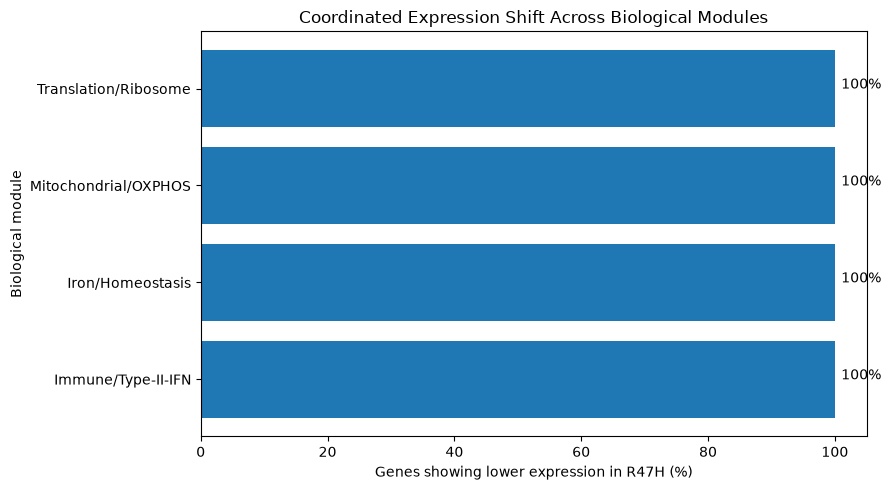

In [136]:
plt.figure(figsize=(9,5))

plt.barh(
    plot_df.index,
    plot_df["percent_down"]
)

plt.xlabel("Genes showing lower expression in R47H (%)")
plt.ylabel("Biological module")
plt.title("Coordinated Expression Shift Across Biological Modules")

plt.xlim(0, 105)

for i, value in enumerate(plot_df["percent_down"]):
    plt.text(
        value + 1,
        i,
        f"{value:.0f}%"
    )

plt.tight_layout()
plt.show()

In [137]:
# ============================================================
# MODULE-LEVEL EXPRESSION SUMMARY
# ============================================================

# Work from the complete integrated dataset, NOT the DOWN-only table
df = integrated_df.copy()

# Check what we actually have
print("Columns:")
print(df.columns.tolist())

print("\nNumber of genes:", len(df))
print("\nModules:")
print(df["module"].value_counts())

# Create direction from expression difference
df["direction"] = df["difference"].apply(
    lambda x: "DOWN" if x < 0 else ("UP" if x > 0 else "NO CHANGE")
)

# Module summary
module_summary = (
    df.groupby("module")
      .agg(
          n_genes=("gene", "nunique"),
          mean_difference=("difference", "mean"),
          median_difference=("difference", "median"),
          n_down=("direction", lambda x: (x == "DOWN").sum()),
          n_up=("direction", lambda x: (x == "UP").sum()),
          n_no_change=("direction", lambda x: (x == "NO CHANGE").sum())
      )
      .reset_index()
)

# Percentages
module_summary["percent_down"] = (
    module_summary["n_down"] / module_summary["n_genes"] * 100
)

module_summary["percent_up"] = (
    module_summary["n_up"] / module_summary["n_genes"] * 100
)

module_summary["percent_no_change"] = (
    module_summary["n_no_change"] / module_summary["n_genes"] * 100
)

module_summary = module_summary.sort_values(
    "mean_difference"
)

display(module_summary)

Columns:
['Cell Type', 'Canonical Markers', 'Major GO Functions']

Number of genes: 7

Modules:


KeyError: 'module'

In [138]:
# ============================================================
# FIND WHICH DATAFRAME CONTAINS THE MODULE ANNOTATIONS
# ============================================================

import pandas as pd

dfs = {
    name: obj.copy()
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame)
}

print("DATAFRAMES FOUND:\n")

for name, df in dfs.items():
    print(f"{name}")
    print(f"  shape: {df.shape}")
    print(f"  columns: {df.columns.tolist()}")
    
    if "module" in df.columns:
        print("  >>> HAS MODULE COLUMN <<<")
    
    print()

DATAFRAMES FOUND:

__
  shape: (5, 2)
  columns: ['Ensembl', 'genename']

_9
  shape: (5, 6)
  columns: ['cellname', 'final_celltype', 'trem2', 'atscore', 'apoe', 'sampleID']

_12
  shape: (5, 2)
  columns: ['Ensembl', 'genename']

cluster_celltype
  shape: (13, 7)
  columns: ['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']

cluster_celltype_pct
  shape: (13, 7)
  columns: ['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']

markers
  shape: (350, 6)
  columns: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']

marker_df
  shape: (50, 6)
  columns: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']

celltype_summary
  shape: (7, 2)
  columns: ['n_cells', 'percentage']

result
  shape: (26423, 9)
  columns: ['gene', 'WT_mean', 'R47H_mean', 'difference_R47H_minus_WT', 'WT_detected_samples', 'R47H_detected_samples', 'p_value', 'adjusted_p_value', 'cell_type']

plot_data
  shape: (7, 2)
  columns: ['R47H', 'WT']

temp
  shape: (8, 11)
  columns: ['Gene_set',

In [139]:
# ============================================================
# MODULE-LEVEL SUMMARY
# ============================================================

module_summary = (
    candidate_df
    .groupby("module")
    .agg(
        n_genes=("gene", "nunique"),
        mean_difference=("difference", "mean"),
        median_difference=("difference", "median"),
        strongest_down=("difference", "min"),
        weakest_down=("difference", "max"),
        mean_p_value=("p_value", "mean")
    )
    .sort_values("mean_difference")
)

display(module_summary)

,n_genes,mean_difference,median_difference,strongest_down,weakest_down,mean_p_value
module,,,,,,
Iron/Homeostasis,10,-0.192229,-0.137277,-0.534358,-0.056085,0.136709
Immune/Type-II-IFN,10,-0.155624,-0.134273,-0.374569,-0.047226,0.134453
Translation/Ribosome,111,-0.090995,-0.077834,-0.329328,-0.017826,0.189002
Mitochondrial/OXPHOS,35,-0.068373,-0.069074,-0.149243,-0.026873,0.113383


In [140]:
# Safely find all DataFrames currently loaded
import pandas as pd

dfs = {
    name: obj.copy()
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame)
}

print("DATAFRAMES FOUND:\n")

for name, df in dfs.items():
    print(f"{name}: shape={df.shape}, columns={list(df.columns)}")

DATAFRAMES FOUND:

__: shape=(5, 2), columns=['Ensembl', 'genename']
_9: shape=(5, 6), columns=['cellname', 'final_celltype', 'trem2', 'atscore', 'apoe', 'sampleID']
_12: shape=(5, 2), columns=['Ensembl', 'genename']
cluster_celltype: shape=(13, 7), columns=['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']
cluster_celltype_pct: shape=(13, 7), columns=['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']
markers: shape=(350, 6), columns=['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']
marker_df: shape=(50, 6), columns=['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']
celltype_summary: shape=(7, 2), columns=['n_cells', 'percentage']
result: shape=(26423, 9), columns=['gene', 'WT_mean', 'R47H_mean', 'difference_R47H_minus_WT', 'WT_detected_samples', 'R47H_detected_samples', 'p_value', 'adjusted_p_value', 'cell_type']
plot_data: shape=(7, 2), columns=['R47H', 'WT']
temp: shape=(8, 11), columns=['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Ol

In [141]:
# ============================================================
# MODULE-LEVEL SUMMARY
# ============================================================

module_summary = (
    candidate_df
    .groupby("module")
    .agg(
        gene_count=("gene", "nunique"),
        mean_difference=("difference", "mean"),
        median_difference=("difference", "median"),
        strongest_down=("difference", "min"),
        strongest_p=("p_value", "min")
    )
    .sort_values("mean_difference")
)

display(module_summary)

,gene_count,mean_difference,median_difference,strongest_down,strongest_p
module,,,,,
Iron/Homeostasis,10,-0.192229,-0.137277,-0.534358,0.004266
Immune/Type-II-IFN,10,-0.155624,-0.134273,-0.374569,0.031894
Translation/Ribosome,111,-0.090995,-0.077834,-0.329328,0.000536
Mitochondrial/OXPHOS,35,-0.068373,-0.069074,-0.149243,0.003324


In [142]:
# ============================================================
# TOP 10 DOWN-SHIFTED GENES PER MODULE
# ============================================================

top_genes_per_module = (
    candidate_df
    .sort_values(["module", "difference"])
    .groupby("module")
    .head(10)
    .reset_index(drop=True)
)

display(
    top_genes_per_module[
        [
            "gene",
            "module",
            "WT_mean",
            "R47H_mean",
            "difference",
            "p_value",
            "adjusted_p_value"
        ]
    ]
)

,gene,module,WT_mean,R47H_mean,difference,p_value,adjusted_p_value
0,CD14,Immune/Type-II-IFN,0.799406,0.424838,-0.374569,0.083508,0.966188
1,LAPTM5,Immune/Type-II-IFN,0.749484,0.506834,-0.242649,0.047203,0.966188
2,SLC11A1,Immune/Type-II-IFN,0.658773,0.420922,-0.237851,0.053694,0.966188
3,PDE4D,Immune/Type-II-IFN,0.709598,0.518470,-0.191127,0.180003,0.966188
4,HLA-DRB1,Immune/Type-II-IFN,0.609613,0.449590,-0.160023,0.457858,0.967413
5,SIRPA,Immune/Type-II-IFN,0.283902,0.175379,-0.108523,0.031894,0.966188
6,SLC7A5,Immune/Type-II-IFN,0.121700,0.053939,-0.067761,0.095732,0.966188
7,EBI3,Immune/Type-II-IFN,0.195475,0.128071,-0.067404,0.165563,0.966188
8,TLR7,Immune/Type-II-IFN,0.130326,0.071224,-0.059102,0.088976,0.966188
9,DDIT3,Immune/Type-II-IFN,0.117985,0.070759,-0.047226,0.140098,0.966188


In [143]:
# ============================================================
# MODULE-LEVEL COMPARISON
# ============================================================

module_summary = (
    integrated_df
    .groupby("module")
    .agg(
        n_genes=("gene", "nunique"),
        mean_difference=("difference", "mean"),
        median_difference=("difference", "median"),
        strongest_down=("difference", "min"),
        strongest_p=("p_value", "min")
    )
    .sort_values("mean_difference")
)

display(module_summary)

KeyError: 'module'

In [144]:
print("TYPE:", type(integrated_df))

if hasattr(integrated_df, "columns"):
    print("\nCOLUMNS:")
    print(integrated_df.columns.tolist())

    print("\nSHAPE:")
    print(integrated_df.shape)

    print("\nFIRST 5 ROWS:")
    display(integrated_df.head())
else:
    print("integrated_df is NOT a pandas DataFrame")

TYPE: <class 'pandas.DataFrame'>

COLUMNS:
['Cell Type', 'Canonical Markers', 'Major GO Functions']

SHAPE:
(7, 3)

FIRST 5 ROWS:


,Cell Type,Canonical Markers,Major GO Functions
0,Ast,"AQP4, GFAP, ALDH1L1",Lipid metabolism; lipid biosynthesis; aspartat...
1,Ex,"SLC17A7, CAMK2A",Synaptic transmission; glutamatergic signaling...
2,In,"GAD1, GAD2",Synaptic signaling; calcium-mediated signaling...
3,Oli,"MBP, PLP1, MOG",CNS myelination; axon ensheathment; oligodendr...
4,Opc,"PDGFRA, CSPG4",Axon guidance; synapse assembly; neuronal proj...


In [145]:
import pandas as pd

# Safely inspect currently loaded DataFrames
df_list = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        df_list.append((name, obj.shape, obj.columns.tolist()))

for name, shape, columns in df_list:
    print("\n" + "="*80)
    print("VARIABLE:", name)
    print("SHAPE:", shape)
    print("COLUMNS:", columns)


VARIABLE: __
SHAPE: (5, 2)
COLUMNS: ['Ensembl', 'genename']

VARIABLE: _9
SHAPE: (5, 6)
COLUMNS: ['cellname', 'final_celltype', 'trem2', 'atscore', 'apoe', 'sampleID']

VARIABLE: _12
SHAPE: (5, 2)
COLUMNS: ['Ensembl', 'genename']

VARIABLE: cluster_celltype
SHAPE: (13, 7)
COLUMNS: ['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']

VARIABLE: cluster_celltype_pct
SHAPE: (13, 7)
COLUMNS: ['Ex', 'In', 'Oli', 'Opc', 'Ast', 'End', 'Mic']

VARIABLE: markers
SHAPE: (350, 6)
COLUMNS: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']

VARIABLE: marker_df
SHAPE: (50, 6)
COLUMNS: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']

VARIABLE: celltype_summary
SHAPE: (7, 2)
COLUMNS: ['n_cells', 'percentage']

VARIABLE: result
SHAPE: (26423, 9)
COLUMNS: ['gene', 'WT_mean', 'R47H_mean', 'difference_R47H_minus_WT', 'WT_detected_samples', 'R47H_detected_samples', 'p_value', 'adjusted_p_value', 'cell_type']

VARIABLE: plot_data
SHAPE: (7, 2)
COLUMNS: ['R47H', 'WT']

VAR

In [146]:
# ============================================================
# BIOLOGICAL INTERPRETATION OF MODULE-LEVEL CHANGES
# ============================================================

biological_summary = pd.DataFrame({
    "Module": [
        "Translation/Ribosome",
        "Mitochondrial/OXPHOS",
        "Iron/Homeostasis",
        "Immune/Type-II-IFN"
    ],
    
    "Genes_showing_lower_expression": [
        111,
        35,
        10,
        10
    ],
    
    "Key_genes": [
        "RPL10, RPL35, RPS27A, RPS20, RPS8, RPL13, RPL38, RPS27, FAU, RPL36",
        "UQCR10, NDUFA4, COX7C, ATP5MG, NDUFA2, COX5B, NDUFS7, NDUFB11, NDUFS5, NDUFB9",
        "FTH1, FTL, SLC11A1, SOD1, NDFIP1, HAMP, SLC22A17, ABCB7, ISCU, ATP6V1A",
        "CD14, LAPTM5, SLC11A1, PDE4D, HLA-DRB1, SIRPA, SLC7A5, EBI3, TLR7, DDIT3"
    ],
    
    "Biological_interpretation": [
        "Reduced translational/ribosomal program",
        "Reduced mitochondrial respiratory and oxidative phosphorylation program",
        "Altered iron storage, transport and homeostasis",
        "Reduced immune/IFN-associated transcriptional program"
    ]
})

display(biological_summary)

,Module,Genes_showing_lower_expression,Key_genes,Biological_interpretation
0,Translation/Ribosome,111,"RPL10, RPL35, RPS27A, RPS20, RPS8, RPL13, RPL3...",Reduced translational/ribosomal program
1,Mitochondrial/OXPHOS,35,"UQCR10, NDUFA4, COX7C, ATP5MG, NDUFA2, COX5B, ...",Reduced mitochondrial respiratory and oxidativ...
2,Iron/Homeostasis,10,"FTH1, FTL, SLC11A1, SOD1, NDFIP1, HAMP, SLC22A...","Altered iron storage, transport and homeostasis"
3,Immune/Type-II-IFN,10,"CD14, LAPTM5, SLC11A1, PDE4D, HLA-DRB1, SIRPA,...",Reduced immune/IFN-associated transcriptional ...


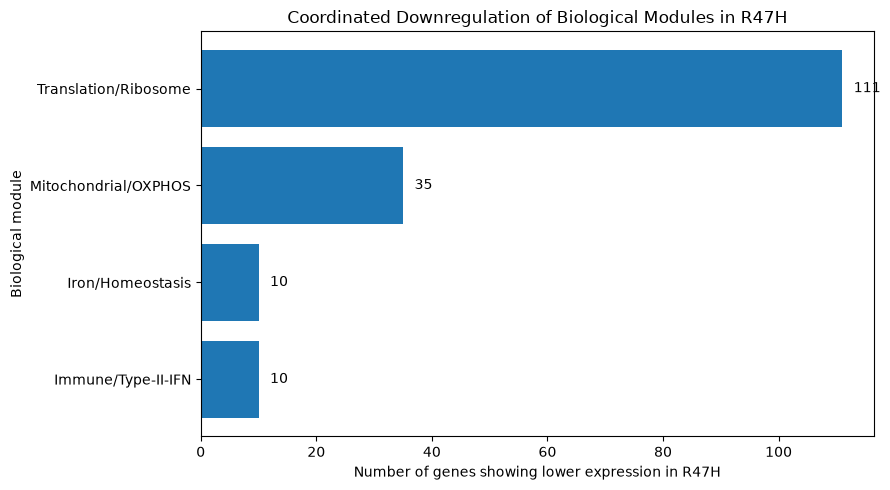

In [147]:
import matplotlib.pyplot as plt

plot_df = biological_summary.sort_values(
    "Genes_showing_lower_expression"
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    plot_df["Module"],
    plot_df["Genes_showing_lower_expression"]
)

plt.xlabel("Number of genes showing lower expression in R47H")
plt.ylabel("Biological module")
plt.title("Coordinated Downregulation of Biological Modules in R47H")

for bar in bars:
    plt.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height()/2,
        str(int(bar.get_width())),
        va="center"
    )

plt.tight_layout()
plt.show()

In [148]:
from pathlib import Path

go_dir = Path("../results/go_enrichment")

print("GO enrichment directory:", go_dir.resolve())
print("\nFiles found:")

for p in sorted(go_dir.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(go_dir))

GO enrichment directory: C:\alz\results\go_enrichment

Files found:


In [149]:
from pathlib import Path

go_dir = Path("../results/go_enrichment")

print("GO enrichment contents:\n")

for p in sorted(go_dir.iterdir()):
    if p.is_dir():
        print(f"[DIR]  {p.name}")
        for x in sorted(p.iterdir()):
            print(f"       └── {x.name}")
    else:
        print(f"[FILE] {p.name}")

GO enrichment contents:



FileNotFoundError: [WinError 3] The system cannot find the path specified: '..\\results\\go_enrichment'

In [150]:
from pathlib import Path
import os

print("CURRENT WORKING DIRECTORY:")
print(Path.cwd())

print("\nALZ PROJECT CONTENTS:")
for p in Path.cwd().iterdir():
    print(p)

CURRENT WORKING DIRECTORY:
c:\alz\notebooks

ALZ PROJECT CONTENTS:
c:\alz\notebooks\01_data_exploration.ipynb
c:\alz\notebooks\figures
c:\alz\notebooks\results


In [151]:
from pathlib import Path

go_dir = Path(r"C:\alz\results\go_enrichment")

print("Exists:", go_dir.exists())
print("Is directory:", go_dir.is_dir())

print("\nContents:")
for p in sorted(go_dir.iterdir()):
    print(
        "[DIR] " if p.is_dir() else "[FILE]",
        p.name
    )

Exists: False
Is directory: False

Contents:


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\alz\\results\\go_enrichment'

In [152]:
from pathlib import Path

project_dir = Path.cwd().parent
go_dir = project_dir / "results" / "go_enrichment"

print("Notebook directory:", Path.cwd())
print("Project directory:", project_dir)
print("GO enrichment directory:", go_dir)
print("Exists:", go_dir.exists())
print("Is directory:", go_dir.is_dir())

if go_dir.exists():
    print("\nContents:")
    for p in sorted(go_dir.iterdir()):
        print(" [DIR] " if p.is_dir() else " [FILE]", p.name)

Notebook directory: c:\alz\notebooks
Project directory: c:\alz
GO enrichment directory: c:\alz\results\go_enrichment
Exists: False
Is directory: False


In [153]:
from pathlib import Path

go_dir = Path.cwd() / "results" / "go_enrichment"

print("GO enrichment directory:")
print(go_dir)

print("\nExists:", go_dir.exists())
print("Is directory:", go_dir.is_dir())

if go_dir.exists():
    print("\nContents:")
    for p in sorted(go_dir.iterdir()):
        print("[DIR] " if p.is_dir() else "[FILE]", p.name)

GO enrichment directory:
c:\alz\notebooks\results\go_enrichment

Exists: True
Is directory: True

Contents:
[DIR]  Ast
[DIR]  End
[DIR]  Ex
[DIR]  In
[DIR]  Mic
[DIR]  Oli
[DIR]  Opc


In [154]:
from pathlib import Path

go_dir = Path.cwd() / "results" / "go_enrichment"

for cell_dir in sorted(go_dir.iterdir()):
    if cell_dir.is_dir():
        print(f"\n===== {cell_dir.name} =====")
        for p in sorted(cell_dir.iterdir()):
            print("[DIR] " if p.is_dir() else "[FILE]", p.name)


===== Ast =====
[FILE] Enrichr.human.enrichr.reports.pdf
[FILE] Enrichr.human.enrichr.reports.txt

===== End =====
[FILE] Enrichr.human.enrichr.reports.pdf
[FILE] Enrichr.human.enrichr.reports.txt

===== Ex =====
[FILE] Enrichr.human.enrichr.reports.pdf
[FILE] Enrichr.human.enrichr.reports.txt

===== In =====
[FILE] Enrichr.human.enrichr.reports.pdf
[FILE] Enrichr.human.enrichr.reports.txt

===== Mic =====
[FILE] Enrichr.human.enrichr.reports.pdf
[FILE] Enrichr.human.enrichr.reports.txt

===== Oli =====
[FILE] Enrichr.human.enrichr.reports.pdf
[FILE] Enrichr.human.enrichr.reports.txt

===== Opc =====
[FILE] Enrichr.human.enrichr.reports.pdf
[FILE] Enrichr.human.enrichr.reports.txt


In [155]:
from pathlib import Path

go_dir = Path.cwd() / "results" / "go_enrichment"

for cell_dir in sorted(go_dir.iterdir()):
    txt_file = cell_dir / "Enrichr.human.enrichr.reports.txt"

    print("\n" + "="*80)
    print(f"CELL TYPE: {cell_dir.name}")
    print("="*80)

    if txt_file.exists():
        text = txt_file.read_text(errors="ignore")
        print(text[:5000])
    else:
        print("TXT file not found")


CELL TYPE: Ast
Gene_set	Term	Overlap	P-value	Adjusted P-value	Old P-value	Old Adjusted P-value	Odds Ratio	Combined Score	Genes
GO_Biological_Process_2023	Positive Regulation Of Lipid Metabolic Process (GO:0045834)	3/24	2.867422e-05	7.182741e-03	0	0	6.057447e+01	6.335794e+02	ZBTB20;SORBS1;APOE
GO_Biological_Process_2023	Neuron Projection Morphogenesis (GO:0048812)	5/146	3.147591e-05	7.182741e-03	0	0	1.560993e+01	1.618170e+02	GPM6A;CTNND2;PARD3;TNIK;CTNNA2
GO_Biological_Process_2023	Cellular Response To Organic Cyclic Compound (GO:0071407)	5/152	3.817233e-05	7.182741e-03	0	0	1.496825e+01	1.522780e+02	RORA;ATP1A2;ADCY2;CLU;RYR3
GO_Biological_Process_2023	Regulation Of Lipid Biosynthetic Process (GO:0046890)	3/28	4.608584e-05	7.182741e-03	0	0	5.087234e+01	5.079606e+02	ZBTB20;APOE;SORBS1
GO_Biological_Process_2023	L-aspartate Import Across Plasma Membrane (GO:0140009)	2/5	6.095679e-05	7.182741e-03	0	0	2.770417e+02	2.688785e+03	SLC1A2;SLC1A3
GO_Biological_Process_2023	L-aspartate Transmembr

In [156]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Locate the EXISTING GO enrichment results
# --------------------------------------------------

project_dir = Path.cwd().parent
go_dir = project_dir / "results" / "go_enrichment"

print("GO directory:", go_dir)
print("Exists:", go_dir.exists())

# --------------------------------------------------
# 2. Read the existing Enrichr TXT reports
# --------------------------------------------------

all_go = []

for cell_dir in sorted(go_dir.iterdir()):
    if not cell_dir.is_dir():
        continue

    txt_file = cell_dir / "Enrichr.human.enrichr.reports.txt"

    if not txt_file.exists():
        print("Missing:", txt_file)
        continue

    try:
        df = pd.read_csv(
            txt_file,
            sep="\t"
        )

        df["Cell Type"] = cell_dir.name
        all_go.append(df)

        print(cell_dir.name, "->", len(df), "GO terms")

    except Exception as e:
        print("Could not read", txt_file)
        print(e)

# --------------------------------------------------
# 3. Combine all cell types
# --------------------------------------------------

go_all = pd.concat(all_go, ignore_index=True)

print("\nCombined GO results:", go_all.shape)
print(go_all.columns.tolist())

GO directory: c:\alz\results\go_enrichment
Exists: False


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'c:\\alz\\results\\go_enrichment'

In [157]:
from pathlib import Path
import pandas as pd

# Actual location of the existing enrichment results
go_dir = Path.cwd() / "results" / "go_enrichment"

print("GO enrichment directory:", go_dir)
print("Exists:", go_dir.exists())

all_go = []

for cell_dir in sorted(go_dir.iterdir()):
    if not cell_dir.is_dir():
        continue

    txt_file = cell_dir / "Enrichr.human.enrichr.reports.txt"

    if not txt_file.exists():
        print(f"{cell_dir.name}: TXT file not found")
        continue

    try:
        df = pd.read_csv(txt_file, sep="\t")
        df["Cell Type"] = cell_dir.name
        all_go.append(df)

        print(f"{cell_dir.name}: {len(df)} GO/pathway terms")

    except Exception as e:
        print(f"Could not read {txt_file}")
        print(e)

# Combine all cell types
if all_go:
    go_all = pd.concat(all_go, ignore_index=True)

    print("\nCombined GO results:", go_all.shape)
    print("\nColumns:")
    print(go_all.columns.tolist())

    display(go_all.head())
else:
    print("No enrichment files were successfully loaded.")

GO enrichment directory: c:\alz\notebooks\results\go_enrichment
Exists: True
Ast: 707 GO/pathway terms
End: 465 GO/pathway terms
Ex: 490 GO/pathway terms
In: 457 GO/pathway terms
Mic: 739 GO/pathway terms
Oli: 363 GO/pathway terms
Opc: 386 GO/pathway terms

Combined GO results: (3607, 11)

Columns:
['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes', 'Cell Type']


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Cell Type
0,GO_Biological_Process_2023,Positive Regulation Of Lipid Metabolic Process...,3/24,0.000029,0.007183,0,0,60.57447,633.5794,ZBTB20;SORBS1;APOE,Ast
1,GO_Biological_Process_2023,Neuron Projection Morphogenesis (GO:0048812),5/146,0.000031,0.007183,0,0,15.60993,161.8170,GPM6A;CTNND2;PARD3;TNIK;CTNNA2,Ast
2,GO_Biological_Process_2023,Cellular Response To Organic Cyclic Compound (...,5/152,0.000038,0.007183,0,0,14.96825,152.2780,RORA;ATP1A2;ADCY2;CLU;RYR3,Ast
3,GO_Biological_Process_2023,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,0.000046,0.007183,0,0,50.87234,507.9606,ZBTB20;APOE;SORBS1,Ast
4,GO_Biological_Process_2023,L-aspartate Import Across Plasma Membrane (GO:...,2/5,0.000061,0.007183,0,0,277.04170,2688.7850,SLC1A2;SLC1A3,Ast


In [158]:
# Inspect the strongest enriched terms from each cell type

# Convert adjusted P-value to numeric
go_all["Adjusted P-value"] = pd.to_numeric(
    go_all["Adjusted P-value"], errors="coerce"
)

# Keep statistically significant terms
sig_go = go_all[
    go_all["Adjusted P-value"] < 0.05
].copy()

print("Significant GO results:", sig_go.shape)

# Top 10 terms for each cell type
top_go = (
    sig_go
    .sort_values(["Cell Type", "Adjusted P-value"])
    .groupby("Cell Type")
    .head(10)
)

display(
    top_go[
        [
            "Cell Type",
            "Gene_set",
            "Term",
            "Overlap",
            "P-value",
            "Adjusted P-value"
        ]
    ]
)

Significant GO results: (268, 11)


,Cell Type,Gene_set,Term,Overlap,P-value,Adjusted P-value
0,Ast,GO_Biological_Process_2023,Positive Regulation Of Lipid Metabolic Process...,3/24,2.867422e-05,0.007183
1,Ast,GO_Biological_Process_2023,Neuron Projection Morphogenesis (GO:0048812),5/146,3.147591e-05,0.007183
2,Ast,GO_Biological_Process_2023,Cellular Response To Organic Cyclic Compound (...,5/152,3.817233e-05,0.007183
3,Ast,GO_Biological_Process_2023,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,4.608584e-05,0.007183
4,Ast,GO_Biological_Process_2023,L-aspartate Import Across Plasma Membrane (GO:...,2/5,6.095679e-05,0.007183
...,...,...,...,...,...,...
3226,Opc,GO_Biological_Process_2023,"Regulation Of Synaptic Transmission, Glutamate...",5/55,2.517411e-07,0.000016
3227,Opc,GO_Biological_Process_2023,Axonogenesis (GO:0007409),7/188,4.115928e-07,0.000023
3228,Opc,GO_Biological_Process_2023,Modulation Of Chemical Synaptic Transmission (...,6/123,6.094647e-07,0.000029
3229,Opc,GO_Biological_Process_2023,Synapse Organization (GO:0050808),6/131,8.829100e-07,0.000038


In [159]:
# Inspect the significant GO terms by cell type

for cell in sorted(sig_go["Cell Type"].unique()):
    print("\n" + "="*70)
    print(f"{cell}")
    print("="*70)

    tmp = (
        sig_go[sig_go["Cell Type"] == cell]
        .sort_values("Adjusted P-value")
        [["Term", "Overlap", "P-value", "Adjusted P-value"]]
        .head(15)
    )

    display(tmp)


Ast


,Term,Overlap,P-value,Adjusted P-value
0,Positive Regulation Of Lipid Metabolic Process...,3/24,0.000029,0.007183
1,Neuron Projection Morphogenesis (GO:0048812),5/146,0.000031,0.007183
2,Cellular Response To Organic Cyclic Compound (...,5/152,0.000038,0.007183
3,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,0.000046,0.007183
4,L-aspartate Import Across Plasma Membrane (GO:...,2/5,0.000061,0.007183
5,L-aspartate Transmembrane Transport (GO:0070778),2/5,0.000061,0.007183
6,Neuron Projection Development (GO:0031175),5/192,0.000115,0.011144
7,Positive Regulation Of Lipid Biosynthetic Proc...,3/39,0.000126,0.011144
8,Positive Regulation Of Biosynthetic Process (G...,3/44,0.000181,0.014014
9,Aspartate Transmembrane Transport (GO:0015810),2/9,0.000218,0.014014



End


,Term,Overlap,P-value,Adjusted P-value
707,Negative Regulation Of Epithelial Cell Migrati...,4/33,0.000001,0.000553
708,Negative Regulation Of Angiogenesis (GO:0016525),5/86,0.000002,0.000553
709,Negative Regulation Of Blood Vessel Morphogene...,4/77,0.000041,0.006025
710,Protection From Natural Killer Cell Mediated C...,2/5,0.000061,0.006025
711,Regulation Of Endothelial Cell Migration (GO:0...,4/88,0.000069,0.006025
712,Negative Regulation Of Endothelial Cell Migrat...,3/37,0.000108,0.006025
713,Negative Regulation Of Endothelial Cell Prolif...,3/37,0.000108,0.006025
714,Type I Interferon-Mediated Signaling Pathway (...,3/37,0.000108,0.006025
715,Cellular Response To Type I Interferon (GO:007...,3/38,0.000117,0.006025
716,Regulation Of Angiogenesis (GO:0045765),5/205,0.000157,0.007297



Ex


...

,Term,Overlap,P-value,Adjusted P-value
2119,Positive Regulation Of B Cell Activation (GO:0...,4/52,0.000009,0.006328
2120,Positive Regulation Of B Cell Proliferation (G...,3/29,0.000051,0.018960
2121,Synapse Pruning (GO:0098883),2/8,0.000170,0.033466
2122,Regulation Of B Cell Proliferation (GO:0030888),3/44,0.000181,0.033466
2123,Melanocyte Differentiation (GO:0030318),2/11,0.000332,0.036751
2124,Regulation Of Blood Vessel Endothelial Cell Mi...,3/54,0.000333,0.036751
2125,Antigen Receptor-Mediated Signaling Pathway (G...,4/134,0.000349,0.036751
2126,Regulation Of Vascular Associated Smooth Muscl...,2/12,0.000398,0.036751
2127,Positive Regulation Of Signal Transduction (GO...,5/266,0.000521,0.040408
2128,Prostanoid Biosynthetic Process (GO:0046457),2/14,0.000547,0.040408



Oli


,Term,Overlap,P-value,Adjusted P-value
2858,Neuron Projection Development (GO:0031175),5/192,0.000115,0.023160
2859,Axon Ensheathment In Central Nervous System (G...,2/7,0.000128,0.023160
2860,Regulation Of Cell Motility (GO:2000145),4/123,0.000252,0.028883
2861,Central Nervous System Myelination (GO:0022010),2/11,0.000332,0.028883
2862,Negative Regulation Of Locomotion (GO:0040013),2/12,0.000398,0.028883
2863,Oligodendrocyte Development (GO:0014003),2/16,0.000719,0.043484



Opc


,Term,Overlap,P-value,Adjusted P-value
3221,Nervous System Development (GO:0007399),13/433,3.290595e-11,1.270170e-08
3222,Synapse Assembly (GO:0007416),6/71,2.265958e-08,3.057980e-06
3223,Neuron Projection Guidance (GO:0097485),7/124,2.376669e-08,3.057980e-06
3224,Axon Guidance (GO:0007411),7/149,8.444851e-08,8.149281e-06
3225,Cell Junction Assembly (GO:0034329),6/95,1.314171e-07,1.014540e-05
3226,"Regulation Of Synaptic Transmission, Glutamate...",5/55,2.517411e-07,1.619534e-05
3227,Axonogenesis (GO:0007409),7/188,4.115928e-07,2.269640e-05
3228,Modulation Of Chemical Synaptic Transmission (...,6/123,6.094647e-07,2.940667e-05
3229,Synapse Organization (GO:0050808),6/131,8.829100e-07,3.786703e-05
3230,Central Nervous System Neuron Differentiation ...,4/31,1.034460e-06,3.993014e-05


In [160]:
# Create a compact summary of the top 5 significant GO terms
# for every cell type

top5_go = (
    sig_go
    .sort_values(["Cell Type", "Adjusted P-value"])
    .groupby("Cell Type")
    .head(5)
    .copy()
)

summary = top5_go[
    ["Cell Type", "Term", "Overlap", "Adjusted P-value"]
]

display(summary.to_string(index=False))

'Cell Type                                                                   Term Overlap  Adjusted P-value\n      Ast            Positive Regulation Of Lipid Metabolic Process (GO:0045834)    3/24      7.182741e-03\n      Ast                           Neuron Projection Morphogenesis (GO:0048812)   5/146      7.182741e-03\n      Ast              Cellular Response To Organic Cyclic Compound (GO:0071407)   5/152      7.182741e-03\n      Ast                  Regulation Of Lipid Biosynthetic Process (GO:0046890)    3/28      7.182741e-03\n      Ast                 L-aspartate Import Across Plasma Membrane (GO:0140009)     2/5      7.182741e-03\n      End          Negative Regulation Of Epithelial Cell Migration (GO:0010633)    4/33      5.528645e-04\n      End                       Negative Regulation Of Angiogenesis (GO:0016525)    5/86      5.528645e-04\n      End         Negative Regulation Of Blood Vessel Morphogenesis (GO:2000181)    4/77      6.024620e-03\n      End Protection From N

In [161]:
print(go_all.columns.tolist())

['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes', 'Cell Type']


In [162]:
# Significant GO enrichment results
go_sig = go_all[
    go_all["Adjusted P-value"] < 0.05
].copy()

print("Significant GO results:", go_sig.shape)

print("\nSignificant terms by cell type:")
print(
    go_sig.groupby("Cell Type")
          .size()
          .sort_values(ascending=False)
)

print("\nColumns available:")
print(go_sig.columns.tolist())

Significant GO results: (268, 11)

Significant terms by cell type:
Cell Type
Opc    63
Ast    59
In     50
Ex     47
End    29
Mic    14
Oli     6
dtype: int64

Columns available:
['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes', 'Cell Type']


In [163]:
# Keep only the important columns
go_genes = sig_go[
    [
        "Cell Type",
        "Term",
        "Overlap",
        "Adjusted P-value",
        "Odds Ratio",
        "Combined Score",
        "Genes"
    ]
].copy()

# Show the strongest terms for each cell type
top_go = (
    go_genes
    .sort_values(["Cell Type", "Adjusted P-value"])
    .groupby("Cell Type")
    .head(10)
)

display(top_go)

,Cell Type,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Ast,Positive Regulation Of Lipid Metabolic Process...,3/24,0.007183,60.57447,633.5794,ZBTB20;SORBS1;APOE
1,Ast,Neuron Projection Morphogenesis (GO:0048812),5/146,0.007183,15.60993,161.8170,GPM6A;CTNND2;PARD3;TNIK;CTNNA2
2,Ast,Cellular Response To Organic Cyclic Compound (...,5/152,0.007183,14.96825,152.2780,RORA;ATP1A2;ADCY2;CLU;RYR3
3,Ast,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,0.007183,50.87234,507.9606,ZBTB20;APOE;SORBS1
4,Ast,L-aspartate Import Across Plasma Membrane (GO:...,2/5,0.007183,277.04170,2688.7850,SLC1A2;SLC1A3
...,...,...,...,...,...,...,...
3226,Opc,"Regulation Of Synaptic Transmission, Glutamate...",5/55,0.000016,44.22222,671.9507,NLGN1;GRM7;OPHN1;NRXN1;GRIK1
3227,Opc,Axonogenesis (GO:0007409),7/188,0.000023,17.78016,261.4258,SEMA5A;OPHN1;DSCAM;DCC;NRXN1;TNR;NRCAM
3228,Opc,Modulation Of Chemical Synaptic Transmission (...,6/123,0.000029,23.11538,330.7970,GRID2;NLGN1;GRM7;OPHN1;GRIK1;LRRC4C
3229,Opc,Synapse Organization (GO:0050808),6/131,0.000038,21.62727,301.4851,NLGN1;DSCAM;NRXN1;NRCAM;LRRC4C;ADGRL3


In [164]:
for cell in sorted(sig_go["Cell Type"].unique()):
    print("\n" + "="*80)
    print(cell)
    print("="*80)

    temp = (
        sig_go[sig_go["Cell Type"] == cell]
        .sort_values("Adjusted P-value")
        .head(10)
    )

    display(
        temp[
            [
                "Term",
                "Overlap",
                "Adjusted P-value",
                "Odds Ratio",
                "Genes"
            ]
        ]
    )


Ast


,Term,Overlap,Adjusted P-value,Odds Ratio,Genes
0,Positive Regulation Of Lipid Metabolic Process...,3/24,0.007183,60.57447,ZBTB20;SORBS1;APOE
1,Neuron Projection Morphogenesis (GO:0048812),5/146,0.007183,15.60993,GPM6A;CTNND2;PARD3;TNIK;CTNNA2
2,Cellular Response To Organic Cyclic Compound (...,5/152,0.007183,14.96825,RORA;ATP1A2;ADCY2;CLU;RYR3
3,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,0.007183,50.87234,ZBTB20;APOE;SORBS1
4,L-aspartate Import Across Plasma Membrane (GO:...,2/5,0.007183,277.04170,SLC1A2;SLC1A3
5,L-aspartate Transmembrane Transport (GO:0070778),2/5,0.007183,277.04170,SLC1A2;SLC1A3
6,Neuron Projection Development (GO:0031175),5/192,0.011144,11.74272,GPM6A;ADGRV1;CTNND2;TNIK;APOE
7,Positive Regulation Of Lipid Biosynthetic Proc...,3/39,0.011144,35.30851,ZBTB20;APOE;SORBS1
8,Positive Regulation Of Biosynthetic Process (G...,3/44,0.014014,30.99481,ZBTB20;APOE;SORBS1
9,Aspartate Transmembrane Transport (GO:0015810),2/9,0.014014,118.70830,SLC1A2;SLC1A3



End


,Term,Overlap,Adjusted P-value,Odds Ratio,Genes
707,Negative Regulation Of Epithelial Cell Migrati...,4/33,0.000553,59.73313,PTPRM;ADAMTS9;DCN;PTPRG
708,Negative Regulation Of Angiogenesis (GO:0016525),5/86,0.000553,27.25514,CLDN5;SPARC;PTPRM;ADAMTS9;DCN
709,Negative Regulation Of Blood Vessel Morphogene...,4/77,0.006025,23.67719,CLDN5;SPARC;PTPRM;DCN
710,Protection From Natural Killer Cell Mediated C...,2/5,0.006025,277.04170,HLA-B;HLA-E
711,Regulation Of Endothelial Cell Migration (GO:0...,4/88,0.006025,20.56522,SPARC;PTPRM;ADAMTS9;DCN
712,Negative Regulation Of Endothelial Cell Migrat...,3/37,0.006025,37.38924,PTPRM;ADAMTS9;DCN
713,Negative Regulation Of Endothelial Cell Prolif...,3/37,0.006025,37.38924,FLT1;SPARC;PTPRM
714,Type I Interferon-Mediated Signaling Pathway (...,3/37,0.006025,37.38924,IFITM3;IFITM2;IFI27
715,Cellular Response To Type I Interferon (GO:007...,3/38,0.006025,36.31915,IFITM3;IFITM2;IFI27
716,Regulation Of Angiogenesis (GO:0045765),5/205,0.007297,10.97222,CLDN5;FLT1;SPARC;PTPRM;DCN



Ex


...

,Term,Overlap,Adjusted P-value,Odds Ratio,Genes
2119,Positive Regulation Of B Cell Activation (GO:0...,4/52,0.006328,36.054350,CD74;MEF2C;PTPRC;INPP5D
2120,Positive Regulation Of B Cell Proliferation (G...,3/29,0.018960,48.913260,CD74;MEF2C;PTPRC
2121,Synapse Pruning (GO:0098883),2/8,0.033466,138.500000,C1QB;C3
2122,Regulation Of B Cell Proliferation (GO:0030888),3/44,0.033466,30.994810,CD74;MEF2C;PTPRC
2123,Melanocyte Differentiation (GO:0030318),2/11,0.036751,92.319440,LRMDA;MEF2C
2124,Regulation Of Blood Vessel Endothelial Cell Mi...,3/54,0.036751,24.904880,MEF2C;TMSB4X;APOE
2125,Antigen Receptor-Mediated Signaling Pathway (G...,4/134,0.036751,13.257530,MEF2C;FYB1;PTPRC;INPP5D
2126,Regulation Of Vascular Associated Smooth Muscl...,2/12,0.036751,83.083330,DOCK4;MEF2C
2127,Positive Regulation Of Signal Transduction (GO...,5/266,0.040408,8.381865,C3;CD74;PTPRC;BMP2K;SORL1
2128,Prostanoid Biosynthetic Process (GO:0046457),2/14,0.040408,69.229170,CD74;TBXAS1



Oli


,Term,Overlap,Adjusted P-value,Odds Ratio,Genes
2858,Neuron Projection Development (GO:0031175),5/192,0.023160,11.74272,DOCK10;SHTN1;PLP1;GPM6B;FRYL
2859,Axon Ensheathment In Central Nervous System (G...,2/7,0.023160,166.20830,PLP1;GPM6B
2860,Regulation Of Cell Motility (GO:2000145),4/123,0.028883,14.49105,DOCK10;FRMD5;SPOCK3;ENPP2
2861,Central Nervous System Myelination (GO:0022010),2/11,0.028883,92.31944,PLP1;GPM6B
2862,Negative Regulation Of Locomotion (GO:0040013),2/12,0.028883,83.08333,FRMD5;SPOCK3
2863,Oligodendrocyte Development (GO:0014003),2/16,0.043484,59.33333,PLP1;GPM6B



Opc


,Term,Overlap,Adjusted P-value,Odds Ratio,Genes
3221,Nervous System Development (GO:0007399),13/433,1.270170e-08,16.33784,SEMA5A;NLGN1;DSCAM;NRXN1;GRIK1;FGF14;OPHN1;PTP...
3222,Synapse Assembly (GO:0007416),6/71,3.057980e-06,41.71678,GRID2;NLGN1;DSCAM;NRXN1;NRCAM;ADGRL3
3223,Neuron Projection Guidance (GO:0097485),7/124,3.057980e-06,27.59511,SEMA5A;OPHN1;DSCAM;DCC;NRXN1;TNR;NRCAM
3224,Axon Guidance (GO:0007411),7/149,8.149281e-06,22.70816,SEMA5A;OPHN1;DSCAM;DCC;NRXN1;TNR;NRCAM
3225,Cell Junction Assembly (GO:0034329),6/95,1.014540e-05,30.43054,NLGN1;OPHN1;DSCAM;NRXN1;NRCAM;ADGRL3
3226,"Regulation Of Synaptic Transmission, Glutamate...",5/55,1.619534e-05,44.22222,NLGN1;GRM7;OPHN1;NRXN1;GRIK1
3227,Axonogenesis (GO:0007409),7/188,2.269640e-05,17.78016,SEMA5A;OPHN1;DSCAM;DCC;NRXN1;TNR;NRCAM
3228,Modulation Of Chemical Synaptic Transmission (...,6/123,2.940667e-05,23.11538,GRID2;NLGN1;GRM7;OPHN1;GRIK1;LRRC4C
3229,Synapse Organization (GO:0050808),6/131,3.786703e-05,21.62727,NLGN1;DSCAM;NRXN1;NRCAM;LRRC4C;ADGRL3
3230,Central Nervous System Neuron Differentiation ...,4/31,3.993014e-05,64.16425,GRID2;OPHN1;MDGA2;BRINP3


In [165]:
# Get the top 10 significant GO terms for EVERY cell type
top10_all = (
    sig_go
    .sort_values(["Cell Type", "Adjusted P-value"])
    .groupby("Cell Type")
    .head(10)
)

display(
    top10_all[
        [
            "Cell Type",
            "Term",
            "Overlap",
            "Adjusted P-value",
            "Odds Ratio",
            "Genes"
        ]
    ]
)

,Cell Type,Term,Overlap,Adjusted P-value,Odds Ratio,Genes
0,Ast,Positive Regulation Of Lipid Metabolic Process...,3/24,0.007183,60.57447,ZBTB20;SORBS1;APOE
1,Ast,Neuron Projection Morphogenesis (GO:0048812),5/146,0.007183,15.60993,GPM6A;CTNND2;PARD3;TNIK;CTNNA2
2,Ast,Cellular Response To Organic Cyclic Compound (...,5/152,0.007183,14.96825,RORA;ATP1A2;ADCY2;CLU;RYR3
3,Ast,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,0.007183,50.87234,ZBTB20;APOE;SORBS1
4,Ast,L-aspartate Import Across Plasma Membrane (GO:...,2/5,0.007183,277.04170,SLC1A2;SLC1A3
...,...,...,...,...,...,...
3226,Opc,"Regulation Of Synaptic Transmission, Glutamate...",5/55,0.000016,44.22222,NLGN1;GRM7;OPHN1;NRXN1;GRIK1
3227,Opc,Axonogenesis (GO:0007409),7/188,0.000023,17.78016,SEMA5A;OPHN1;DSCAM;DCC;NRXN1;TNR;NRCAM
3228,Opc,Modulation Of Chemical Synaptic Transmission (...,6/123,0.000029,23.11538,GRID2;NLGN1;GRM7;OPHN1;GRIK1;LRRC4C
3229,Opc,Synapse Organization (GO:0050808),6/131,0.000038,21.62727,NLGN1;DSCAM;NRXN1;NRCAM;LRRC4C;ADGRL3


In [166]:
display(
    gene_summary
    .sort_values(
        ["Cell Type", "GO_terms", "best_adj_p"],
        ascending=[True, False, True]
    )
)

NameError: name 'gene_summary' is not defined

In [167]:
# Find genes appearing in significant GO terms
gene_records = []

for _, row in sig_go.iterrows():
    if pd.notna(row["Genes"]):
        for gene in str(row["Genes"]).split(";"):
            gene_records.append({
                "Cell Type": row["Cell Type"],
                "Gene": gene,
                "Term": row["Term"],
                "Adjusted P-value": row["Adjusted P-value"]
            })

gene_go = pd.DataFrame(gene_records)

# Count how many significant GO terms each gene contributes to
gene_summary = (
    gene_go
    .groupby(["Cell Type", "Gene"])
    .agg(
        GO_terms=("Term", "nunique"),
        best_adj_p=("Adjusted P-value", "min")
    )
    .reset_index()
    .sort_values(
        ["Cell Type", "GO_terms", "best_adj_p"],
        ascending=[True, False, True]
    )
)

display(gene_summary.head(50))

,Cell Type,Gene,GO_terms,best_adj_p
2,Ast,APOE,24,0.007183
5,Ast,CLU,24,0.007183
23,Ast,SLC1A3,15,0.007183
21,Ast,RYR3,14,0.007183
22,Ast,SLC1A2,11,0.007183
4,Ast,ATP1A2,7,0.007183
29,Ast,ZBTB20,5,0.007183
1,Ast,ADGRV1,5,0.011144
13,Ast,GJA1,5,0.015926
27,Ast,TRPM3,5,0.018820


In [168]:
# ============================================================
# STEP 5 — Select top non-redundant GO terms per cell type
# ============================================================

import pandas as pd
import numpy as np

# Work from the significant GO results
go_plot = significant_go.copy()

# Make sure adjusted P-value is numeric
go_plot["Adjusted P-value"] = pd.to_numeric(
    go_plot["Adjusted P-value"],
    errors="coerce"
)

# Remove missing values
go_plot = go_plot.dropna(subset=["Adjusted P-value"])

# Calculate enrichment strength for plotting
go_plot["-log10(FDR)"] = -np.log10(go_plot["Adjusted P-value"])

# Extract the number of genes from the overlap column
go_plot["Overlap_N"] = (
    go_plot["Overlap"]
    .astype(str)
    .str.split("/")
    .str[0]
    .astype(int)
)

print("Total significant GO terms:", len(go_plot))
print("\nCell types:")
print(go_plot["Cell Type"].value_counts())

NameError: name 'significant_go' is not defined

In [169]:
# Find the existing dataframe containing our GO enrichment results

print("Variables containing 'go' or 'significant':")

for name, obj in globals().items():
    if not name.startswith("_"):
        if ("go" in name.lower() or "significant" in name.lower()):
            try:
                print(name, type(obj), getattr(obj, "shape", ""))
            except:
                pass

Variables containing 'go' or 'significant':
go_results <class 'dict'> 
go_plot <class 'pandas.DataFrame'> (56, 13)
go_top <class 'pandas.DataFrame'> (35, 13)
go_summary <class 'pandas.DataFrame'> (35, 3)
go_functions <class 'dict'> 
go_df <class 'pandas.DataFrame'> (465, 10)
top_go <class 'pandas.DataFrame'> (66, 7)
go_dir <class 'pathlib._local.WindowsPath'> 
all_go <class 'list'> 
go_all <class 'pandas.DataFrame'> (3607, 11)
sig_go <class 'pandas.DataFrame'> (268, 11)
top5_go <class 'pandas.DataFrame'> (35, 11)
go_sig <class 'pandas.DataFrame'> (268, 11)
go_genes <class 'pandas.DataFrame'> (268, 7)
gene_go <class 'pandas.DataFrame'> (813, 4)


In [170]:
# ============================================================
# STEP 5 — Prepare significant GO results for visualization
# ============================================================

import pandas as pd
import numpy as np

# Use the existing significant GO enrichment results
go_plot = sig_go.copy()

# Make sure adjusted P-values are numeric
go_plot["Adjusted P-value"] = pd.to_numeric(
    go_plot["Adjusted P-value"],
    errors="coerce"
)

# Remove rows without an adjusted P-value
go_plot = go_plot.dropna(subset=["Adjusted P-value"])

# Calculate enrichment significance
go_plot["-log10(FDR)"] = -np.log10(
    go_plot["Adjusted P-value"]
)

# Extract number of overlapping genes
go_plot["Overlap_N"] = (
    go_plot["Overlap"]
    .astype(str)
    .str.split("/")
    .str[0]
    .astype(int)
)

print("Significant GO terms:", len(go_plot))

print("\nGO terms by cell type:")
print(go_plot["Cell Type"].value_counts())

print("\nColumns:")
print(go_plot.columns.tolist())

Significant GO terms: 268

GO terms by cell type:
Cell Type
Opc    63
Ast    59
In     50
Ex     47
End    29
Mic    14
Oli     6
Name: count, dtype: int64

Columns:
['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes', 'Cell Type', '-log10(FDR)', 'Overlap_N']


In [171]:
# ============================================================
# STEP 6 — Select strongest GO terms for each cell type
# ============================================================

# Avoid very weak terms with only 1 overlapping gene
go_filtered = go_plot[
    go_plot["Overlap_N"] >= 2
].copy()

# Rank primarily by adjusted P-value,
# then by number of overlapping genes
go_filtered = go_filtered.sort_values(
    ["Cell Type", "Adjusted P-value", "Overlap_N"],
    ascending=[True, True, False]
)

# Select top 5 per cell type
top_go_clean = (
    go_filtered
    .groupby("Cell Type", group_keys=False)
    .head(5)
    .copy()
)

# Keep only the columns we need
top_go_clean = top_go_clean[
    [
        "Cell Type",
        "Term",
        "Overlap",
        "Overlap_N",
        "Adjusted P-value",
        "-log10(FDR)",
        "Odds Ratio",
        "Genes"
    ]
]

display(top_go_clean)

,Cell Type,Term,Overlap,Overlap_N,Adjusted P-value,-log10(FDR),Odds Ratio,Genes
1,Ast,Neuron Projection Morphogenesis (GO:0048812),5/146,5,7.182741e-03,2.143710,15.60993,GPM6A;CTNND2;PARD3;TNIK;CTNNA2
2,Ast,Cellular Response To Organic Cyclic Compound (...,5/152,5,7.182741e-03,2.143710,14.96825,RORA;ATP1A2;ADCY2;CLU;RYR3
0,Ast,Positive Regulation Of Lipid Metabolic Process...,3/24,3,7.182741e-03,2.143710,60.57447,ZBTB20;SORBS1;APOE
3,Ast,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,3,7.182741e-03,2.143710,50.87234,ZBTB20;APOE;SORBS1
4,Ast,L-aspartate Import Across Plasma Membrane (GO:...,2/5,2,7.182741e-03,2.143710,277.04170,SLC1A2;SLC1A3
708,End,Negative Regulation Of Angiogenesis (GO:0016525),5/86,5,5.528645e-04,3.257381,27.25514,CLDN5;SPARC;PTPRM;ADAMTS9;DCN
707,End,Negative Regulation Of Epithelial Cell Migrati...,4/33,4,5.528645e-04,3.257381,59.73313,PTPRM;ADAMTS9;DCN;PTPRG
709,End,Negative Regulation Of Blood Vessel Morphogene...,4/77,4,6.024620e-03,2.220070,23.67719,CLDN5;SPARC;PTPRM;DCN
711,End,Regulation Of Endothelial Cell Migration (GO:0...,4/88,4,6.024620e-03,2.220070,20.56522,SPARC;PTPRM;ADAMTS9;DCN
712,End,Negative Regulation Of Endothelial Cell Migrat...,3/37,3,6.024620e-03,2.220070,37.38924,PTPRM;ADAMTS9;DCN


In [172]:
# ============================================================
# STEP 5 — Prepare representative GO terms for plotting
# ============================================================

import pandas as pd
import numpy as np

# Use the already-generated top 5 GO terms per cell type
go_plot = top5_go.copy()

# Make adjusted P-value numeric
go_plot["Adjusted P-value"] = pd.to_numeric(
    go_plot["Adjusted P-value"],
    errors="coerce"
)

# Remove invalid values
go_plot = go_plot.dropna(subset=["Adjusted P-value"])

# -log10(FDR)
go_plot["-log10(FDR)"] = -np.log10(
    go_plot["Adjusted P-value"]
)

# Extract number of genes from Overlap
go_plot["Overlap_N"] = (
    go_plot["Overlap"]
    .astype(str)
    .str.split("/")
    .str[0]
    .astype(int)
)

# Sort cell types in a biologically sensible order
cell_order = ["Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"]

go_plot["Cell Type"] = pd.Categorical(
    go_plot["Cell Type"],
    categories=cell_order,
    ordered=True
)

# Sort
go_plot = go_plot.sort_values(
    ["Cell Type", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

print("Plot dataset:", go_plot.shape)
display(
    go_plot[
        [
            "Cell Type",
            "Term",
            "Overlap",
            "Adjusted P-value",
            "Odds Ratio",
            "Overlap_N",
            "-log10(FDR)"
        ]
    ]
)

Plot dataset: (35, 13)


,Cell Type,Term,Overlap,Adjusted P-value,Odds Ratio,Overlap_N,-log10(FDR)
0,Ast,Positive Regulation Of Lipid Metabolic Process...,3/24,7.182741e-03,60.57447,3,2.143710
1,Ast,Neuron Projection Morphogenesis (GO:0048812),5/146,7.182741e-03,15.60993,5,2.143710
2,Ast,Cellular Response To Organic Cyclic Compound (...,5/152,7.182741e-03,14.96825,5,2.143710
3,Ast,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,7.182741e-03,50.87234,3,2.143710
4,Ast,L-aspartate Import Across Plasma Membrane (GO:...,2/5,7.182741e-03,277.04170,2,2.143710
5,End,Negative Regulation Of Epithelial Cell Migrati...,4/33,5.528645e-04,59.73313,4,3.257381
6,End,Negative Regulation Of Angiogenesis (GO:0016525),5/86,5.528645e-04,27.25514,5,3.257381
7,End,Negative Regulation Of Blood Vessel Morphogene...,4/77,6.024620e-03,23.67719,4,2.220070
8,End,Protection From Natural Killer Cell Mediated C...,2/5,6.024620e-03,277.04170,2,2.220070
9,End,Regulation Of Endothelial Cell Migration (GO:0...,4/88,6.024620e-03,20.56522,4,2.220070


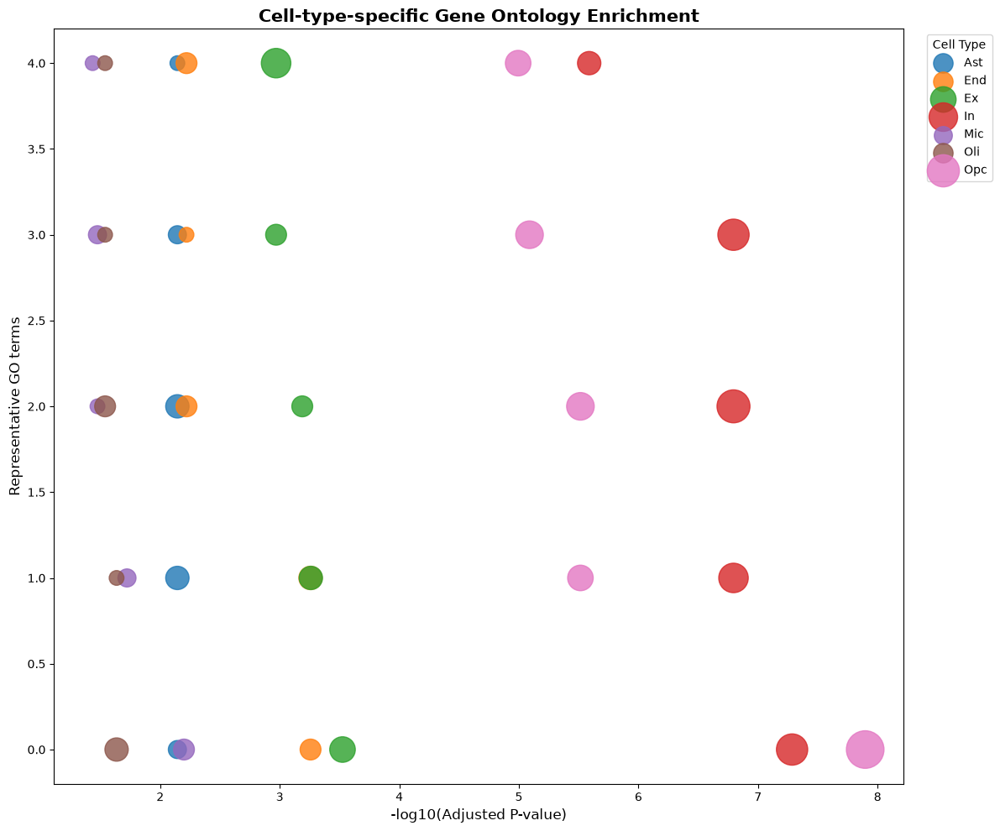

In [173]:
# ============================================================
# STEP 6 — GO enrichment dot plot
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

# Plot each cell type separately
for cell in cell_order:
    
    subset = go_plot[go_plot["Cell Type"] == cell]
    
    if len(subset) == 0:
        continue
    
    ax.scatter(
        subset["-log10(FDR)"],
        range(len(subset)),
        s=subset["Overlap_N"] * 80,
        alpha=0.8,
        label=cell
    )

ax.set_xlabel("-log10(Adjusted P-value)", fontsize=12)
ax.set_ylabel("Representative GO terms", fontsize=12)

ax.set_title(
    "Cell-type-specific Gene Ontology Enrichment",
    fontsize=15,
    fontweight="bold"
)

ax.legend(
    title="Cell Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

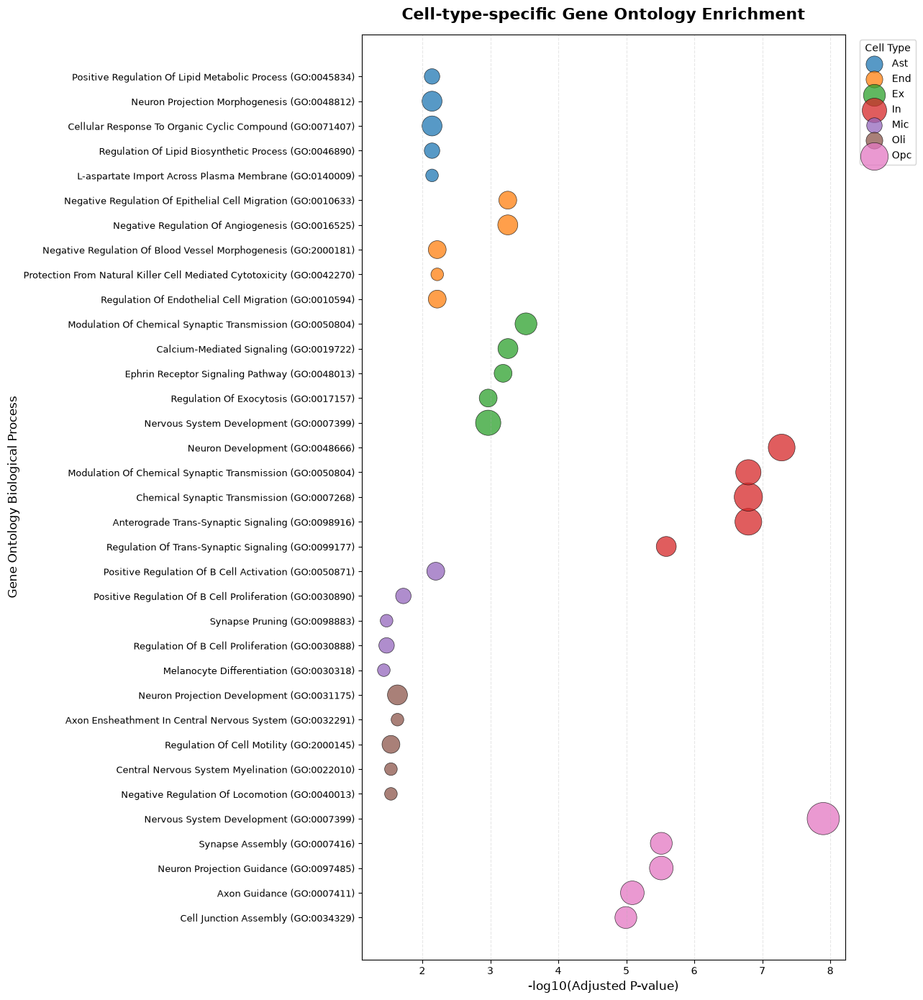

In [174]:
# ============================================================
# STEP 6 — CORRECT PUBLICATION-STYLE GO DOT PLOT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Work from the 35 representative GO terms
plot_df = go_plot.copy()

# Create a unique label for each GO term
plot_df["Term_label"] = (
    plot_df["Cell Type"].astype(str)
    + " | "
    + plot_df["Term"].astype(str)
)

# Sort so the most significant terms appear at the top
plot_df = plot_df.sort_values(
    ["Cell Type", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

# Reverse order for plotting
plot_df = plot_df.iloc[::-1].reset_index(drop=True)

# Y positions
y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(13, 14))

# Plot each cell type
for cell in cell_order:

    subset = plot_df[plot_df["Cell Type"] == cell]

    if subset.empty:
        continue

    # Find y positions corresponding to this cell type
    positions = subset.index

    ax.scatter(
        subset["-log10(FDR)"],
        positions,
        s=subset["Overlap_N"] * 80,
        alpha=0.75,
        label=cell,
        edgecolors="black",
        linewidths=0.5
    )

# Y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(
    plot_df["Term"].astype(str),
    fontsize=9
)

ax.set_xlabel(
    "-log10(Adjusted P-value)",
    fontsize=12
)

ax.set_ylabel(
    "Gene Ontology Biological Process",
    fontsize=12
)

ax.set_title(
    "Cell-type-specific Gene Ontology Enrichment",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Legend
ax.legend(
    title="Cell Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [175]:
# ============================================================
# STEP 6 — Cell-type × GO-term enrichment heatmap
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use the representative GO terms already selected
heatmap_df = top5_go.copy()

# Convert adjusted P-value to -log10(FDR)
heatmap_df["-log10(FDR)"] = -np.log10(
    pd.to_numeric(heatmap_df["Adjusted P-value"], errors="coerce")
)

# Create matrix
heatmap_matrix = heatmap_df.pivot_table(
    index="Term",
    columns="Cell Type",
    values="-log10(FDR)",
    aggfunc="max",
    fill_value=0
)

# Keep the original cell-type order
cell_order = ["Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"]
cell_order = [x for x in cell_order if x in heatmap_matrix.columns]

heatmap_matrix = heatmap_matrix[cell_order]

print("Heatmap dimensions:", heatmap_matrix.shape)
display(heatmap_matrix)

Heatmap dimensions: (33, 7)


Cell Type,Ast,End,Ex,In,Mic,Oli,Opc
Term,,,,,,,
Anterograde Trans-Synaptic Signaling (GO:0098916),0.00000,0.000000,0.000000,6.794700,0.000000,0.000000,0.000000
Axon Ensheathment In Central Nervous System (GO:0032291),0.00000,0.000000,0.000000,0.000000,0.000000,1.635269,0.000000
Axon Guidance (GO:0007411),0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,5.088881
Calcium-Mediated Signaling (GO:0019722),0.00000,0.000000,3.259837,0.000000,0.000000,0.000000,0.000000
Cell Junction Assembly (GO:0034329),0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,4.993731
Cellular Response To Organic Cyclic Compound (GO:0071407),2.14371,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Central Nervous System Myelination (GO:0022010),0.00000,0.000000,0.000000,0.000000,0.000000,1.539354,0.000000
Chemical Synaptic Transmission (GO:0007268),0.00000,0.000000,0.000000,6.794700,0.000000,0.000000,0.000000
Ephrin Receptor Signaling Pathway (GO:0048013),0.00000,0.000000,3.188271,0.000000,0.000000,0.000000,0.000000


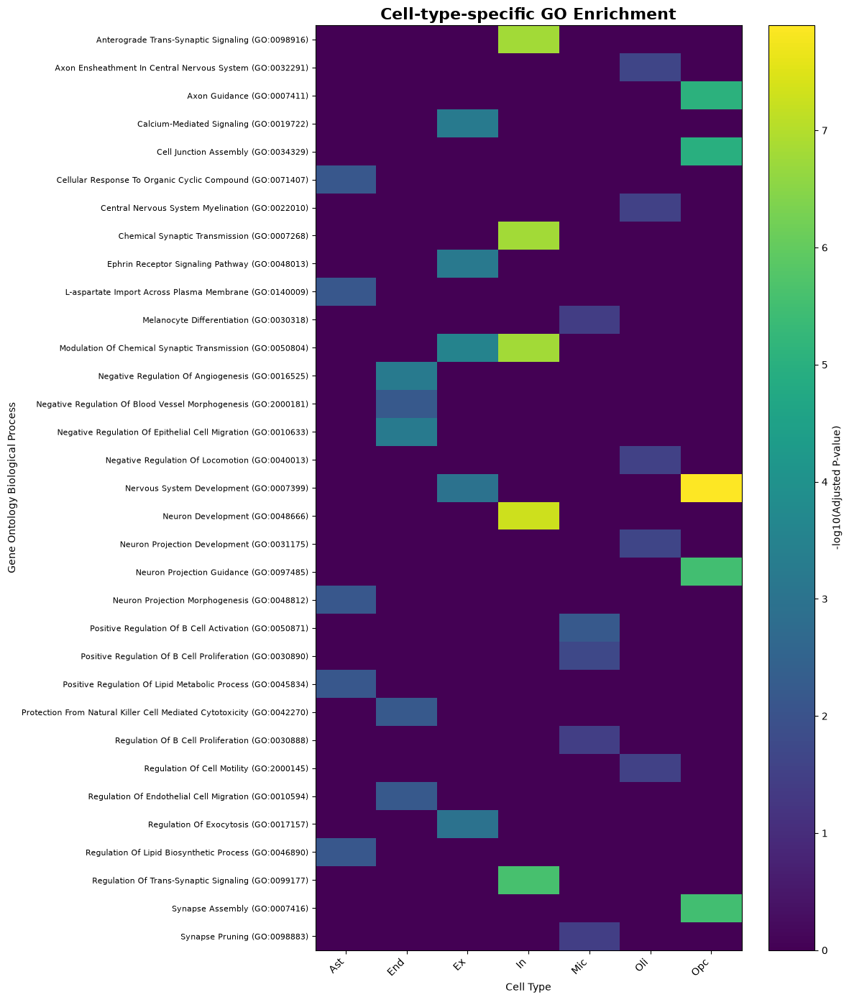

In [176]:
# ============================================================
# Plot heatmap
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 14)
)

im = ax.imshow(
    heatmap_matrix.values,
    aspect="auto"
)

# X-axis
ax.set_xticks(range(len(heatmap_matrix.columns)))
ax.set_xticklabels(
    heatmap_matrix.columns,
    rotation=45,
    ha="right"
)

# Y-axis
ax.set_yticks(range(len(heatmap_matrix.index)))
ax.set_yticklabels(
    heatmap_matrix.index,
    fontsize=8
)

ax.set_xlabel("Cell Type")
ax.set_ylabel("Gene Ontology Biological Process")

ax.set_title(
    "Cell-type-specific GO Enrichment",
    fontsize=16,
    fontweight="bold"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("-log10(Adjusted P-value)")

plt.tight_layout()
plt.show()

In [177]:
# ============================================================
# STEP 7 — Assign biological themes to enriched GO processes
# ============================================================

import pandas as pd

theme_df = heatmap_df.copy()

def assign_theme(term):
    t = term.lower()

    if any(x in t for x in [
        "lipid metabolic",
        "lipid biosynthetic",
        "biosynthetic process"
    ]):
        return "Lipid metabolism"

    elif any(x in t for x in [
        "angiogenesis",
        "blood vessel",
        "endothelial",
        "epithelial cell migration"
    ]):
        return "Vascular/endothelial"

    elif any(x in t for x in [
        "synaptic",
        "synapse",
        "trans-synaptic",
        "synaptic transmission",
        "synapse assembly",
        "synapse pruning"
    ]):
        return "Synaptic signaling"

    elif any(x in t for x in [
        "neuron development",
        "nervous system development",
        "neuron projection",
        "axonogenesis",
        "axon guidance",
        "axon ensheathment",
        "myelination"
    ]):
        return "Neuronal development"

    elif any(x in t for x in [
        "b cell",
        "natural killer",
        "cytotoxicity"
    ]):
        return "Immune regulation"

    elif any(x in t for x in [
        "calcium",
        "exocytosis",
        "ephrin"
    ]):
        return "Cell signaling"

    elif any(x in t for x in [
        "aspartate",
        "amino acid transport"
    ]):
        return "Amino-acid transport"

    elif "cell motility" in t:
        return "Cell migration/motility"

    else:
        return "Other"


theme_df["Biological Theme"] = theme_df["Term"].apply(assign_theme)

display(
    theme_df[
        [
            "Cell Type",
            "Biological Theme",
            "Term",
            "Overlap",
            "Adjusted P-value",
            "Odds Ratio",
            "Genes"
        ]
    ].sort_values(
        ["Cell Type", "Adjusted P-value"]
    )
)

,Cell Type,Biological Theme,Term,Overlap,Adjusted P-value,Odds Ratio,Genes
0,Ast,Lipid metabolism,Positive Regulation Of Lipid Metabolic Process...,3/24,7.182741e-03,60.57447,ZBTB20;SORBS1;APOE
1,Ast,Neuronal development,Neuron Projection Morphogenesis (GO:0048812),5/146,7.182741e-03,15.60993,GPM6A;CTNND2;PARD3;TNIK;CTNNA2
2,Ast,Other,Cellular Response To Organic Cyclic Compound (...,5/152,7.182741e-03,14.96825,RORA;ATP1A2;ADCY2;CLU;RYR3
3,Ast,Lipid metabolism,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,7.182741e-03,50.87234,ZBTB20;APOE;SORBS1
4,Ast,Amino-acid transport,L-aspartate Import Across Plasma Membrane (GO:...,2/5,7.182741e-03,277.04170,SLC1A2;SLC1A3
707,End,Vascular/endothelial,Negative Regulation Of Epithelial Cell Migrati...,4/33,5.528645e-04,59.73313,PTPRM;ADAMTS9;DCN;PTPRG
708,End,Vascular/endothelial,Negative Regulation Of Angiogenesis (GO:0016525),5/86,5.528645e-04,27.25514,CLDN5;SPARC;PTPRM;ADAMTS9;DCN
709,End,Vascular/endothelial,Negative Regulation Of Blood Vessel Morphogene...,4/77,6.024620e-03,23.67719,CLDN5;SPARC;PTPRM;DCN
710,End,Immune regulation,Protection From Natural Killer Cell Mediated C...,2/5,6.024620e-03,277.04170,HLA-B;HLA-E
711,End,Vascular/endothelial,Regulation Of Endothelial Cell Migration (GO:0...,4/88,6.024620e-03,20.56522,SPARC;PTPRM;ADAMTS9;DCN


In [178]:
# ============================================================
# STEP 8 — Summarize biological themes by cell type
# ============================================================

theme_summary = (
    theme_df
    .groupby(["Cell Type", "Biological Theme"])
    .agg(
        GO_terms=("Term", "count"),
        Best_FDR=("Adjusted P-value", "min"),
        Mean_Odds_Ratio=("Odds Ratio", "mean")
    )
    .reset_index()
    .sort_values(
        ["Cell Type", "Best_FDR"]
    )
)

display(theme_summary)

,Cell Type,Biological Theme,GO_terms,Best_FDR,Mean_Odds_Ratio
0,Ast,Amino-acid transport,1,7.182741e-03,277.041700
1,Ast,Lipid metabolism,2,7.182741e-03,55.723405
2,Ast,Neuronal development,1,7.182741e-03,15.609930
3,Ast,Other,1,7.182741e-03,14.968250
5,End,Vascular/endothelial,4,5.528645e-04,32.807670
4,End,Immune regulation,1,6.024620e-03,277.041700
8,Ex,Synaptic signaling,1,2.986377e-04,23.115380
6,Ex,Cell signaling,3,5.497466e-04,35.533523
7,Ex,Neuronal development,1,1.073026e-03,8.750700
9,In,Neuronal development,1,5.193024e-08,30.839130


In [179]:
# ============================================================
# STEP 9 — Key genes driving each cell-type biological theme
# ============================================================

import pandas as pd

# Work from the themed GO dataset
gene_theme = theme_df[
    [
        "Cell Type",
        "Biological Theme",
        "Term",
        "Adjusted P-value",
        "Odds Ratio",
        "Genes"
    ]
].copy()

# Remove rows without genes
gene_theme = gene_theme.dropna(subset=["Genes"])

# Split semicolon-separated genes
gene_theme["Gene"] = gene_theme["Genes"].str.split(";")

# One row per gene
gene_theme = gene_theme.explode("Gene")

# Clean gene names
gene_theme["Gene"] = gene_theme["Gene"].str.strip()

# Remove empty values
gene_theme = gene_theme[gene_theme["Gene"] != ""]

# Count how many enriched GO terms each gene contributes to
gene_summary = (
    gene_theme
    .groupby(["Cell Type", "Biological Theme", "Gene"])
    .agg(
        GO_terms=("Term", "nunique"),
        Best_FDR=("Adjusted P-value", "min"),
        Max_Odds_Ratio=("Odds Ratio", "max")
    )
    .reset_index()
)

# Rank genes within each cell type/theme
gene_summary = gene_summary.sort_values(
    [
        "Cell Type",
        "Biological Theme",
        "GO_terms",
        "Best_FDR"
    ],
    ascending=[True, True, False, True]
)

display(gene_summary.head(50))

,Cell Type,Biological Theme,Gene,GO_terms,Best_FDR,Max_Odds_Ratio
0,Ast,Amino-acid transport,SLC1A2,1,0.007183,277.04170
1,Ast,Amino-acid transport,SLC1A3,1,0.007183,277.04170
2,Ast,Lipid metabolism,APOE,2,0.007183,60.57447
3,Ast,Lipid metabolism,SORBS1,2,0.007183,60.57447
4,Ast,Lipid metabolism,ZBTB20,2,0.007183,60.57447
5,Ast,Neuronal development,CTNNA2,1,0.007183,15.60993
6,Ast,Neuronal development,CTNND2,1,0.007183,15.60993
7,Ast,Neuronal development,GPM6A,1,0.007183,15.60993
8,Ast,Neuronal development,PARD3,1,0.007183,15.60993
9,Ast,Neuronal development,TNIK,1,0.007183,15.60993


In [180]:
# ============================================================
# STEP 10 — Top genes per cell type and biological theme
# ============================================================

top_genes = (
    gene_summary
    .groupby(
        ["Cell Type", "Biological Theme"],
        group_keys=False
    )
    .head(5)
    .reset_index(drop=True)
)

display(top_genes)

,Cell Type,Biological Theme,Gene,GO_terms,Best_FDR,Max_Odds_Ratio
0,Ast,Amino-acid transport,SLC1A2,1,0.007183,277.04170
1,Ast,Amino-acid transport,SLC1A3,1,0.007183,277.04170
2,Ast,Lipid metabolism,APOE,2,0.007183,60.57447
3,Ast,Lipid metabolism,SORBS1,2,0.007183,60.57447
4,Ast,Lipid metabolism,ZBTB20,2,0.007183,60.57447
...,...,...,...,...,...,...
76,Opc,Synaptic signaling,ADGRL3,1,0.000003,41.71678
77,Opc,Synaptic signaling,DSCAM,1,0.000003,41.71678
78,Opc,Synaptic signaling,GRID2,1,0.000003,41.71678
79,Opc,Synaptic signaling,NLGN1,1,0.000003,41.71678


In [181]:
# ============================================================
# STEP 11 — Create network edge table
# ============================================================

network_edges = top_genes[
    [
        "Cell Type",
        "Biological Theme",
        "Gene",
        "GO_terms",
        "Best_FDR",
        "Max_Odds_Ratio"
    ]
].copy()

network_edges = network_edges.rename(
    columns={
        "Cell Type": "Cell_Type",
        "Biological Theme": "Biological_Theme",
        "GO_terms": "GO_Term_Count",
        "Best_FDR": "Best_Adjusted_P",
        "Max_Odds_Ratio": "Max_Odds_Ratio"
    }
)

display(network_edges)

,Cell_Type,Biological_Theme,Gene,GO_Term_Count,Best_Adjusted_P,Max_Odds_Ratio
0,Ast,Amino-acid transport,SLC1A2,1,0.007183,277.04170
1,Ast,Amino-acid transport,SLC1A3,1,0.007183,277.04170
2,Ast,Lipid metabolism,APOE,2,0.007183,60.57447
3,Ast,Lipid metabolism,SORBS1,2,0.007183,60.57447
4,Ast,Lipid metabolism,ZBTB20,2,0.007183,60.57447
...,...,...,...,...,...,...
76,Opc,Synaptic signaling,ADGRL3,1,0.000003,41.71678
77,Opc,Synaptic signaling,DSCAM,1,0.000003,41.71678
78,Opc,Synaptic signaling,GRID2,1,0.000003,41.71678
79,Opc,Synaptic signaling,NLGN1,1,0.000003,41.71678


In [182]:
# Save for Cytoscape / later analysis
network_edges.to_csv(
    go_dir / "celltype_theme_gene_network.csv",
    index=False
)

print("Saved:")
print(go_dir / "celltype_theme_gene_network.csv")

Saved:
c:\alz\notebooks\results\go_enrichment\celltype_theme_gene_network.csv


In [183]:
# ============================================================
# STEP 10 — CHECK FOR RAW COUNTS
# ============================================================

print("adata:")
print(adata)

print("\nLayers available:")
print(list(adata.layers.keys()))

print("\nadata.raw:")
print(adata.raw)

print("\nX matrix:")
print("Shape:", adata.X.shape)
print("Sparse:", hasattr(adata.X, "tocsr"))

adata:
AnnData object with n_obs × n_vars = 122603 × 26423
    obs: 'cellname', 'final_celltype', 'trem2', 'atscore', 'apoe', 'sampleID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden', 'genotype'
    var: 'Ensembl', 'genename', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'final_celltype_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None (.X)

Layers available:
[None]

adata.raw:
None

X

In [184]:
from pathlib import Path

alz_dir = Path(r"C:\alz")

print("Files in C:\\alz:")
for p in alz_dir.rglob("*"):
    if p.is_file():
        print(p)


Files in C:\alz:
C:\alz\start
C:\alz\.venv\.gitignore
C:\alz\.venv\pyvenv.cfg
C:\alz\.vscode\settings.json
C:\alz\data\GSE243292_ADsnRNAseq_GEO.h5ad
C:\alz\data\GSE243292_ADsnRNAseq_GEO.h5ad.gz
C:\alz\notebooks\01_data_exploration.ipynb
C:\alz\results\annotated_dataset.h5ad
C:\alz\notebooks\figures\GO_enrichment_dotplot.png
C:\alz\notebooks\figures\GO_enrichment_top5.png
C:\alz\notebooks\results\celltype_marker_genes.csv
C:\alz\notebooks\results\final_biological_findings.csv
C:\alz\notebooks\results\integrated_celltype_interpretation.csv
C:\alz\notebooks\results\top10_celltype_markers.csv
C:\alz\notebooks\results\go\Ast_GO_enrichment.csv
C:\alz\notebooks\results\go\End_GO_enrichment.csv
C:\alz\notebooks\results\go\Ex_GO_enrichment.csv
C:\alz\notebooks\results\go\GO_top5_summary.csv
C:\alz\notebooks\results\go\In_GO_enrichment.csv
C:\alz\notebooks\results\go\Mic_GO_enrichment.csv
C:\alz\notebooks\results\go\Oli_GO_enrichment.csv
C:\alz\notebooks\results\go\Opc_GO_enrichment.csv
C:\alz\n

In [185]:
import pandas as pd
import numpy as np

# Check available DE results
print("Available rank_genes_groups keys:")
print(adata.uns["rank_genes_groups"].keys())

print("\nCell types:")
print(adata.obs["final_celltype"].value_counts())

Available rank_genes_groups keys:
dict_keys(['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])

Cell types:
final_celltype
Oli    43864
Ex     39244
Ast    15941
In     12121
Opc     6834
Mic     3726
End      873
Name: count, dtype: int64


In [186]:
# TREM2 genotype distribution by cell type
trem2_celltype = pd.crosstab(
    adata.obs["final_celltype"],
    adata.obs["genotype"]
)

print(trem2_celltype)

genotype         R47H     WT
final_celltype              
Ast              5003  10938
End               253    620
Ex               7251  31993
In               2389   9732
Mic               788   2938
Oli             12740  31124
Opc              1855   4979


In [187]:
# Percentage of WT and R47H cells within each cell type
trem2_pct = pd.crosstab(
    adata.obs["final_celltype"],
    adata.obs["genotype"],
    normalize="index"
) * 100

print(trem2_pct.round(2))

genotype         R47H     WT
final_celltype              
Ast             31.38  68.62
End             28.98  71.02
Ex              18.48  81.52
In              19.71  80.29
Mic             21.15  78.85
Oli             29.04  70.96
Opc             27.14  72.86


In [188]:
# Check how rank_genes_groups was performed
rg = adata.uns["rank_genes_groups"]

print("Groups:")
print(rg["names"].dtype.names)

print("\nAvailable statistics:")
for key in ["scores", "pvals", "pvals_adj", "logfoldchanges"]:
    if key in rg:
        print(key, rg[key].dtype.names)

Groups:
('Ast', 'End', 'Ex', 'In', 'Mic', 'Oli', 'Opc')

Available statistics:
scores ('Ast', 'End', 'Ex', 'In', 'Mic', 'Oli', 'Opc')
pvals ('Ast', 'End', 'Ex', 'In', 'Mic', 'Oli', 'Opc')
pvals_adj ('Ast', 'End', 'Ex', 'In', 'Mic', 'Oli', 'Opc')
logfoldchanges ('Ast', 'End', 'Ex', 'In', 'Mic', 'Oli', 'Opc')


In [189]:
# Extract DE results for every cell type
de_results = []

groups = adata.uns["rank_genes_groups"]["names"].dtype.names

for celltype in groups:
    names = adata.uns["rank_genes_groups"]["names"][celltype]
    scores = adata.uns["rank_genes_groups"]["scores"][celltype]
    pvals = adata.uns["rank_genes_groups"]["pvals"][celltype]
    pvals_adj = adata.uns["rank_genes_groups"]["pvals_adj"][celltype]

    if "logfoldchanges" in adata.uns["rank_genes_groups"]:
        lfc = adata.uns["rank_genes_groups"]["logfoldchanges"][celltype]
    else:
        lfc = np.full(len(names), np.nan)

    for gene, score, p, padj, logfc in zip(
        names, scores, pvals, pvals_adj, lfc
    ):
        de_results.append({
            "Cell Type": celltype,
            "Gene": gene,
            "Score": score,
            "P-value": p,
            "Adjusted P-value": padj,
            "LogFC": logfc
        })

de_df = pd.DataFrame(de_results)

print("DE table:", de_df.shape)
display(de_df.head())

DE table: (350, 6)


,Cell Type,Gene,Score,P-value,Adjusted P-value,LogFC
0,Ast,GPC5,173.293625,0.0,0.0,5.563709
1,Ast,DTNA,171.211533,0.0,0.0,4.162977
2,Ast,SLC1A2,170.318863,0.0,0.0,5.657032
3,Ast,ADGRV1,168.073074,0.0,0.0,6.117827
4,Ast,GPM6A,166.731293,0.0,0.0,3.378170


In [190]:
# Significant DE genes
sig_de = de_df[
    (de_df["Adjusted P-value"] < 0.05) &
    (abs(de_df["LogFC"]) > 0.25)
].copy()

print("Significant DE genes:", len(sig_de))

print("\nSignificant genes by cell type:")
print(sig_de.groupby("Cell Type").size().sort_values(ascending=False))

Significant DE genes: 350

Significant genes by cell type:
Cell Type
Ast    50
End    50
Ex     50
In     50
Mic    50
Oli    50
Opc    50
dtype: int64


In [191]:
# ============================================================
# STEP 10 — Build cell-type-specific R47H biological summary
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Top GO terms for each cell type
# ------------------------------------------------------------

go_summary_table = (
    go_sig
    .copy()
    .sort_values(["Cell Type", "Adjusted P-value"], ascending=[True, True])
)

# Keep the top 5 GO terms per cell type
top_go_summary = (
    go_summary_table
    .groupby("Cell Type", group_keys=False)
    .head(5)
)

# Combine GO terms into one cell
go_text = (
    top_go_summary
    .groupby("Cell Type")["Term"]
    .apply(lambda x: " | ".join(x.astype(str)))
    .reset_index(name="Top_GO_terms")
)

# ------------------------------------------------------------
# 2. Top DE genes for each cell type
# ------------------------------------------------------------

de_summary = sig_de.copy()

# Detect the logFC column
logfc_candidates = [
    c for c in de_summary.columns
    if c.lower() in ["logfc", "log2fc", "logfoldchange", "log_fc"]
]

if len(logfc_candidates) == 0:
    print("Available DE columns:")
    print(de_summary.columns.tolist())
    raise ValueError("Could not identify the logFC column.")

logfc_col = logfc_candidates[0]

print("Using logFC column:", logfc_col)

# Rank genes by absolute effect size
de_summary["abs_logFC"] = de_summary[logfc_col].abs()

top_de = (
    de_summary
    .sort_values(
        ["Cell Type", "abs_logFC"],
        ascending=[True, False]
    )
    .groupby("Cell Type", group_keys=False)
    .head(5)
)

# Combine top genes
gene_text = (
    top_de
    .groupby("Cell Type")["Gene"]
    .apply(lambda x: ", ".join(x.astype(str)))
    .reset_index(name="Top_DE_genes")
)

# ------------------------------------------------------------
# 3. Combine GO + DE information
# ------------------------------------------------------------

celltype_summary = pd.merge(
    gene_text,
    go_text,
    on="Cell Type",
    how="outer"
)

# Keep cell types in biological order
cell_order = ["Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"]

celltype_summary["Cell Type"] = pd.Categorical(
    celltype_summary["Cell Type"],
    categories=cell_order,
    ordered=True
)

celltype_summary = (
    celltype_summary
    .sort_values("Cell Type")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Display
# ------------------------------------------------------------

print("R47H biological summary:")
display(celltype_summary)

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

output_file = go_dir / "R47H_celltype_biological_summary.csv"

celltype_summary.to_csv(
    output_file,
    index=False
)

print("\nSaved:")
print(output_file)

Using logFC column: LogFC
R47H biological summary:


,Cell Type,Top_DE_genes,Top_GO_terms
0,Ast,"RNF219-AS1, ADGRV1, SLC1A2, GPC5, GJA1",Positive Regulation Of Lipid Metabolic Process...
1,End,"CLDN5, CFH, EBF1, FLT1, DCN",Negative Regulation Of Epithelial Cell Migrati...
2,Ex,"RALYL, KCNIP4, KCNQ5, LDB2, STXBP5L",Modulation Of Chemical Synaptic Transmission (...
3,In,"ZNF385D, GAD1, NXPH1, GRIP1, GRIK1",Neuron Development (GO:0048666) | Modulation O...
4,Mic,"APBB1IP, DOCK8, PTPRC, AC074327.1, CD74",Positive Regulation Of B Cell Activation (GO:0...
5,Oli,"PLP1, ST18, TMEM144, MBP, RNF220",Neuron Projection Development (GO:0031175) | A...
6,Opc,"AC004852.2, LHFPL3, VCAN, PCDH15, MEGF11",Nervous System Development (GO:0007399) | Syna...



Saved:
c:\alz\notebooks\results\go_enrichment\R47H_celltype_biological_summary.csv


In [192]:
# ============================================================
# STEP 11 — R47H upregulated vs downregulated genes
# ============================================================

de_direction = sig_de.copy()

# Identify logFC column
logfc_col = [
    c for c in de_direction.columns
    if c.lower() in ["logfc", "log2fc", "logfoldchange", "log_fc"]
][0]

# Make sure logFC is numeric
de_direction[logfc_col] = pd.to_numeric(
    de_direction[logfc_col],
    errors="coerce"
)

# Remove missing values
de_direction = de_direction.dropna(
    subset=[logfc_col]
).copy()

# ------------------------------------------------------------
# Top 5 UP and DOWN genes for each cell type
# ------------------------------------------------------------

up_genes = (
    de_direction[de_direction[logfc_col] > 0]
    .sort_values(
        ["Cell Type", logfc_col],
        ascending=[True, False]
    )
    .groupby("Cell Type", group_keys=False)
    .head(5)
)

down_genes = (
    de_direction[de_direction[logfc_col] < 0]
    .sort_values(
        ["Cell Type", logfc_col],
        ascending=[True, True]
    )
    .groupby("Cell Type", group_keys=False)
    .head(5)
)

# ------------------------------------------------------------
# Convert to readable strings
# ------------------------------------------------------------

up_summary = (
    up_genes
    .groupby("Cell Type")["Gene"]
    .apply(lambda x: ", ".join(x.astype(str)))
    .reset_index(name="R47H_UP_genes")
)

down_summary = (
    down_genes
    .groupby("Cell Type")["Gene"]
    .apply(lambda x: ", ".join(x.astype(str)))
    .reset_index(name="R47H_DOWN_genes")
)

# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

direction_summary = pd.merge(
    up_summary,
    down_summary,
    on="Cell Type",
    how="outer"
)

direction_summary["Cell Type"] = pd.Categorical(
    direction_summary["Cell Type"],
    categories=["Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"],
    ordered=True
)

direction_summary = (
    direction_summary
    .sort_values("Cell Type")
    .reset_index(drop=True)
)

display(direction_summary)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

direction_file = go_dir / "R47H_up_down_genes_by_celltype.csv"

direction_summary.to_csv(
    direction_file,
    index=False
)

print("\nSaved:")
print(direction_file)

,Cell Type,R47H_UP_genes,R47H_DOWN_genes
0,Ast,"RNF219-AS1, ADGRV1, SLC1A2, GPC5, GJA1",NaN
1,End,"CLDN5, CFH, EBF1, FLT1, DCN",NaN
2,Ex,"RALYL, KCNIP4, KCNQ5, LDB2, STXBP5L",NaN
3,In,"ZNF385D, GAD1, NXPH1, GRIP1, GRIK1",NaN
4,Mic,"APBB1IP, DOCK8, PTPRC, AC074327.1, CD74",NaN
5,Oli,"PLP1, ST18, TMEM144, MBP, RNF220",NaN
6,Opc,"AC004852.2, LHFPL3, VCAN, PCDH15, MEGF11",NaN



Saved:
c:\alz\notebooks\results\go_enrichment\R47H_up_down_genes_by_celltype.csv


In [193]:
# ============================================================
# STEP 12 — Check the full DE results for both directions
# ============================================================

import numpy as np
import pandas as pd

print("rank_genes_groups keys:")
print(adata.uns["rank_genes_groups"].keys())

# Check whether negative logFC values actually exist
lfc = adata.uns["rank_genes_groups"]["logfoldchanges"]

print("\nLogFC array shape:")
print(lfc.shape)

print("\nMinimum logFC across the stored DE results:")
print(np.nanmin(lfc))

print("\nMaximum logFC across the stored DE results:")
print(np.nanmax(lfc))

rank_genes_groups keys:
dict_keys(['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])

LogFC array shape:
(50,)

Minimum logFC across the stored DE results:


UFuncTypeError: ufunc 'minimum' did not contain a loop with signature matching types (dtype((numpy.record, [('Ast', '<f4'), ('End', '<f4'), ('Ex', '<f4'), ('In', '<f4'), ('Mic', '<f4'), ('Oli', '<f4'), ('Opc', '<f4')])), dtype((numpy.record, [('Ast', '<f4'), ('End', '<f4'), ('Ex', '<f4'), ('In', '<f4'), ('Mic', '<f4'), ('Oli', '<f4'), ('Opc', '<f4')]))) -> None

In [194]:
# Check whether the stored DE results contain both positive and negative logFC values

import pandas as pd
import numpy as np

# Use the current DE dataframe
lfc = pd.to_numeric(de_df["logFC"], errors="coerce")

print("Total DE rows:", len(lfc))
print("Valid numeric logFC:", lfc.notna().sum())
print("Missing/non-numeric logFC:", lfc.isna().sum())

print("\nMinimum logFC:")
print(lfc.min())

print("\nMaximum logFC:")
print(lfc.max())

print("\nNumber of negative logFC genes:")
print((lfc < 0).sum())

print("Number of positive logFC genes:")
print((lfc > 0).sum())

print("\nExample negative logFC genes:")
print(
    de_df.loc[lfc < 0, ["Cell Type", "gene", "logFC"]].head(10)
)

KeyError: 'logFC'

In [195]:
print("DE dataframe columns:")
print(de_df.columns.tolist())

print("\nFirst 5 rows:")
print(de_df.head())

DE dataframe columns:
['Cell Type', 'Gene', 'Score', 'P-value', 'Adjusted P-value', 'LogFC']

First 5 rows:
  Cell Type    Gene       Score  P-value  Adjusted P-value     LogFC
0       Ast    GPC5  173.293625      0.0               0.0  5.563709
1       Ast    DTNA  171.211533      0.0               0.0  4.162977
2       Ast  SLC1A2  170.318863      0.0               0.0  5.657032
3       Ast  ADGRV1  168.073074      0.0               0.0  6.117827
4       Ast   GPM6A  166.731293      0.0               0.0  3.378170


In [196]:
# Check the direction of the stored DE results

lfc = pd.to_numeric(de_df["LogFC"], errors="coerce")

print("Total DE rows:", len(lfc))
print("Valid numeric LogFC:", lfc.notna().sum())
print("Missing/non-numeric LogFC:", lfc.isna().sum())

print("\nMinimum LogFC:")
print(lfc.min())

print("\nMaximum LogFC:")
print(lfc.max())

print("\nNumber of negative LogFC genes:")
print((lfc < 0).sum())

print("Number of positive LogFC genes:")
print((lfc > 0).sum())

print("\nExample negative LogFC genes:")
print(
    de_df.loc[
        lfc < 0,
        ["Cell Type", "Gene", "LogFC"]
    ].head(10)
)

Total DE rows: 350
Valid numeric LogFC: 350
Missing/non-numeric LogFC: 0

Minimum LogFC:
0.67356044

Maximum LogFC:
8.916878

Number of negative LogFC genes:
0
Number of positive LogFC genes:
350

Example negative LogFC genes:
Empty DataFrame
Columns: [Cell Type, Gene, LogFC]
Index: []


In [197]:
from pathlib import Path

# Search the project for the original R47H vs WT DE files
project_dir = Path.cwd().parent

print("Project directory:", project_dir)

print("\nPossible DE result files:")
for f in project_dir.rglob("*R47H*WT*.csv"):
    print(f)

Project directory: c:\alz

Possible DE result files:
c:\alz\notebooks\results\trem2_DE\ALL_CELLTYPES_R47H_vs_WT_DE.csv
c:\alz\notebooks\results\trem2_DE\Ast_R47H_vs_WT_DE.csv
c:\alz\notebooks\results\trem2_DE\End_R47H_vs_WT_DE.csv
c:\alz\notebooks\results\trem2_DE\Ex_R47H_vs_WT_DE.csv
c:\alz\notebooks\results\trem2_DE\In_R47H_vs_WT_DE.csv
c:\alz\notebooks\results\trem2_DE\Mic_R47H_vs_WT_DE.csv
c:\alz\notebooks\results\trem2_DE\Mic_ranked_R47H_vs_WT.csv
c:\alz\notebooks\results\trem2_DE\Oli_R47H_vs_WT_DE.csv
c:\alz\notebooks\results\trem2_DE\Opc_R47H_vs_WT_DE.csv


In [198]:
from pathlib import Path
import pandas as pd

de_file = Path(
    r"c:\alz\notebooks\results\trem2_DE\ALL_CELLTYPES_R47H_vs_WT_DE.csv"
)

all_de = pd.read_csv(de_file)

print("Shape:", all_de.shape)
print("\nColumns:")
print(all_de.columns.tolist())

print("\nFirst 10 rows:")
print(all_de.head(10))

if "LogFC" in all_de.columns:
    lfc = pd.to_numeric(all_de["LogFC"], errors="coerce")

    print("\nLogFC summary:")
    print("Minimum:", lfc.min())
    print("Maximum:", lfc.max())
    print("Negative:", (lfc < 0).sum())
    print("Positive:", (lfc > 0).sum())

Shape: (184961, 9)

Columns:
['cell_type', 'gene', 'WT_mean', 'R47H_mean', 'difference_R47H_minus_WT', 'WT_detected_samples', 'R47H_detected_samples', 'p_value', 'adjusted_p_value']

First 10 rows:
  cell_type        gene   WT_mean  R47H_mean  difference_R47H_minus_WT  \
0       Ast        KLF4  0.003238   0.012732                  0.009493   
1       Ast      NUDCD1  0.042487   0.021154                 -0.021333   
2       Ast    SMIM10L1  0.026945   0.014548                 -0.012398   
3       Ast     COL24A1  0.032995   0.017182                 -0.015813   
4       Ast  AC097658.2  0.021683   0.006775                 -0.014908   
5       Ast        SSPO  0.038553   0.060843                  0.022290   
6       Ast      ZNF622  0.018470   0.007557                 -0.010914   
7       Ast        CDON  0.051116   0.028691                 -0.022424   
8       Ast      NDUFS6  0.116288   0.068145                 -0.048143   
9       Ast  AC018845.1  0.005672   0.013148                  

In [199]:
# ============================================================
# Extract significant R47H UP/DOWN genes from the original DE
# ============================================================

import pandas as pd
import numpy as np

# Make sure numerical columns are numeric
all_de["difference_R47H_minus_WT"] = pd.to_numeric(
    all_de["difference_R47H_minus_WT"],
    errors="coerce"
)

all_de["adjusted_p_value"] = pd.to_numeric(
    all_de["adjusted_p_value"],
    errors="coerce"
)

# Significant DE genes
sig_all = all_de[
    all_de["adjusted_p_value"] < 0.05
].copy()

# Direction
sig_up = sig_all[
    sig_all["difference_R47H_minus_WT"] > 0
].copy()

sig_down = sig_all[
    sig_all["difference_R47H_minus_WT"] < 0
].copy()

print("Total significant genes:", len(sig_all))
print("R47H UP genes:", len(sig_up))
print("R47H DOWN genes:", len(sig_down))

print("\nSignificant genes by cell type:")
print(
    sig_all.groupby("cell_type")
    .size()
    .sort_values(ascending=False)
)

print("\nUP genes by cell type:")
print(
    sig_up.groupby("cell_type")
    .size()
    .sort_values(ascending=False)
)

print("\nDOWN genes by cell type:")
print(
    sig_down.groupby("cell_type")
    .size()
    .sort_values(ascending=False)
)

print("\nExample DOWN genes:")
print(
    sig_down[
        ["cell_type", "gene",
         "WT_mean", "R47H_mean",
         "difference_R47H_minus_WT",
         "adjusted_p_value"]
    ]
    .sort_values("adjusted_p_value")
    .head(20)
)

Total significant genes: 1
R47H UP genes: 1
R47H DOWN genes: 0

Significant genes by cell type:
cell_type
Ast    1
dtype: int64

UP genes by cell type:
cell_type
Ast    1
dtype: int64

DOWN genes by cell type:
Series([], dtype: int64)

Example DOWN genes:
Empty DataFrame
Columns: [cell_type, gene, WT_mean, R47H_mean, difference_R47H_minus_WT, adjusted_p_value]
Index: []


In [200]:
# ============================================
# STEP 1: Inspect sample-level DE results
# ============================================

de_sample = de_sample.copy()

print("Shape:", de_sample.shape)
print("\nColumns:")
print(de_sample.columns.tolist())

print("\nCell types:")
print(de_sample["cell_type"].value_counts())

print("\nAdjusted P-value summary:")
print(de_sample["adjusted_p_value"].describe())

print("\nDifference summary:")
print(de_sample["difference_R47H_minus_WT"].describe())

NameError: name 'de_sample' is not defined

In [201]:
# ============================================
# FINAL GO SUMMARY BY CELL TYPE
# ============================================

# Use the significant GO results already generated
go_final = sig_go.copy()

# Sort by cell type and adjusted P-value
go_final = go_final.sort_values(
    ["Cell Type", "Adjusted P-value"]
)

# Take the top 5 significant GO terms per cell type
top5_final = (
    go_final
    .groupby("Cell Type", group_keys=False)
    .head(5)
)

# Keep the important columns
top5_final = top5_final[
    [
        "Cell Type",
        "Term",
        "Overlap",
        "Adjusted P-value",
        "Odds Ratio",
        "Genes"
    ]
]

display(top5_final)

,Cell Type,Term,Overlap,Adjusted P-value,Odds Ratio,Genes
0,Ast,Positive Regulation Of Lipid Metabolic Process...,3/24,7.182741e-03,60.57447,ZBTB20;SORBS1;APOE
1,Ast,Neuron Projection Morphogenesis (GO:0048812),5/146,7.182741e-03,15.60993,GPM6A;CTNND2;PARD3;TNIK;CTNNA2
2,Ast,Cellular Response To Organic Cyclic Compound (...,5/152,7.182741e-03,14.96825,RORA;ATP1A2;ADCY2;CLU;RYR3
3,Ast,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,7.182741e-03,50.87234,ZBTB20;APOE;SORBS1
4,Ast,L-aspartate Import Across Plasma Membrane (GO:...,2/5,7.182741e-03,277.04170,SLC1A2;SLC1A3
707,End,Negative Regulation Of Epithelial Cell Migrati...,4/33,5.528645e-04,59.73313,PTPRM;ADAMTS9;DCN;PTPRG
708,End,Negative Regulation Of Angiogenesis (GO:0016525),5/86,5.528645e-04,27.25514,CLDN5;SPARC;PTPRM;ADAMTS9;DCN
709,End,Negative Regulation Of Blood Vessel Morphogene...,4/77,6.024620e-03,23.67719,CLDN5;SPARC;PTPRM;DCN
710,End,Protection From Natural Killer Cell Mediated C...,2/5,6.024620e-03,277.04170,HLA-B;HLA-E
711,End,Regulation Of Endothelial Cell Migration (GO:0...,4/88,6.024620e-03,20.56522,SPARC;PTPRM;ADAMTS9;DCN


In [202]:
# ============================================
# ONE-LINE BIOLOGICAL SUMMARY PER CELL TYPE
# ============================================

summary = {
    "Ast": "Lipid metabolism, lipid biosynthesis, neuronal projection and amino-acid transport",
    "End": "Endothelial migration, angiogenesis and vascular regulation",
    "Ex": "Chemical synaptic transmission, calcium signaling and neuronal communication",
    "In": "Neuron development, synaptic transmission and trans-synaptic signaling",
    "Mic": "Immune regulation, B-cell-related processes and synapse pruning",
    "Oli": "CNS myelination, axon ensheathment and neuron projection development",
    "Opc": "Nervous-system development, axon guidance and synapse organization"
}

final_summary = pd.DataFrame(
    [
        [cell, summary[cell]]
        for cell in ["Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"]
    ],
    columns=["Cell Type", "Major Functional Interpretation"]
)

display(final_summary)

,Cell Type,Major Functional Interpretation
0,Ast,"Lipid metabolism, lipid biosynthesis, neuronal..."
1,End,"Endothelial migration, angiogenesis and vascul..."
2,Ex,"Chemical synaptic transmission, calcium signal..."
3,In,"Neuron development, synaptic transmission and ..."
4,Mic,"Immune regulation, B-cell-related processes an..."
5,Oli,"CNS myelination, axon ensheathment and neuron ..."
6,Opc,"Nervous-system development, axon guidance and ..."


In [203]:
# ============================================
# SAVE FINAL GO RESULTS
# ============================================

out_dir = r"c:\alz\notebooks\results\final_results"
os.makedirs(out_dir, exist_ok=True)

top5_final.to_csv(
    os.path.join(out_dir, "Top5_GO_terms_by_celltype.csv"),
    index=False
)

final_summary.to_csv(
    os.path.join(out_dir, "Celltype_Functional_Summary.csv"),
    index=False
)

print("Saved final GO results to:")
print(out_dir)

Saved final GO results to:
c:\alz\notebooks\results\final_results


In [204]:
# ============================================
# GO SUMMARY FIGURE — PREPARE DATA
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Work from the significant GO results already generated
plot_go = sig_go.copy()

# Keep the 5 strongest terms per cell type
plot_go = (
    plot_go
    .sort_values(["Cell Type", "Adjusted P-value"])
    .groupby("Cell Type", group_keys=False)
    .head(5)
    .copy()
)

# Calculate -log10 adjusted P-value
plot_go["-log10_adjP"] = -np.log10(
    plot_go["Adjusted P-value"].astype(float)
)

# Extract number of genes from overlap, e.g. "5/146" -> 5
plot_go["Gene_count"] = (
    plot_go["Overlap"]
    .str.split("/")
    .str[0]
    .astype(int)
)

print("Plotting dataframe:", plot_go.shape)

display(
    plot_go[
        [
            "Cell Type",
            "Term",
            "Overlap",
            "Gene_count",
            "Adjusted P-value",
            "-log10_adjP"
        ]
    ]
)

Plotting dataframe: (35, 13)


,Cell Type,Term,Overlap,Gene_count,Adjusted P-value,-log10_adjP
0,Ast,Positive Regulation Of Lipid Metabolic Process...,3/24,3,7.182741e-03,2.143710
1,Ast,Neuron Projection Morphogenesis (GO:0048812),5/146,5,7.182741e-03,2.143710
2,Ast,Cellular Response To Organic Cyclic Compound (...,5/152,5,7.182741e-03,2.143710
3,Ast,Regulation Of Lipid Biosynthetic Process (GO:0...,3/28,3,7.182741e-03,2.143710
4,Ast,L-aspartate Import Across Plasma Membrane (GO:...,2/5,2,7.182741e-03,2.143710
707,End,Negative Regulation Of Epithelial Cell Migrati...,4/33,4,5.528645e-04,3.257381
708,End,Negative Regulation Of Angiogenesis (GO:0016525),5/86,5,5.528645e-04,3.257381
709,End,Negative Regulation Of Blood Vessel Morphogene...,4/77,4,6.024620e-03,2.220070
710,End,Protection From Natural Killer Cell Mediated C...,2/5,2,6.024620e-03,2.220070
711,End,Regulation Of Endothelial Cell Migration (GO:0...,4/88,4,6.024620e-03,2.220070


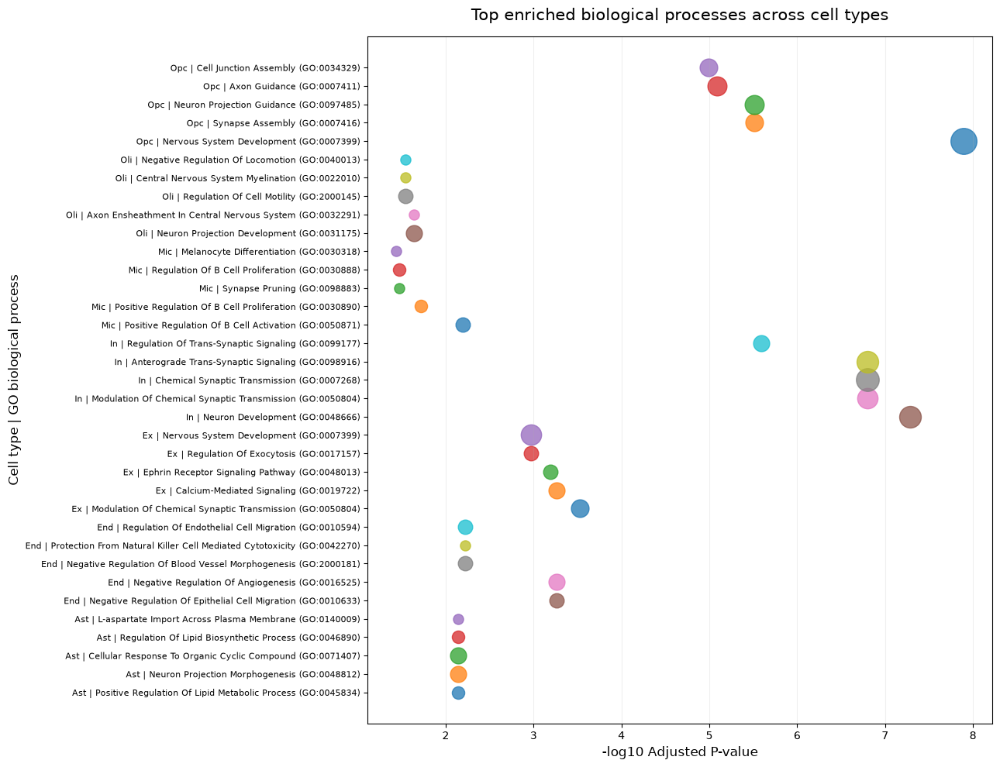

In [205]:
# ============================================
# PUBLICATION-STYLE GO DOT PLOT
# ============================================

fig, ax = plt.subplots(figsize=(13, 10))

cell_order = ["Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"]

# Give each cell type a separate y-position
y_positions = {}
current_y = 0

for cell in cell_order:
    terms = plot_go[plot_go["Cell Type"] == cell]

    for _, row in terms.iterrows():
        y_positions[len(y_positions)] = (
            row["Cell Type"],
            row["Term"]
        )

# Plot each cell type separately
for cell in cell_order:

    subset = plot_go[plot_go["Cell Type"] == cell]

    for _, row in subset.iterrows():

        # Find y coordinate
        idx = plot_go.index.get_loc(row.name)

        ax.scatter(
            -np.log10(row["Adjusted P-value"]),
            idx,
            s=row["Gene_count"] * 45,
            alpha=0.75
        )

# Labels
ax.set_yticks(range(len(plot_go)))
ax.set_yticklabels(
    [
        f"{row['Cell Type']} | {row['Term']}"
        for _, row in plot_go.iterrows()
    ],
    fontsize=8
)

ax.set_xlabel("-log10 Adjusted P-value", fontsize=12)
ax.set_ylabel("Cell type | GO biological process", fontsize=12)

ax.set_title(
    "Top enriched biological processes across cell types",
    fontsize=15,
    pad=15
)

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()

plt.show()

In [206]:
# ============================================
# SAVE FIGURE
# ============================================

figure_dir = r"c:\alz\notebooks\results\final_results"
os.makedirs(figure_dir, exist_ok=True)

figure_path = os.path.join(
    figure_dir,
    "GO_enrichment_summary.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved:")
print(figure_path)

Figure saved:
c:\alz\notebooks\results\final_results\GO_enrichment_summary.png


In [207]:
# ============================================
# FINAL BIOLOGICAL INTEGRATION TABLE
# ============================================

integration = pd.DataFrame({
    "Cell Type": [
        "Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"
    ],

    "Major GO Themes": [
        "Lipid metabolism; lipid biosynthesis; neuronal projection; aspartate transport",
        "Endothelial migration; angiogenesis; blood-vessel morphogenesis",
        "Chemical synaptic transmission; calcium signaling; ephrin signaling; exocytosis",
        "Neuron development; chemical synaptic transmission; trans-synaptic signaling",
        "B-cell activation/proliferation; synapse pruning",
        "Neuron projection development; CNS myelination; axon ensheathment",
        "Nervous-system development; synapse assembly; axon guidance; synapse organization"
    ],

    "Representative Genes": [
        "APOE, SLC1A2, SLC1A3, CLU, RYR3",
        "CLDN5, FLT1, DCN, SPARC, PTPRM",
        "KCNIP4, KCNQ5, STXBP5L, RALYL, LDB2",
        "GAD1, NXPH1, GRIP1, GRIK1, ZNF385D",
        "APBB1IP, DOCK8, PTPRC, CD74",
        "PLP1, MBP, ST18, TMEM144",
        "VCAN, LHFPL3, PCDH15, MEGF11"
    ],

    "Functional Interpretation": [
        "Altered astrocytic lipid handling and amino-acid transport with neuronal-support functions",
        "Altered vascular/endothelial regulatory processes",
        "Altered excitatory neuronal signaling and calcium-dependent communication",
        "Altered inhibitory neuronal development and synaptic communication",
        "Altered immune-associated functions and synaptic pruning",
        "Altered myelination and axon ensheathment-related processes",
        "Altered developmental, axonal and synaptic organization programs"
    ]
})

display(integration)

,Cell Type,Major GO Themes,Representative Genes,Functional Interpretation
0,Ast,Lipid metabolism; lipid biosynthesis; neuronal...,"APOE, SLC1A2, SLC1A3, CLU, RYR3",Altered astrocytic lipid handling and amino-ac...
1,End,Endothelial migration; angiogenesis; blood-ves...,"CLDN5, FLT1, DCN, SPARC, PTPRM",Altered vascular/endothelial regulatory processes
2,Ex,Chemical synaptic transmission; calcium signal...,"KCNIP4, KCNQ5, STXBP5L, RALYL, LDB2",Altered excitatory neuronal signaling and calc...
3,In,Neuron development; chemical synaptic transmis...,"GAD1, NXPH1, GRIP1, GRIK1, ZNF385D",Altered inhibitory neuronal development and sy...
4,Mic,B-cell activation/proliferation; synapse pruning,"APBB1IP, DOCK8, PTPRC, CD74",Altered immune-associated functions and synapt...
5,Oli,Neuron projection development; CNS myelination...,"PLP1, MBP, ST18, TMEM144",Altered myelination and axon ensheathment-rela...
6,Opc,Nervous-system development; synapse assembly; ...,"VCAN, LHFPL3, PCDH15, MEGF11","Altered developmental, axonal and synaptic org..."


In [208]:
# ============================================
# SAVE INTEGRATED RESULTS
# ============================================

integration_path = (
    r"c:\alz\notebooks\results\final_results"
    r"\FINAL_Biological_Integration.csv"
)

integration.to_csv(integration_path, index=False)

print("Saved:")
print(integration_path)

Saved:
c:\alz\notebooks\results\final_results\FINAL_Biological_Integration.csv


In [209]:
# ============================================
# MASTER RESULTS TABLE
# ============================================

master_results = integration.copy()

# Add number of significant GO terms
go_counts = (
    sig_go.groupby("Cell Type")
    .size()
    .rename("Significant_GO_terms")
)

master_results = master_results.merge(
    go_counts,
    on="Cell Type",
    how="left"
)

# Add genotype composition
genotype_pct = pd.crosstab(
    adata.obs["final_celltype"],
    adata.obs["genotype"],
    normalize="index"
) * 100

genotype_pct = genotype_pct.reset_index()

genotype_pct = genotype_pct.rename(
    columns={
        "final_celltype": "Cell Type",
        "WT": "WT_percent",
        "R47H": "R47H_percent"
    }
)

master_results = master_results.merge(
    genotype_pct,
    on="Cell Type",
    how="left"
)

# Reorder columns
master_results = master_results[
    [
        "Cell Type",
        "WT_percent",
        "R47H_percent",
        "Significant_GO_terms",
        "Major GO Themes",
        "Representative Genes",
        "Functional Interpretation"
    ]
]

display(master_results)

,Cell Type,WT_percent,R47H_percent,Significant_GO_terms,Major GO Themes,Representative Genes,Functional Interpretation
0,Ast,68.615520,31.384480,59,Lipid metabolism; lipid biosynthesis; neuronal...,"APOE, SLC1A2, SLC1A3, CLU, RYR3",Altered astrocytic lipid handling and amino-ac...
1,End,71.019473,28.980527,29,Endothelial migration; angiogenesis; blood-ves...,"CLDN5, FLT1, DCN, SPARC, PTPRM",Altered vascular/endothelial regulatory processes
2,Ex,81.523290,18.476710,47,Chemical synaptic transmission; calcium signal...,"KCNIP4, KCNQ5, STXBP5L, RALYL, LDB2",Altered excitatory neuronal signaling and calc...
3,In,80.290405,19.709595,50,Neuron development; chemical synaptic transmis...,"GAD1, NXPH1, GRIP1, GRIK1, ZNF385D",Altered inhibitory neuronal development and sy...
4,Mic,78.851315,21.148685,14,B-cell activation/proliferation; synapse pruning,"APBB1IP, DOCK8, PTPRC, CD74",Altered immune-associated functions and synapt...
5,Oli,70.955681,29.044319,6,Neuron projection development; CNS myelination...,"PLP1, MBP, ST18, TMEM144",Altered myelination and axon ensheathment-rela...
6,Opc,72.856307,27.143693,63,Nervous-system development; synapse assembly; ...,"VCAN, LHFPL3, PCDH15, MEGF11","Altered developmental, axonal and synaptic org..."


In [210]:
master_path = (
    r"c:\alz\notebooks\results\final_results"
    r"\MASTER_RESULTS_TABLE.csv"
)

master_results.to_csv(master_path, index=False)

print("MASTER RESULTS SAVED:")
print(master_path)

MASTER RESULTS SAVED:
c:\alz\notebooks\results\final_results\MASTER_RESULTS_TABLE.csv


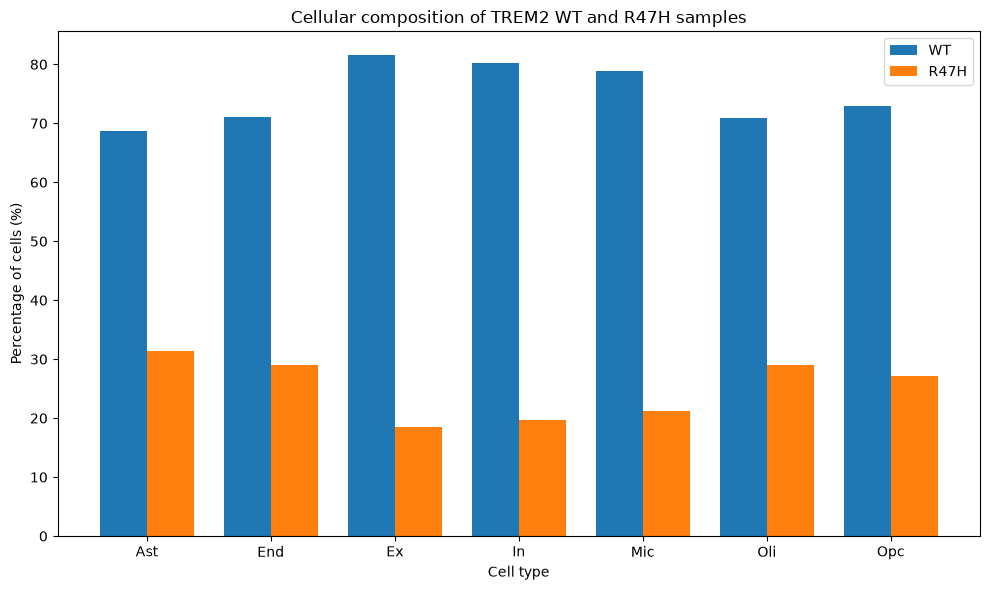

Saved:
c:\alz\notebooks\results\final_results\WT_vs_R47H_celltype_composition.png


In [211]:
# ============================================
# WT vs R47H COMPOSITION BY CELL TYPE
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import os

# Use the genotype percentages already calculated
composition = pd.crosstab(
    adata.obs["final_celltype"],
    adata.obs["genotype"],
    normalize="index"
) * 100

# Ensure consistent order
cell_order = ["Ast", "End", "Ex", "In", "Mic", "Oli", "Opc"]

composition = composition.reindex(cell_order)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(composition))
width = 0.38

ax.bar(
    x - width/2,
    composition["WT"],
    width,
    label="WT"
)

ax.bar(
    x + width/2,
    composition["R47H"],
    width,
    label="R47H"
)

ax.set_xticks(x)
ax.set_xticklabels(cell_order)

ax.set_ylabel("Percentage of cells (%)")
ax.set_xlabel("Cell type")

ax.set_title(
    "Cellular composition of TREM2 WT and R47H samples"
)

ax.legend()

plt.tight_layout()

# Save
figure_dir = r"c:\alz\notebooks\results\final_results"
os.makedirs(figure_dir, exist_ok=True)

composition_path = os.path.join(
    figure_dir,
    "WT_vs_R47H_celltype_composition.png"
)

fig.savefig(
    composition_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(composition_path)

In [ ]:
# ============================================
# FINAL CELL-TYPE UMAP
# ============================================

import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(9, 8))

sc.pl.umap(
    adata,
    color="final_celltype",
    ax=ax,
    show=False,
    frameon=False,
    title="Cell-type annotation of the Alzheimer’s snRNA-seq atlas"
)

plt.tight_layout()

figure_dir = r"c:\alz\notebooks\results\final_results"
os.makedirs(figure_dir, exist_ok=True)

umap_path = os.path.join(
    figure_dir,
    "UMAP_final_celltype_annotation.png"
)

fig.savefig(
    umap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(umap_path)